# START HERE: NEW TO GOOGLE COLAB?

Welcome. You can complete this lesson without knowing Python. A **notebook** combines explanations with calculations and their results. **Explanation cells** are for reading; **code cells** perform calculations. An **output** is the table, message or chart that appears beneath a code cell.

1. If Colab asks, sign in to your Google account. You may choose **Copy to Drive** to keep your own editable copy; the public lesson stays unchanged.
2. Open the **Runtime** menu at the top, then choose **Run all**. Colab may show a notice because the notebook comes from GitHub. After reviewing this lesson's source, choose **Run anyway** to execute it. Colab connects a Python session and starts the cells in order.
3. Wait until execution stops. A code cell's ▶ button runs that cell; a spinning indicator means it is still busy. A completed execution number such as `[1]`, a green completion indicator when Colab shows one, or a printed ✓ success message helps you find completed steps. Red error text or a **Traceback** usually means a cell failed; warning messages can also be colored and do not always mean failure.
4. Read from top to bottom. **Wait for a cell to finish before interpreting its output.** Saved charts are previews; running the cells creates the live interactive figures. The first run may take a few minutes while Colab prepares packages and charts.

**You normally do not need to provide a dataset.** The approved Framingham teaching CSV downloads automatically. **Only if that download or its verification fails** will Colab ask you to upload the approved `framingham.csv`. The printed receipt shows the source, filename, rows and columns. Never upload an unrelated CSV or change the hash checks.

| Choose your route | What to do |
|---|---|
| **QUICK ROUTE** | **Runtime → Run all**, wait, then read from top to bottom. |
| **LEARNING ROUTE** | Work in order and click ▶ beside each code cell in one section before moving to the next. Run Setup first. |
| **EXPLORER ROUTE** | Complete the notebook first, then change only the lines explicitly marked **TRY IT**. |

**Using the charts:** hover over a point or bar to see recorded values and denominators; drag to zoom; choose the pan tool to move the view; double-click to reset; click a legend item to hide/show a group; click a dropdown to choose a variable. Plotly is the chart library that supplies these controls. Static figures do not have these controls.

⭐ **BEGINNER CORE** is the main learning path. 🔬 **OPTIONAL ADVANCED EDA** adds extra views; you can skip those labeled cells in the learning route without losing the main lesson. Run all includes them automatically.

## IF SOMETHING GOES WRONG

1. Choose **Runtime → Restart session** (or **Restart runtime**, if that is the label in your Colab version).
2. Choose **Runtime → Run all** and wait for the cells to complete.
3. If asked for the dataset, upload only the approved `framingham.csv` from the lesson repository. A rejected upload means the file differs from the approved copy.
4. If an **optional static Plotly export** fails, continue: the interactive figures and analysis are unaffected, and the standard static figures are already exported.
5. Do not manually change the dataset hash, validation checks, model formula or helper functions.

If a TRY IT entry is not supported, select one of its listed choices and rerun that small cell. If you run a later cell before its earlier setup, restart and Run all.


# EvidenceLab #06: Exploratory Data Analysis — Interactive
## The pattern I almost dismissed
Dr. Amobi Andrew Onovo · **See it. Understand it. Run it.**

Select **Runtime → Run all**, then read from top to bottom. The notebook first downloads the approved Framingham teaching copy. If the download fails, Colab requests the same CSV and verifies it before continuing. Source, filename and dimensions are displayed. No alternative dataset is substituted.

**Learning route:** QUESTION → AUDIT → TYPE → REPAIR → ENGINEER → EXPLORE → CONNECT → MODEL → EXPLAIN.

Understand → calculate → visualize → investigate → go deeper → experiment → interpret. Hover for exact values, zoom or pan, click legends to compare groups, and use dropdowns to explore variables. All model estimates use the complete eligible data, not visualization samples. Ten-year CHD refers to the recorded binary outcome in this teaching copy, not a causal effect.


## STEP 0 — SETUP

**Step 0 of 9 · ⭐ BEGINNER CORE**

Run these setup cells in order. You do not need to understand Python syntax or edit their contents. The approved teaching data will load automatically after the introductory example.

**SETUP CELL: Run this cell. You do not need to understand or edit this code.**

**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Prepare the packages used by the lesson.

**WHY ARE WE DOING IT?** The calculations and charts need these Python tools.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** A dependencies-ready message; only missing core packages are installed.

In [1]:
# Install only missing packages. Kaleido is optional and is handled only in the export cell.
import importlib.util, subprocess, sys
packages={'numpy':'numpy','pandas':'pandas','matplotlib':'matplotlib','plotly':'plotly','seaborn':'seaborn',
          'statsmodels':'statsmodels','sklearn':'scikit-learn','scipy':'scipy'}
missing=[package for module,package in packages.items() if importlib.util.find_spec(module) is None]
if missing: subprocess.check_call([sys.executable,'-m','pip','install','--quiet',*missing])
print('Dependencies ready; newly installed:',missing)

print('✓ Setup packages are ready')


Dependencies ready; newly installed: []
✓ Setup packages are ready


**SETUP CELL: Run this cell. You do not need to understand or edit this code.**

**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Create output folders and load basic tools.

**WHY ARE WE DOING IT?** Exports need a place to be saved.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** The synthetic accuracy example prints 85% accuracy and 0% sensitivity.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json, hashlib, io, urllib.request
OUT = Path('outputs'); OUT.mkdir(exist_ok=True)
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 15, 'figure.dpi': 110})
print('Predict no CHD for all 100: accuracy = 85/100 = 85%; sensitivity = 0/15 = 0%.')

print('✓ Output folders are ready')


Predict no CHD for all 100: accuracy = 85/100 = 85%; sensitivity = 0/15 = 0%.
✓ Output folders are ready


**SETUP CELL: Run this cell. You do not need to understand or edit this code.**

**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Prepare the statistical model tools and table display.

**WHY ARE WE DOING IT?** Later cells reuse these tools.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** A completion message; this setup cell does not draw a chart.

In [3]:
# Core packages
import warnings
warnings.filterwarnings("default")

import statsmodels.formula.api as smf

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    classification_report
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print('✓ Statistical tools are ready')


✓ Statistical tools are ready


**SETUP CELL: Run this cell. You do not need to understand or edit this code.**

**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Prepare reusable plotting functions and the EvidenceLab theme.

**WHY ARE WE DOING IT?** One consistent set of helpers makes the later small experiment cells possible.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** A completion message; the plotting functions are ready for later cells.

In [4]:
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
import seaborn as sns
from statsmodels.stats.proportion import proportion_confint
from scipy.stats import gaussian_kde
from sklearn.metrics import roc_curve, precision_recall_curve, auc
from IPython.display import display, HTML

NAVY, TEAL, GREEN, BLUE, AQUA = '#081B39', '#007F8B', '#00A877', '#1788D8', '#E8F4F7'
OUTCOME_ORDER = ['No 10-year CHD', '10-year CHD']
OUTCOME_COLORS = {OUTCOME_ORDER[0]: '#678BA5', OUTCOME_ORDER[1]: '#B75A22'}
pio.templates['evidencelab'] = go.layout.Template(layout=dict(
    template='plotly_white', font=dict(family='Arial, sans-serif', size=15, color=NAVY),
    title=dict(font=dict(size=23), x=.02), margin=dict(l=80, r=40, t=110, b=85),
    paper_bgcolor='white', plot_bgcolor='white', hoverlabel=dict(font_size=14),
    xaxis=dict(gridcolor='#E5EDF1', zeroline=False, automargin=True), yaxis=dict(gridcolor='#E5EDF1', zeroline=False, automargin=True)))
pio.templates.default = 'evidencelab'
pio.renderers.default = 'colab' if 'google.colab' in __import__('sys').modules else 'plotly_mimetype'
sns.set_theme(context='talk', style='whitegrid', palette=list(OUTCOME_COLORS.values()))
plt.rcParams.update({'axes.titlecolor': NAVY, 'axes.labelcolor': NAVY, 'font.size': 13, 'savefig.dpi': 220})
VIS = Path('/content/evidencelab06_visuals') if Path('/content').exists() else Path('evidencelab06_visuals')
VIS.mkdir(exist_ok=True)
FIGURES = {}

def show(fig, key, title=None):
    """Apply one layout and preserve an interactive HTML copy with a responsive toolbar."""
    if title: fig.update_layout(title=title)
    fig.update_layout(height=max(500, fig.layout.height or 0), legend=dict(title=None, orientation='h', y=-.22))
    config=dict(responsive=True, displaylogo=False, scrollZoom=True)
    FIGURES[key] = fig
    fig.write_html(VIS/f'{key}.html', include_plotlyjs='cdn', config=config, div_id=key)
    fig.show(config=config)
    return fig

def finish_static(fig, key):
    """Save a high-resolution PNG and vector SVG for a selected signature figure."""
    fig.tight_layout()
    fig.savefig(VIS/f'{key}.png', bbox_inches='tight')
    fig.savefig(VIS/f'{key}.svg', bbox_inches='tight')
    plt.show(); plt.close(fig)

def humanize(data):
    """Add human-readable hover fields without overwriting analytical values."""
    d=data.copy()
    d['10-year CHD']=d.TenYearCHD.map({0:OUTCOME_ORDER[0],1:OUTCOME_ORDER[1]})
    d['Sex']=d.male.map({0:'Female-coded',1:'Male-coded'})
    d['Current smoker']=d.currentSmoker.map({0:'No',1:'Yes'})
    return d

def prevalence_table(data, column):
    """Observed prevalence with denominators and Wilson 95% binomial intervals."""
    table=data.groupby(column, observed=True, dropna=True).TenYearCHD.agg(n='size', cases='sum').reset_index()
    table['prevalence']=table.cases/table.n
    table['lower'],table['upper']=proportion_confint(table.cases,table.n,method='wilson')
    table['group']=table[column].astype(str)
    table['sparse']=np.where(table.n<30,'Small group: interpret cautiously','')
    return table

def plot_observed_risk(data, column, title=None):
    """Plot descriptive, unadjusted group prevalence with Wilson intervals."""
    t=prevalence_table(data,column)
    mappings={'male':{0:'Female-coded',1:'Male-coded'},'education':{1:'Education code 1',2:'Education code 2',3:'Education code 3',4:'Education code 4'}}
    if column in mappings:t['group']=t[column].map(mappings[column])
    elif column in ['currentSmoker','prevalentHyp','diabetes','BPMeds','prevalentStroke']:t['group']=t[column].map({0:'No',1:'Yes'})
    f=go.Figure(go.Scatter(x=t.group,y=100*t.prevalence,mode='markers',marker=dict(size=12,color=TEAL),
        error_y=dict(type='data',array=100*(t.upper-t.prevalence),arrayminus=100*(t.prevalence-t.lower)),
        customdata=np.column_stack([t.n,t.cases,t.lower*100,t.upper*100,t['sparse']]),
        hovertemplate='Group: %{x}<br>N: %{customdata[0]}<br>CHD cases: %{customdata[1]}<br>Observed: %{y:.1f}%<br>95% CI: %{customdata[2]:.1f}–%{customdata[3]:.1f}%<br>%{customdata[4]}<extra></extra>'))
    f.update_yaxes(title='Observed 10-year CHD (%)',rangemode='tozero')
    show(f,f'risk_{column}',title or f'{column}: compare observed prevalence and uncertainty')
    return t

def plot_scatter_outcome(data,x,y,key,**kwargs):
    """Explore joint distributions, with original non-identifying hover values."""
    d=humanize(data)
    f=px.scatter(d,x=x,y=y,color='10-year CHD',color_discrete_map=OUTCOME_COLORS,
        category_orders={'10-year CHD':OUTCOME_ORDER},opacity=.45,
        hover_data={'age':True,'sysBP':True,'glucose':':.1f','BMI':':.1f','Current smoker':True,'Sex':True},**kwargs)
    show(f,key,f'{x} × {y}: explore joint distributions by recorded outcome')
    return f

def plot_distribution_by_outcome(data,column,key=None):
    """Outcome-stratified violin, embedded box and observed-value hover points."""
    d=humanize(data)
    f=px.violin(d,x='10-year CHD',y=column,color='10-year CHD',box=True,points='all',
        color_discrete_map=OUTCOME_COLORS,category_orders={'10-year CHD':OUTCOME_ORDER},
        hover_data=['age','sysBP','glucose','BMI','Current smoker'])
    f.update_traces(pointpos=.0,jitter=.35,marker=dict(size=3,opacity=.15),meanline_visible=True)
    return show(f,key or f'violin_{column}',f'{column}: compare shape, center and spread across CHD groups')

def describe_variable(column):
    """Summarize a variable and flag statistical extremeness without deleting values."""
    s=df_eda[column].dropna();q1,q3=s.quantile([.25,.75]);iqr=q3-q1
    display(pd.Series({'observed_n':s.size,'missing_n':df_eda[column].isna().sum(),'median':s.median(),
        'minimum':s.min(),'maximum':s.max(),'IQR_flags':((s<q1-1.5*iqr)|(s>q3+1.5*iqr)).sum()},name=column).to_frame())

def explore_variable(column='sysBP'):
    """Reusable summary, missingness, distribution and outlier investigation."""
    describe_variable(column)
    d=humanize(df_eda)
    show(px.histogram(d,x=column,color='10-year CHD',color_discrete_map=OUTCOME_COLORS,
        barmode='overlay',opacity=.6,marginal='box',histnorm='probability density'),f'explore_{column}',
        f'{column}: examine the distribution before interpreting associations')

print('✓ Plotting helpers are ready')


✓ Plotting helpers are ready


## Understand first: high accuracy can miss every outcome

In a synthetic 100-person example, 15 have CHD. Predicting no CHD for everyone gives 85% accuracy and 0% sensitivity. These illustrative counts are separate from the Framingham data below.

**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Compare accuracy and sensitivity in a synthetic 100-person example.

**WHY ARE WE DOING IT?** A majority-only prediction can look accurate while missing all outcome records.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** Two bars: 85% accuracy and 0% sensitivity. This is an illustration, separate from the real teaching dataset.

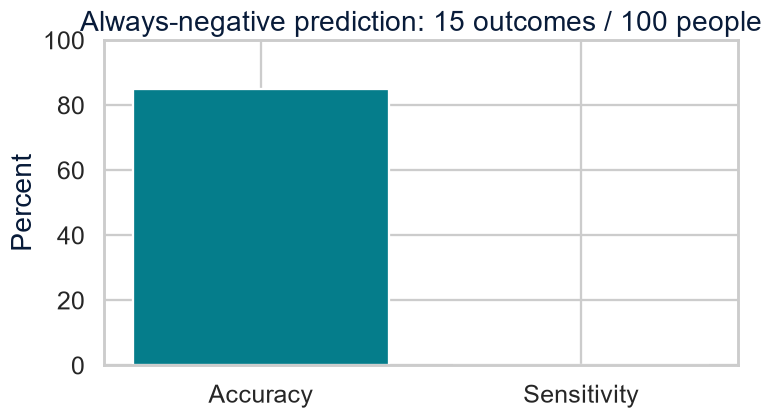

In [5]:
plt.figure(figsize=(7,4))
plt.bar(['Accuracy', 'Sensitivity'], [85, 0], color=['#057D8B','#DB5461'])
plt.ylim(0,100); plt.ylabel('Percent'); plt.title('Always-negative prediction: 15 outcomes / 100 people')
plt.tight_layout(); plt.savefig(OUT/'00_accuracy_trap.png'); plt.show()


The majority-class prediction looks accurate while missing every outcome. Unequal classes alone do not select a balancing method; the analytical objective does.


## The Framingham teaching copy
This is a cardiovascular-risk teaching CSV, not the complete original Framingham Heart Study. It contains 4,240 rows and 16 columns. The owner-supplied CSV is already published with Lesson 02; its source and rights are documented there. It is not relicensed here.

The target is the recorded binary `TenYearCHD` outcome. We study observed and adjusted associations, not causal effects. Age is in years; blood pressure is in mmHg; cigarettes/day is a count. Glucose and cholesterol are described in dataset units because the supplied CSV lacks a measurement codebook.


## Load the approved teaching dataset

Automatic download is attempted first. A failed download or a verification failure opens the Colab upload fallback. Upload exactly one approved Framingham CSV; schema and SHA-256 checks prevent substitution. Raw bytes and the original DataFrame remain unchanged.

**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Load and verify the approved teaching CSV.

**WHY ARE WE DOING IT?** Using the same source prevents accidental substitution.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** Source and filename, 4,240 rows, 16 columns, a hash, and the first five rows; upload is requested only if automatic loading fails.

In [6]:
DATA_SHA = '412c9ea5f0dfb7ad243dfcd1f2b4df500101904a8f443a22f3080394391853e9'
DATA_URL = 'https://raw.githubusercontent.com/amobionovo/EvidenceLab/f2dd06bab1378ffa52a5735e2e97c685e5d34a4c/lessons/02-missing-data/data/framingham.csv'

def load_approved_framingham(url=DATA_URL, fetch=None, upload=None):
    """Try the approved public bytes first; on failure request the same CSV in Colab."""
    import hashlib, io, urllib.request
    import pandas as pd
    expected_columns = ['male', 'age', 'education', 'currentSmoker', 'cigsPerDay',
                        'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes',
                        'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']
    def verify(raw):
        if hashlib.sha256(raw).hexdigest() != DATA_SHA:
            raise ValueError('This file differs from the approved Framingham teaching copy. No substitute dataset was loaded.')
        data = pd.read_csv(io.BytesIO(raw))
        if list(data.columns) != expected_columns or data.shape != (4240, 16):
            raise ValueError('Unexpected schema or dimensions in the approved teaching copy.')
        if data.TenYearCHD.isna().any() or set(data.TenYearCHD.unique()) != {0, 1}:
            raise ValueError('The recorded outcome must be complete and binary.')
        return data
    try:
        raw = fetch(url) if fetch else urllib.request.urlopen(url, timeout=30).read()
        data = verify(raw)
        source, filename = url, 'framingham.csv'
    except Exception as exc:
        print(f'Approved-source loading failed: {type(exc).__name__}: {exc}')
        print('Upload the approved framingham.csv teaching file; a different dataset will be rejected.')
        if upload is None:
            try:
                from google.colab import files
            except ImportError:
                raise RuntimeError('Automatic loading failed. The upload fallback requires Google Colab; no dataset was substituted.') from exc
            upload = files.upload
        uploaded = upload()
        if len(uploaded) != 1:
            raise ValueError('Upload exactly one approved Framingham CSV.')
        filename, raw = next(iter(uploaded.items()))
        if not filename.lower().endswith('.csv'):
            raise ValueError('The upload must be a CSV.')
        data = verify(raw)
        source = 'Google Colab upload — verified against the approved public copy'
    print(f'Source: {source}\nFilename: {filename}\nRows: {len(data):,}\nColumns: {data.shape[1]}')
    print(f'SHA-256: {DATA_SHA}')
    return data, {'source': source, 'filename': filename, 'rows': len(data), 'columns': data.shape[1], 'sha256': DATA_SHA}

df_raw, data_receipt = load_approved_framingham()
df = df_raw.copy(deep=True)
display(df.head())

print('✓ Dataset loaded successfully')


Source: https://raw.githubusercontent.com/amobionovo/EvidenceLab/f2dd06bab1378ffa52a5735e2e97c685e5d34a4c/lessons/02-missing-data/data/framingham.csv
Filename: framingham.csv
Rows: 4,240
Columns: 16
SHA-256: 412c9ea5f0dfb7ad243dfcd1f2b4df500101904a8f443a22f3080394391853e9


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.000,0,0.000,0.000,0,0,0,195.000,106.000,70.000,26.970,80.000,77.000,0
1,0,46,2.000,0,0.000,0.000,0,0,0,250.000,121.000,81.000,28.730,95.000,76.000,0
2,1,48,1.000,1,20.000,0.000,0,0,0,245.000,127.500,80.000,25.340,75.000,70.000,0
3,0,61,3.000,1,30.000,0.000,0,1,0,225.000,150.000,95.000,28.580,65.000,103.000,1
4,0,46,3.000,1,23.000,0.000,0,0,0,285.000,130.000,84.000,23.100,85.000,85.000,0


✓ Dataset loaded successfully


## Framingham at a Glance

Start with denominators and data quality before comparing outcomes.

**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Summarize the cohort and recorded outcome.

**WHY ARE WE DOING IT?** Counts and denominators give every later comparison context.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** Nine summary cards and an outcome donut; the recorded CHD proportion is about 15.2%.

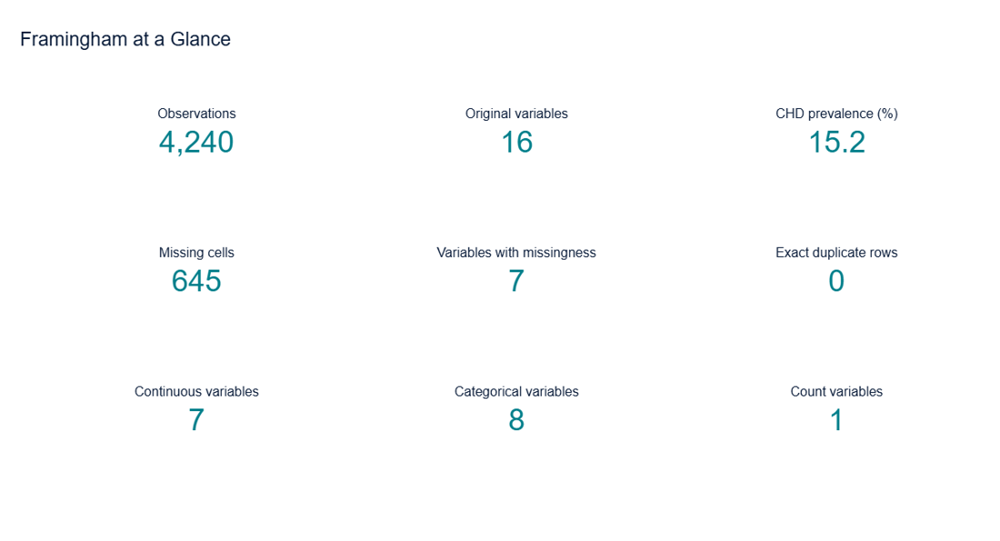

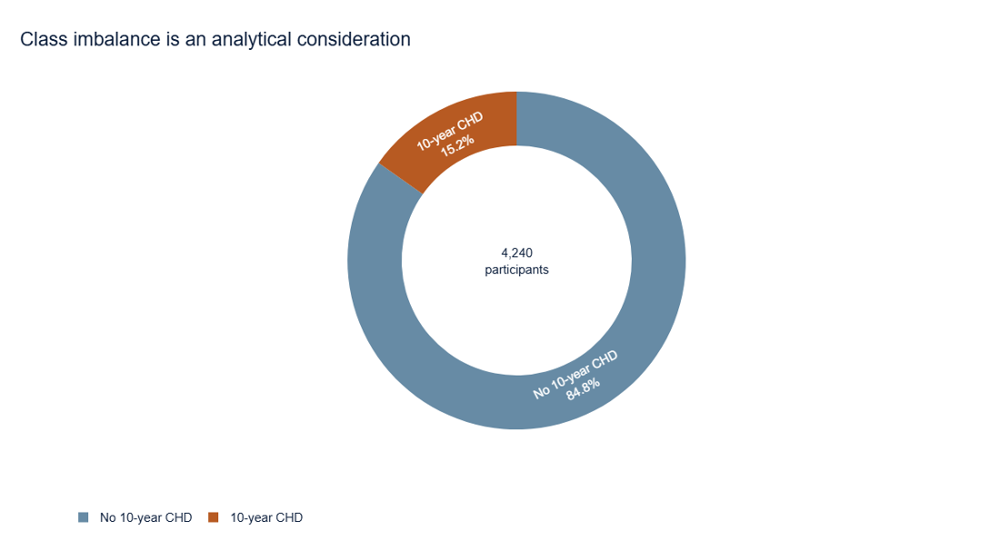

Class imbalance is an analytical consideration, not an automatic instruction to resample.


In [7]:

role_map={'male':'categorical','age':'continuous','education':'categorical','currentSmoker':'categorical',
'cigsPerDay':'count','BPMeds':'categorical','prevalentStroke':'categorical','prevalentHyp':'categorical',
'diabetes':'categorical','totChol':'continuous','sysBP':'continuous','diaBP':'continuous','BMI':'continuous',
'heartRate':'continuous','glucose':'continuous','TenYearCHD':'categorical'}
kpis={'Observations':len(df),'Original variables':df.shape[1],'CHD prevalence (%)':100*df.TenYearCHD.mean(),
'Missing cells':int(df.isna().sum().sum()),'Variables with missingness':int(df.isna().any().sum()),
'Exact duplicate rows':int(df.duplicated().sum()),'Continuous variables':sum(v=='continuous' for v in role_map.values()),
'Categorical variables':sum(v=='categorical' for v in role_map.values()),'Count variables':sum(v=='count' for v in role_map.values())}
dashboard=make_subplots(rows=3,cols=3,specs=[[{'type':'indicator'}]*3 for _ in range(3)])
for i,(label,value) in enumerate(kpis.items()):
 dashboard.add_trace(go.Indicator(mode='number',value=value,title={'text':label,'font':{'size':16}},number={'valueformat':'.1f' if '%' in label else ',d','font':{'size':36,'color':TEAL}}),row=i//3+1,col=i%3+1)
show(dashboard,'dashboard','Framingham at a Glance').update_layout(height=650)
counts=df.TenYearCHD.value_counts().reindex([0,1])
donut=go.Figure(go.Pie(labels=OUTCOME_ORDER,values=counts,hole=.68,sort=False,
 marker={'colors':list(OUTCOME_COLORS.values())},textinfo='label+percent',hovertemplate='%{label}<br>N=%{value:,}<br>%{percent}<extra></extra>'))
donut.add_annotation(text=f'{len(df):,}<br>participants',x=.5,y=.5,showarrow=False)
show(donut,'class_distribution','Class imbalance is an analytical consideration')
print('Class imbalance is an analytical consideration, not an automatic instruction to resample.');


### What to look for

Compare outcome counts and percentages. The role audit treats cigarettes/day as a count, distinct from continuous and categorical variables.

### What this does NOT tell us

Outcome imbalance does not identify the correct model or justify resampling for inference.

## BEGINNER GLOSSARY — read this before Step 1

| Term | Plain-language meaning |
|---|---|
| Dataset | A collection of recorded information; here it is the Framingham teaching CSV. |
| Row | One record in the table; here each row represents one participant record. |
| Column | One named field running down the table, such as age. |
| Variable | Something recorded that can differ between participants, such as age or smoking status. |
| Outcome | The result we study; here it is whether ten-year coronary heart disease (CHD) was recorded. |
| Predictor | A recorded characteristic included to help explain or predict an outcome; it need not cause that outcome. |
| Continuous variable | A measurement whose numerical scale matters, such as blood pressure, even when recorded values are rounded. |
| Categorical variable | A field that places records into groups, such as current smoker: yes or no. |
| Ordinal variable | A grouped field with an order, such as education codes, without assuming equal gaps between groups. |
| Missing value | Information that was not recorded or is unavailable; it is not automatically zero or “no.” |
| Outlier | An unusually distant value that deserves investigation and is not automatically an error. |
| Distribution | The pattern of values, showing where they gather and how widely they spread. |
| Univariate analysis | Exploring one variable at a time. |
| Bivariate analysis | Exploring how two variables relate to each other. |
| Correlation | A number describing how two numerical variables move together in a specified way; it does not establish causation. |
| Feature engineering | Creating an informative new variable from existing fields while preserving the original information. |
| IQR | The spread of the middle half of the values, called the interquartile range; it helps flag unusual values. |
| KDE | A smooth estimate of a distribution's shape, called kernel density estimation; its shape depends on smoothing choices. |
| Confidence interval | A range expressing uncertainty in an estimate under the method's assumptions; a 95% procedure has 95% coverage over repeated samples under those assumptions. |
| Odds ratio | A comparison of odds between groups or predictor increments; odds are the chance of an outcome divided by the chance of no outcome, and differ from risk. |
| Logistic regression | A statistical model for a yes/no outcome; here it estimates associations while accounting for the other included predictors. |
| ROC-AUC | A summary of how well scores rank outcome records above non-outcome records across thresholds; 0.5 is chance-level ranking and 1 is perfect ranking. |
| PR-AUC | Area under a precision–recall curve, combining how often flagged records have the outcome with how many outcome records are found; this notebook labels trapezoidal PR-AUC separately from average precision. |
| Calibration | How closely predicted probabilities agree with observed outcome proportions. |
| Brier score | The average squared gap between each predicted probability and the recorded yes/no outcome; lower values mean smaller squared errors. |

**Before the charts:** a histogram counts values in ranges; a boxplot shows the median, middle-half spread and flagged values; a violin shows a smoothed distribution shape; a scatter plot places each record using two measurements; a heatmap uses color to show a value in each cell. **N** means the number of records; **prevalence** means the proportion with the recorded outcome; a **denominator** is the total used to calculate that proportion. **Apparent performance** means the same records fitted and evaluated the model; it is not held-out or external validation.


## STEP 1 — QUESTION

**Step 1 of 9 · ⭐ BEGINNER CORE**

Before touching an algorithm, define the analytical question.

> **What demographic, behavioral, metabolic, and cardiovascular patterns distinguish participants who develop coronary heart disease within 10 years from those who do not?**

The outcome in this dataset is `TenYearCHD`, coded 1 for a recorded 10-year CHD outcome and 0 otherwise.

This lesson uses the model for **association and interpretation**, not causal inference.


**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Count outcome and non-outcome records.

**WHY ARE WE DOING IT?** Percentages should always be tied to their denominators.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** A two-row count and percentage table: 644 outcome records among 4,240 total.

In [8]:
outcome_counts = df["TenYearCHD"].value_counts().sort_index()
outcome_pct = df["TenYearCHD"].value_counts(normalize=True).sort_index() * 100

outcome_summary = pd.DataFrame({
    "n": outcome_counts,
    "percent": outcome_pct
})
outcome_summary.index = ["No 10-year CHD", "10-year CHD"]
outcome_summary


,n,percent
No 10-year CHD,3596,84.811
10-year CHD,644,15.189


**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Calculate the majority-only accuracy benchmark.

**WHY ARE WE DOING IT?** An easy prediction baseline exposes the limits of accuracy.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** Observed prevalence and majority-class accuracy, with a teaching note.

In [9]:
chd_prevalence = df["TenYearCHD"].mean()
majority_accuracy = max(chd_prevalence, 1 - chd_prevalence)

print(f"Observed 10-year CHD prevalence: {chd_prevalence:.1%}")
print(f"Accuracy from predicting the majority class for everyone: {majority_accuracy:.1%}")
print()
print("Teaching point: accuracy alone would be misleading for a predictive model.")


Observed 10-year CHD prevalence: 15.2%
Accuracy from predicting the majority class for everyone: 84.8%

Teaching point: accuracy alone would be misleading for a predictive model.


## STEP 2 — AUDIT

**Step 2 of 9 · ⭐ BEGINNER CORE**

A rigorous audit asks:

- What is missing?
- What is duplicated?
- What is impossible?
- What is unusual?
- What is inconsistent?

Do not begin by deleting observations. First understand what you are seeing.

**CHECK → CLEAN → VERIFY → ANALYZE.** We begin with checks, preserve raw values and document every repair before interpreting associations.


**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Audit types, missingness and distinct values.

**WHY ARE WE DOING IT?** Missing information can change the eligible model sample.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** A table ranked by missing percentage; glucose has 388 missing values, about 9.15%.

In [10]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_n": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "unique_n": df.nunique(dropna=True)
}).sort_values("missing_pct", ascending=False)

audit


,dtype,missing_n,missing_pct,unique_n
glucose,float64,388,9.151,143
education,float64,105,2.476,4
BPMeds,float64,53,1.250,2
totChol,float64,50,1.179,248
cigsPerDay,float64,29,0.684,33
BMI,float64,19,0.448,1364
heartRate,float64,1,0.024,73
male,int64,0,0.000,2
prevalentHyp,int64,0,0.000,2
prevalentStroke,int64,0,0.000,2


**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Check exact duplicate rows and negative numerical values.

**WHY ARE WE DOING IT?** Quality checks identify records that need review before interpretation.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** The counts and a completion message; no records are deleted.

In [11]:
print("Exact duplicate rows:", df.duplicated().sum())

numeric_cols = df.select_dtypes(include=np.number).columns
negative_counts = (df[numeric_cols] < 0).sum()
negative_counts = negative_counts[negative_counts > 0]

if negative_counts.empty:
    print("Negative numeric values: none detected")
else:
    print("Negative numeric values detected:")
    print(negative_counts)

print('✓ Data audit complete — no original records were deleted')


Exact duplicate rows: 0
Negative numeric values: none detected
✓ Data audit complete — no original records were deleted


### Missingness is not just a percentage

A missing-data percentage tells us **how much** is missing, not **why** it is missing.

For publication-grade inference, the missingness mechanism should be considered before choosing complete-case analysis, single imputation, or multiple imputation.


## STEP 3 — TYPE

**Step 3 of 9 · ⭐ BEGINNER CORE**

Variable type determines which summaries, plots, transformations, and statistical models are appropriate.

For this lesson:

- **Binary categorical:** male, currentSmoker, BPMeds, prevalentStroke, prevalentHyp, diabetes, TenYearCHD
- **Ordinal categorical:** education
- **Count:** cigsPerDay
- **Continuous:** age, totChol, sysBP, diaBP, BMI, heartRate, glucose

Continuous/discrete describe variable forms. Nominal/ordinal describe categorical structure. Interval/ratio describe measurement scales. These concepts should not be treated as interchangeable.


**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Label variable roles.

**WHY ARE WE DOING IT?** A measurement and a category need different summaries and plots.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** A table describing each variable as continuous, count, categorical or outcome.

In [12]:
variable_roles = {
    "male": "Binary categorical",
    "age": "Continuous",
    "education": "Ordinal categorical",
    "currentSmoker": "Binary categorical",
    "cigsPerDay": "Count",
    "BPMeds": "Binary categorical",
    "prevalentStroke": "Binary categorical",
    "prevalentHyp": "Binary categorical",
    "diabetes": "Binary categorical",
    "totChol": "Continuous",
    "sysBP": "Continuous",
    "diaBP": "Continuous",
    "BMI": "Continuous",
    "heartRate": "Continuous",
    "glucose": "Continuous",
    "TenYearCHD": "Binary outcome"
}

pd.DataFrame(
    {"variable": list(variable_roles.keys()), "role": list(variable_roles.values())}
)


,variable,role
0,male,Binary categorical
1,age,Continuous
2,education,Ordinal categorical
3,currentSmoker,Binary categorical
4,cigsPerDay,Count
5,BPMeds,Binary categorical
6,prevalentStroke,Binary categorical
7,prevalentHyp,Binary categorical
8,diabetes,Binary categorical
9,totChol,Continuous


## Missingness: magnitude, co-occurrence and outcome groups

Inspect exact counts and within-outcome denominators. The matrix shows all observations in their original order.

**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Compare missingness overall, across rows and across outcome groups.

**WHY ARE WE DOING IT?** The amount missing and its pattern are different questions.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** Missingness bars, a row-by-variable matrix, group comparisons and a static bar chart; hover for counts and group denominators.

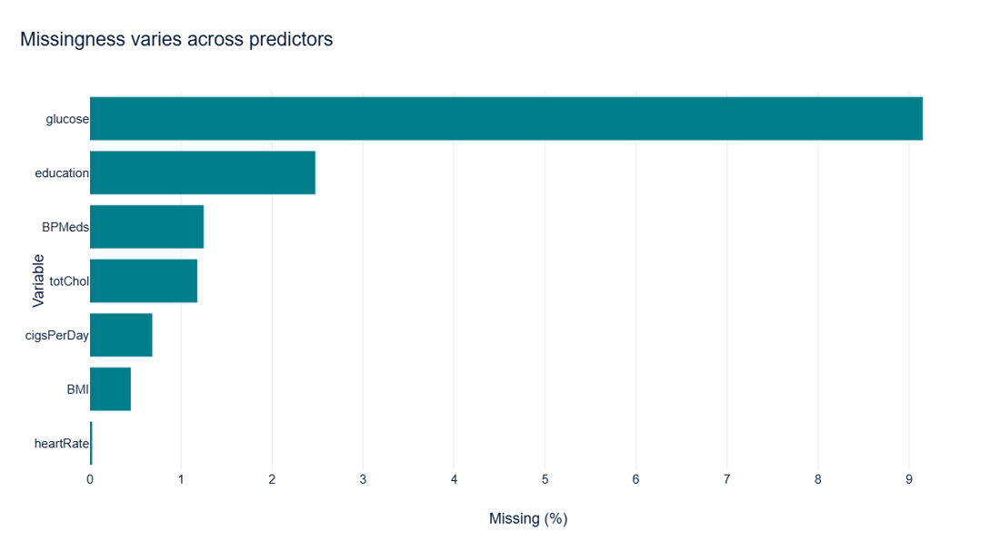

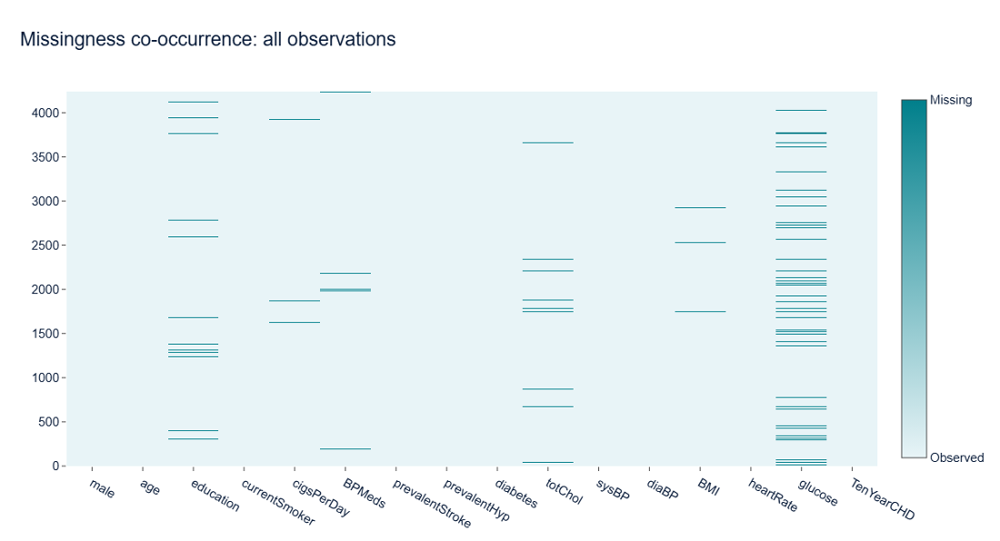

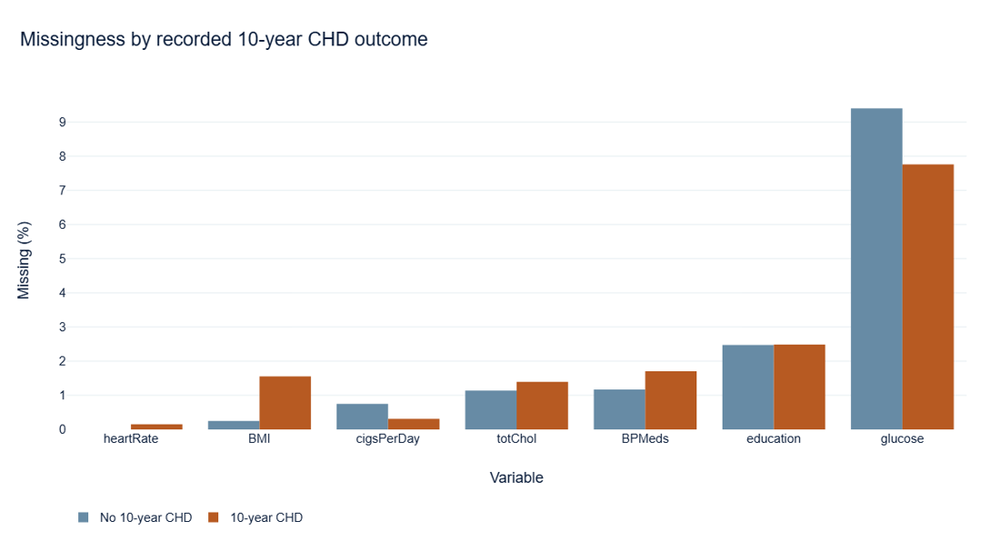

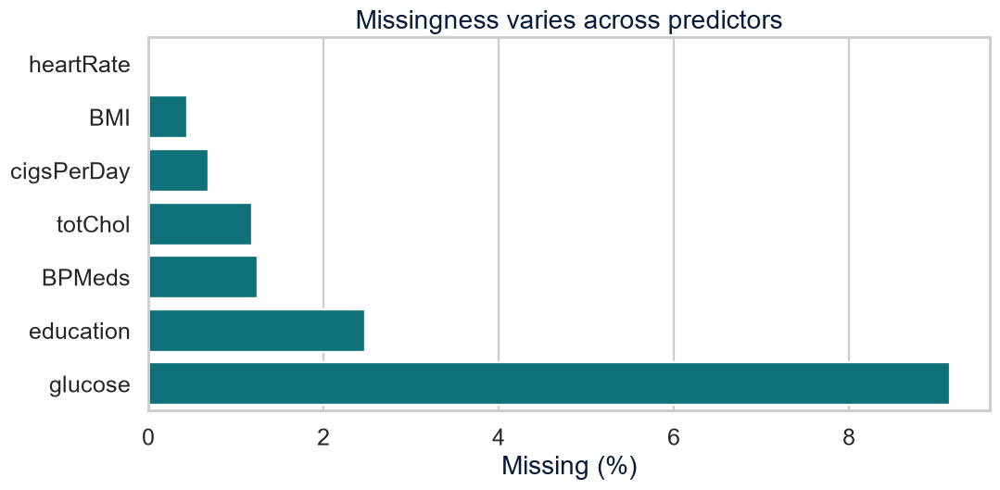

In [13]:

missing=pd.DataFrame({'variable':df.columns,'n':df.isna().sum().values,'pct':100*df.isna().mean().values}).query('n>0').sort_values('pct')
f=px.bar(missing,x='pct',y='variable',orientation='h',custom_data=['n'],color_discrete_sequence=[TEAL],labels={'pct':'Missing (%)','variable':'Variable'})
f.update_traces(hovertemplate='%{y}<br>Missing N=%{customdata[0]:,}<br>Missing=%{x:.2f}%<extra></extra>')
show(f,'missingness','Missingness varies across predictors');f.update_xaxes(title='Missing (%)')
matrix=go.Figure(go.Heatmap(z=df.isna().astype(int).values,x=df.columns,y=np.arange(len(df)),
 colorscale=[[0,'#E8F4F7'],[1,TEAL]],zmin=0,zmax=1,colorbar={'tickvals':[0,1],'ticktext':['Observed','Missing']},
 hovertemplate='Row position %{y}<br>%{x}<br>Missing indicator: %{z}<extra></extra>'))
show(matrix,'missingness_matrix','Missingness co-occurrence: all observations')
mr=[]
for col in missing.variable:
 for outcome,g in df.groupby('TenYearCHD'):
  mr.append({'variable':col,'outcome':OUTCOME_ORDER[int(outcome)],'n':len(g),'missing_n':g[col].isna().sum(),'missing_pct':100*g[col].isna().mean()})
mr=pd.DataFrame(mr)
show(px.bar(mr,x='variable',y='missing_pct',color='outcome',barmode='group',color_discrete_map=OUTCOME_COLORS,
 hover_data=['n','missing_n'],labels={'missing_pct':'Missing (%)','variable':'Variable'}), 'missingness_outcome','Missingness by recorded 10-year CHD outcome')
fig,ax=plt.subplots(figsize=(10,5));sns.barplot(data=missing,x='pct',y='variable',color=TEAL,ax=ax)
ax.set(xlabel='Missing (%)',ylabel='',title='Missingness varies across predictors');finish_static(fig,'01_missingness')
mr.to_csv(VIS/'missingness_by_outcome.csv',index=False);


### What to look for

Compare glucose missingness across outcome groups and look for co-occurring missing fields.

### What this does NOT tell us

Missingness pattern does not establish the missingness mechanism. These graphics cannot establish MCAR, MAR or MNAR.

## STEP 4 — REPAIR

**Step 4 of 9 · ⭐ BEGINNER CORE**

### Outliers: flag, verify, understand, decide

The 1.5 × IQR rule is useful for **flagging** unusual observations. It is not an automatic deletion rule.

In clinical data, an extreme blood pressure or glucose value may be unusual and clinically important at the same time.


**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Calculate IQR flags for unusual values.

**WHY ARE WE DOING IT?** A flag starts an investigation; it does not justify deletion.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** A table of IQR fences and flagged counts; all original records remain.

In [14]:
continuous = ["age", "totChol", "sysBP", "diaBP", "BMI", "heartRate", "glucose"]

def iqr_outlier_summary(data, columns):
    rows = []
    for col in columns:
        s = data[col].dropna()
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        low = q1 - 1.5 * iqr
        high = q3 + 1.5 * iqr
        n_flagged = ((s < low) | (s > high)).sum()
        rows.append({
            "variable": col,
            "Q1": q1,
            "Q3": q3,
            "lower_fence": low,
            "upper_fence": high,
            "flagged_n": int(n_flagged),
            "flagged_pct": 100 * n_flagged / len(s)
        })
    return pd.DataFrame(rows).sort_values("flagged_n", ascending=False)

outlier_summary = iqr_outlier_summary(df, continuous)
outlier_summary

print('✓ Outlier flags calculated — no original records were deleted')


✓ Outlier flags calculated — no original records were deleted


## Outlier ≠ Error

Inspect extreme values in context. Flags change display symbols, never analytical values or row eligibility.

**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Inspect flagged and unflagged measurements by outcome.

**WHY ARE WE DOING IT?** Unusual clinical values may be real and informative.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** Strip and distribution views with flags and fences; no automatic removal occurs.

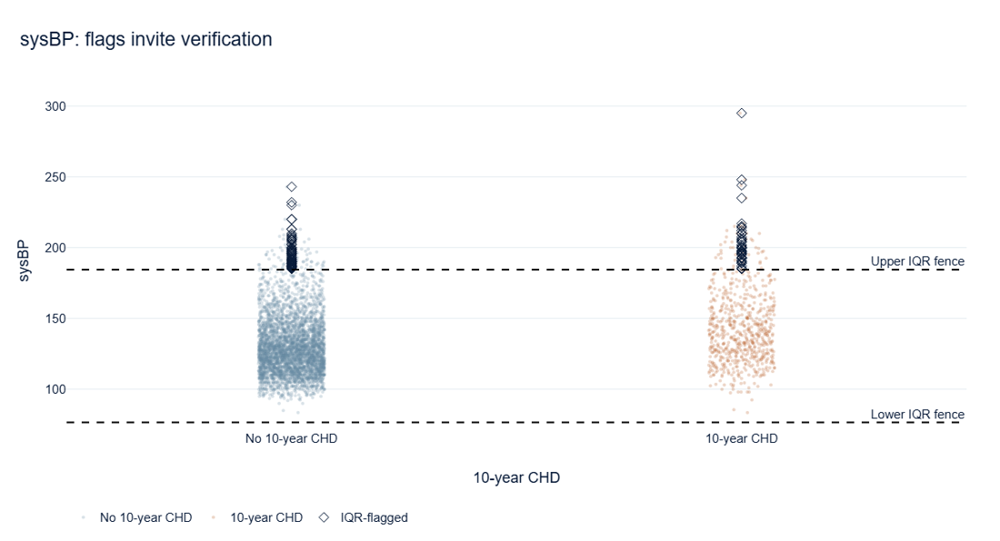

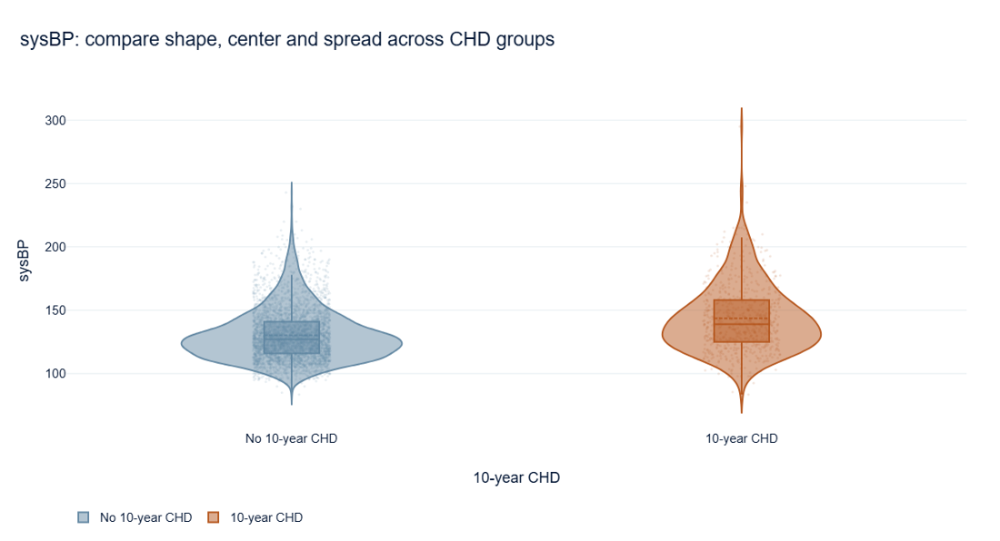

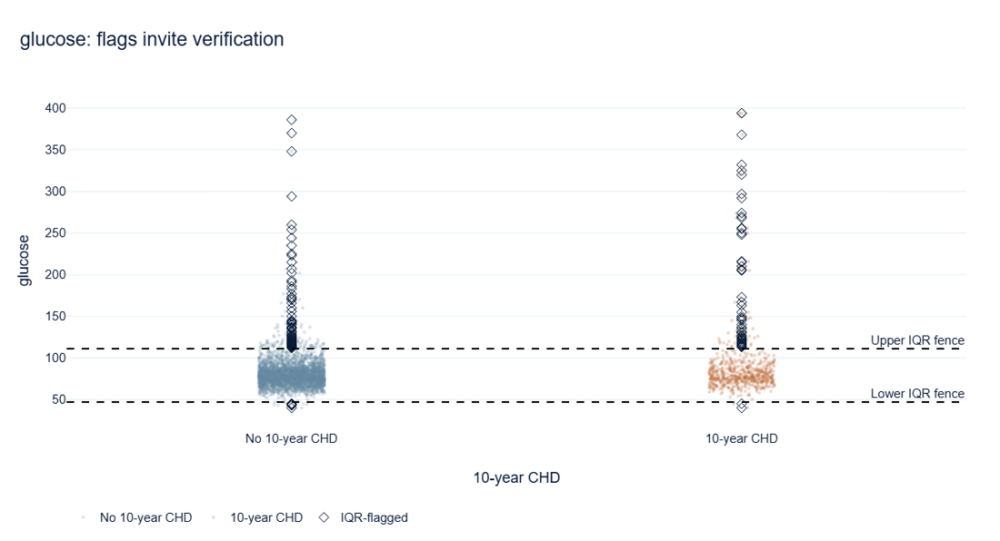

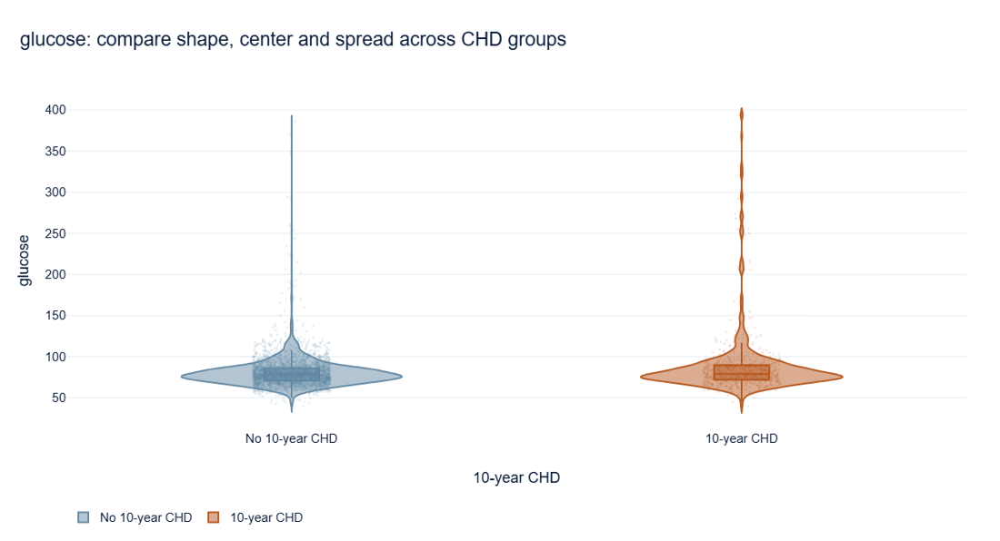

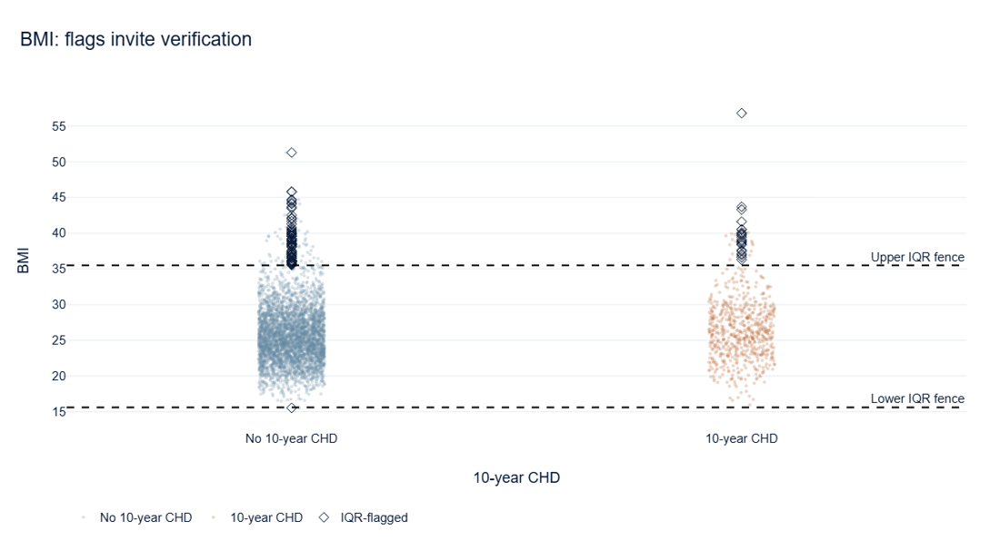

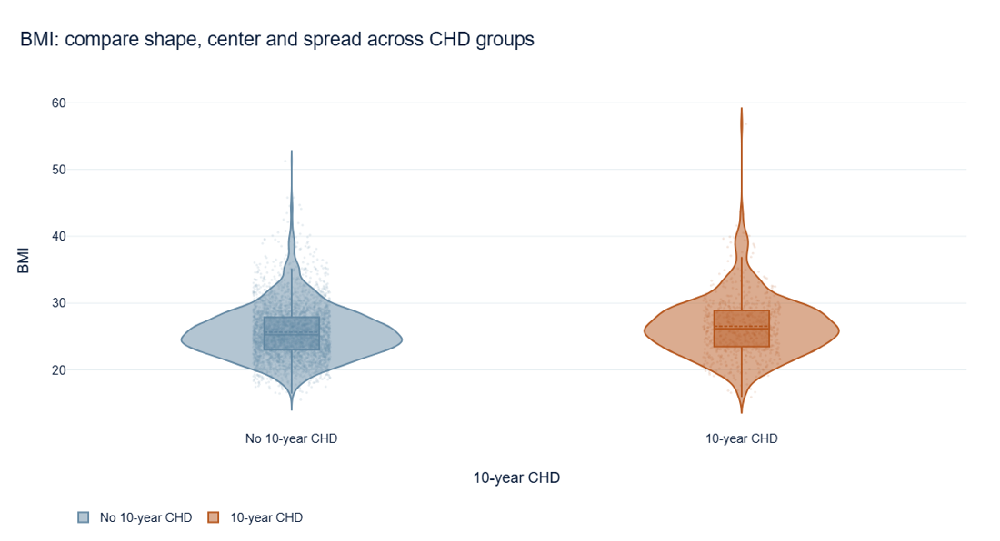

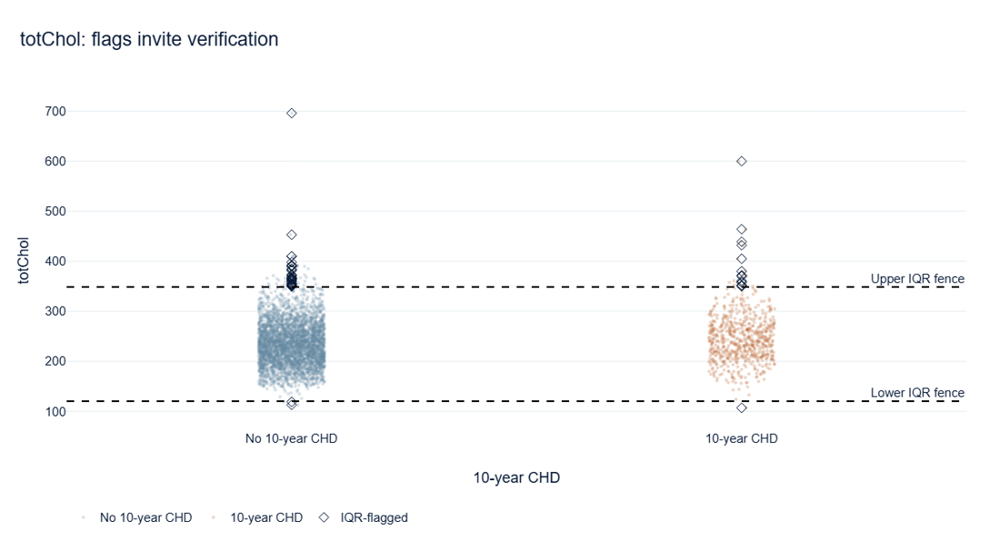

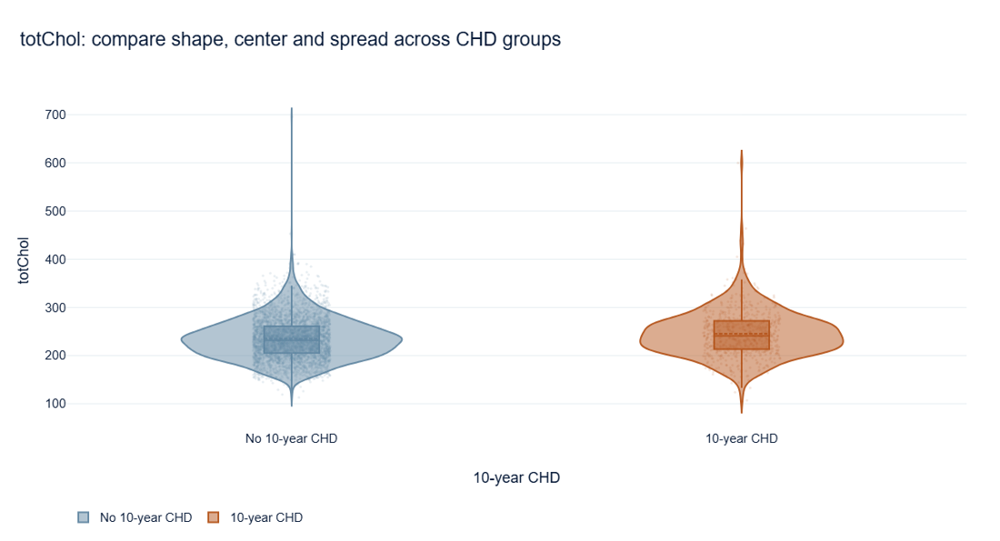

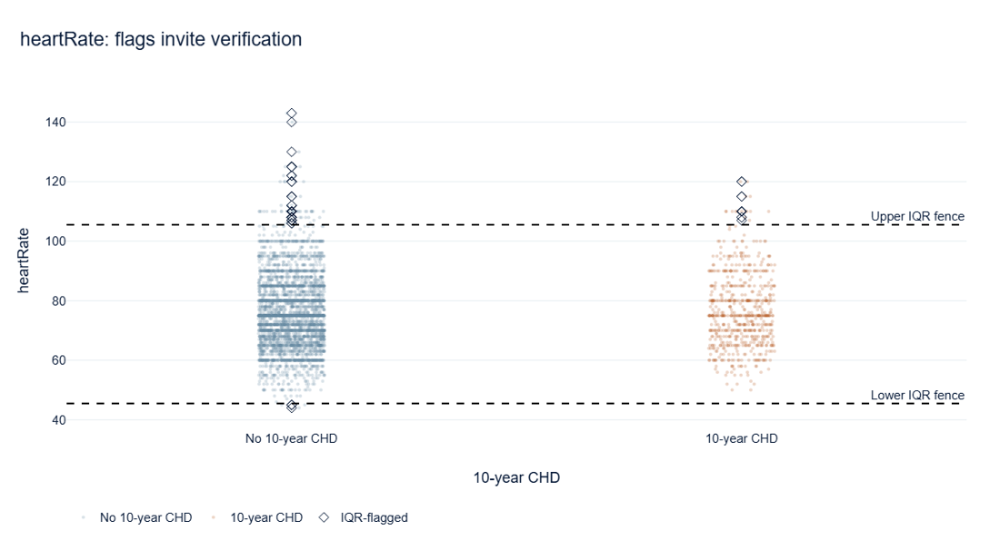

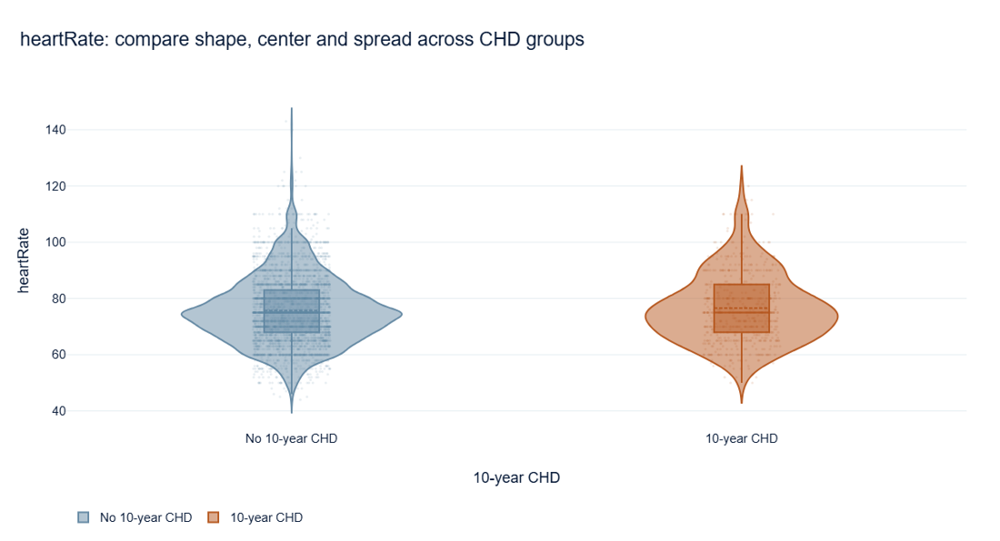

In [15]:

for col in ['sysBP','glucose','BMI','totChol','heartRate']:
 d=humanize(df).dropna(subset=[col]);q1,q3=d[col].quantile([.25,.75]);iqr=q3-q1;lo,hi=q1-1.5*iqr,q3+1.5*iqr
 d['IQR flag']=np.where((d[col]<lo)|(d[col]>hi),'Flagged','Within fences')
 f=px.strip(d,x='10-year CHD',y=col,color='10-year CHD',color_discrete_map=OUTCOME_COLORS,
  hover_data=[col,'age','sysBP','BMI','glucose','IQR flag'])
 f.add_hline(y=lo,line_dash='dash',annotation_text='Lower IQR fence');f.add_hline(y=hi,line_dash='dash',annotation_text='Upper IQR fence')
 f.update_traces(marker={'size':4,'opacity':.25})
 flagged=d.query('`IQR flag` == "Flagged"')
 f.add_trace(go.Scatter(x=flagged['10-year CHD'],y=flagged[col],mode='markers',name='IQR-flagged',
  marker={'symbol':'diamond-open','color':NAVY,'size':9},hovertemplate=col+': %{y}<br>IQR-flagged<extra></extra>'))
 show(f,'outliers_'+col,f'{col}: flags invite verification')
 plot_distribution_by_outcome(df,col,'outlier_violin_'+col)
assert df.equals(df_raw);


### What to look for

Hover over flagged values; distinguish extreme measurements from verified invalid records. Statistical extremeness does not establish invalidity. Flag → Verify → Understand → Decide.

### What this does NOT tell us

Neither the IQR rule nor a violin plot establishes that a value is an error. No flagged observations have been deleted.

## STEP 5 — ENGINEER

**Step 5 of 9 · ⭐ BEGINNER CORE**

Feature engineering should make variables more informative or clinically interpretable.

We will create several **exploratory** features while preserving the original columns.

- Pulse pressure = systolic BP - diastolic BP
- Mean arterial pressure ≈ DBP + 1/3(SBP - DBP)
- Age bands for visualization
- Smoking-intensity groups for visualization
- BMI categories for visualization

For regression, continuous variables are usually retained as continuous unless there is a clear reason to categorize them.


**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Create exploratory features on a copy.

**WHY ARE WE DOING IT?** Pulse pressure and other summaries can make existing measurements easier to interpret.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** A preview with added features; original measurements and raw records remain unchanged.

In [16]:
df_eda = df.copy()

df_eda["pulse_pressure"] = df_eda["sysBP"] - df_eda["diaBP"]
df_eda["mean_arterial_pressure"] = (
    df_eda["diaBP"] + (df_eda["sysBP"] - df_eda["diaBP"]) / 3
)

df_eda["age_band"] = pd.cut(
    df_eda["age"],
    bins=[29, 39, 49, 59, np.inf],
    labels=["30s", "40s", "50s", "60+"]
)

df_eda["smoking_intensity"] = pd.cut(
    df_eda["cigsPerDay"],
    bins=[-0.1, 0, 10, 20, np.inf],
    labels=["0", "1-10", "11-20", ">20"]
)

df_eda["BMI_category"] = pd.cut(
    df_eda["BMI"],
    bins=[0, 18.5, 25, 30, np.inf],
    labels=["Underweight", "Normal", "Overweight", "Obesity"],
    right=False
)

display(df_eda[
    ["pulse_pressure", "mean_arterial_pressure", "age_band",
     "smoking_intensity", "BMI_category"]
].head())

print('✓ Exploratory features created on a copy of the data')


,pulse_pressure,mean_arterial_pressure,age_band,smoking_intensity,BMI_category
0,36.000,82.000,30s,0,Overweight
1,40.000,94.333,40s,0,Overweight
2,47.500,95.833,40s,11-20,Overweight
3,55.000,113.333,60+,>20,Overweight
4,46.000,99.333,40s,>20,Normal


✓ Exploratory features created on a copy of the data


Missing cigarettes/day remains missing in smoking groups. These categories summarize the data for exploration; the regression retains continuous smoking intensity.

## STEP 6 — EXPLORE

**Step 6 of 9 · ⭐ BEGINNER CORE**

Choose a variable from the dropdown. Histograms and KDEs use within-outcome density; each group integrates to approximately one.

**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Explore one variable in three views.

**WHY ARE WE DOING IT?** Counts, a smoothed shape and a boxplot show different aspects of the same distribution.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** A histogram, density view and boxplot; the dropdown changes the variable in all panels.

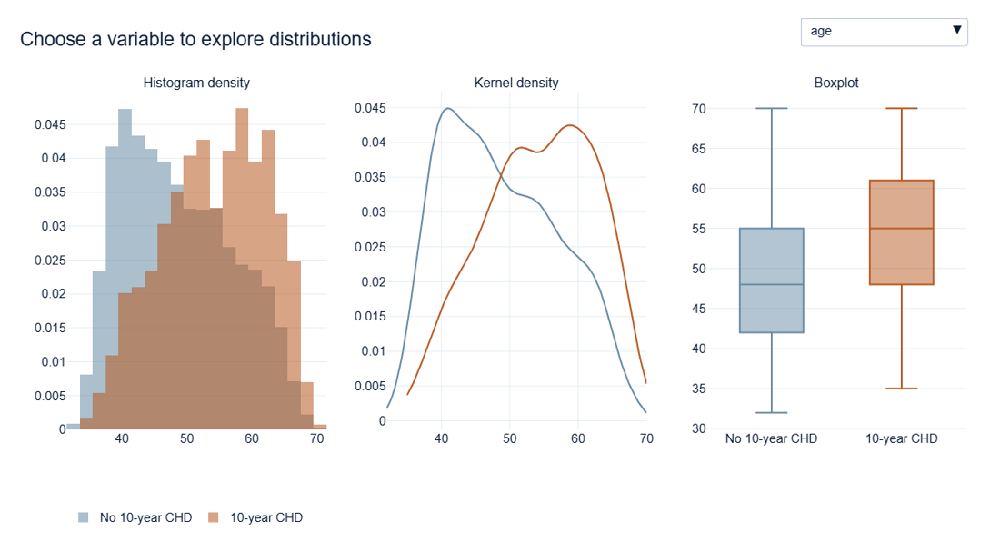

,sysBP
observed_n,"4,240.000"
missing_n,0.000
median,128.000
minimum,83.500
maximum,295.000
IQR_flags,126.000


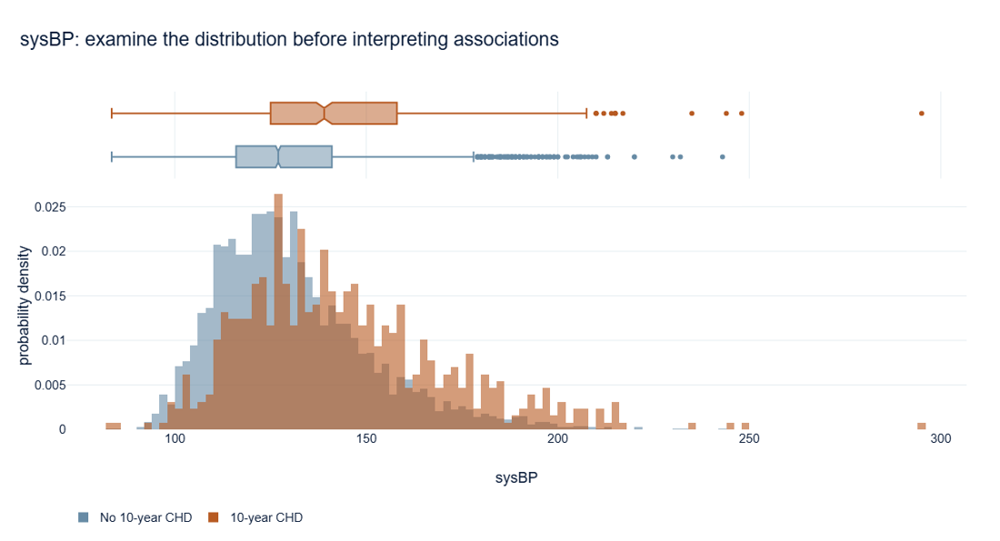

In [17]:

variables=['age','totChol','sysBP','diaBP','BMI','heartRate','glucose','cigsPerDay','pulse_pressure','mean_arterial_pressure']
f=make_subplots(rows=1,cols=3,subplot_titles=['Histogram density','Kernel density','Boxplot'])
per_variable=6
for j,col in enumerate(variables):
 for outcome in [0,1]:
  s=df_eda.loc[df_eda.TenYearCHD==outcome,col].dropna();label=OUTCOME_ORDER[outcome];color=OUTCOME_COLORS[label]
  visible=j==0;grid=np.linspace(s.min(),s.max(),160)
  f.add_trace(go.Histogram(x=s,histnorm='probability density',bingroup=col,nbinsx=30,name=label,legendgroup=label,
   marker_color=color,opacity=.55,visible=visible),row=1,col=1)
  f.add_trace(go.Scatter(x=grid,y=gaussian_kde(s)(grid),name=label,legendgroup=label,
   line={'color':color},showlegend=False,visible=visible),row=1,col=2)
  f.add_trace(go.Box(y=s,name=label,legendgroup=label,marker_color=color,showlegend=False,visible=visible),row=1,col=3)
buttons=[dict(label=col,method='update',args=[{'visible':[k//per_variable==j for k in range(len(f.data))]},
 {'title':{'text':f'{col}: compare distributions by outcome'}}]) for j,col in enumerate(variables)]
f.update_layout(barmode='overlay',updatemenus=[{'buttons':buttons,'x':1,'xanchor':'right','y':1.22}])
show(f,'distribution_explorer','Choose a variable to explore distributions')
explore_variable('sysBP');


### TRY IT YOURSELF — choose one variable

Change **only** the value on the `VARIABLE` line. Keep the quotation marks. Allowed choices: `age`, `glucose`, `sysBP`, `diaBP`, `BMI`, `totChol`, `heartRate`, `cigsPerDay`, `pulse_pressure`, `mean_arterial_pressure`. Click ▶ below. This reads the existing copy and changes only the displayed explorer; it does not change the data or model. Notice how spread and skew differ.

**What this does NOT tell us:** distribution shape alone does not establish an outcome association or explain missingness.

,glucose
observed_n,"3,852.000"
missing_n,388.000
median,78.000
minimum,40.000
maximum,394.000
IQR_flags,188.000


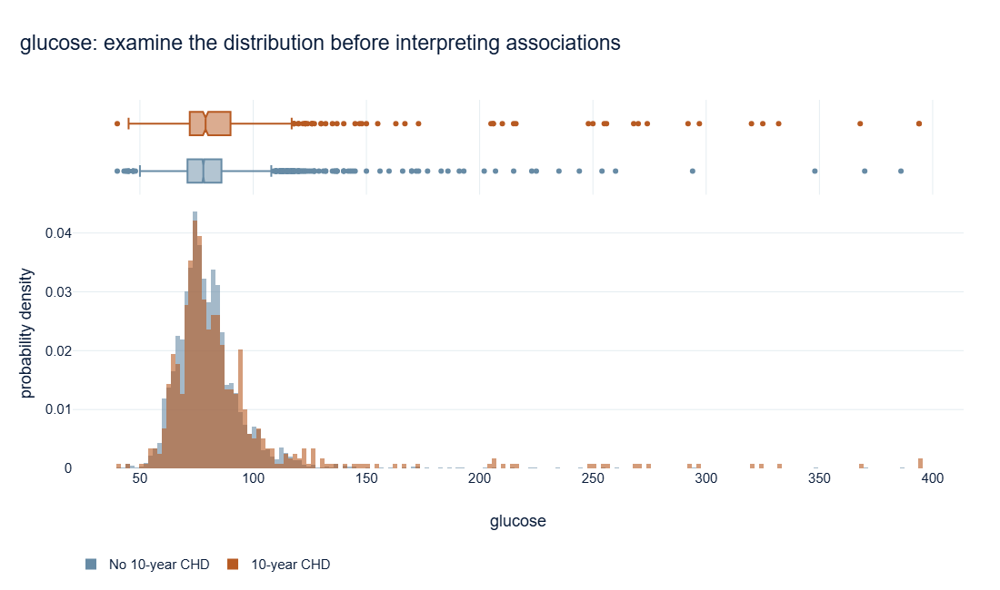

In [18]:
VARIABLE = "glucose"  # TRY IT: change only this quoted value.
if VARIABLE in variables:
    explore_variable(VARIABLE)
else:
    print("Choose a VARIABLE from:", ", ".join(variables))


### What to look for

Switch among original and engineered variables. Examine skew, tails and within-group shape; hide a group using the legend.

### What this does NOT tell us

KDE curves smooth recorded values and can extend beyond plausible boundaries. Density for discrete cigarettes/day is an exploratory approximation, not a probability mass function or an adjusted association.

## Outcome comparisons: distributions beyond averages

Compare all five requested predictors using violin, box and point layers.

**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Compare distributions across outcome groups.

**WHY ARE WE DOING IT?** An average alone hides spread, overlap and unusual values.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** Violin, box and point views for five measurements; overlapping groups do not determine an individual outcome.

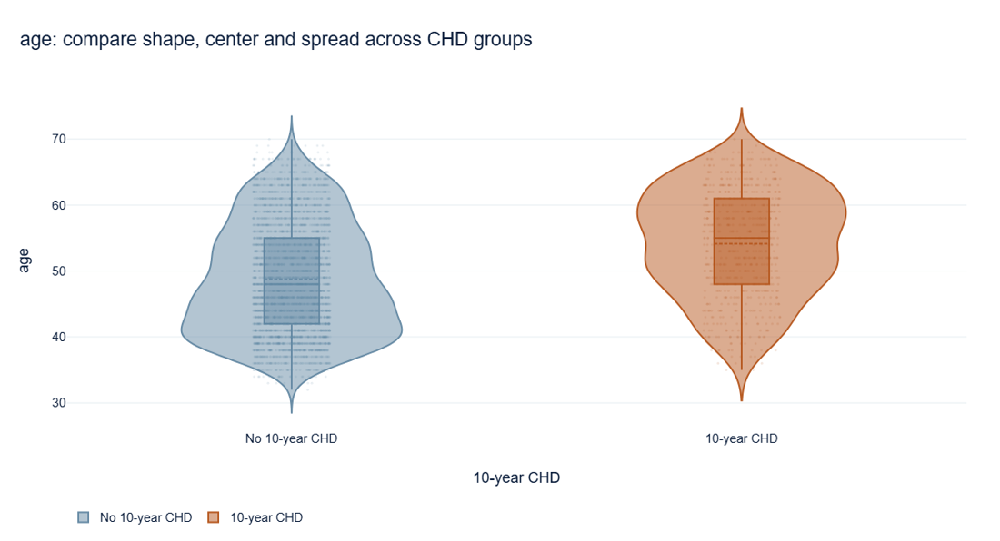

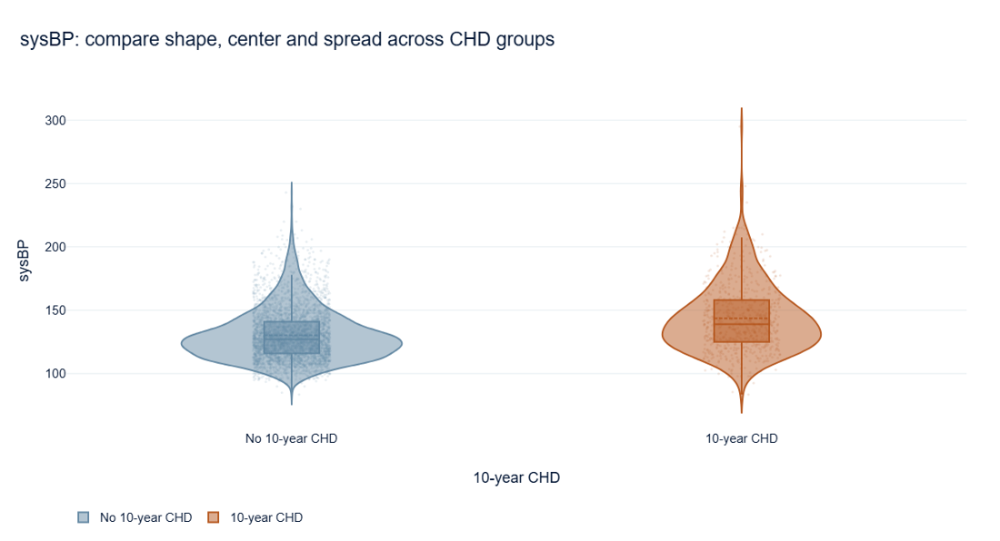

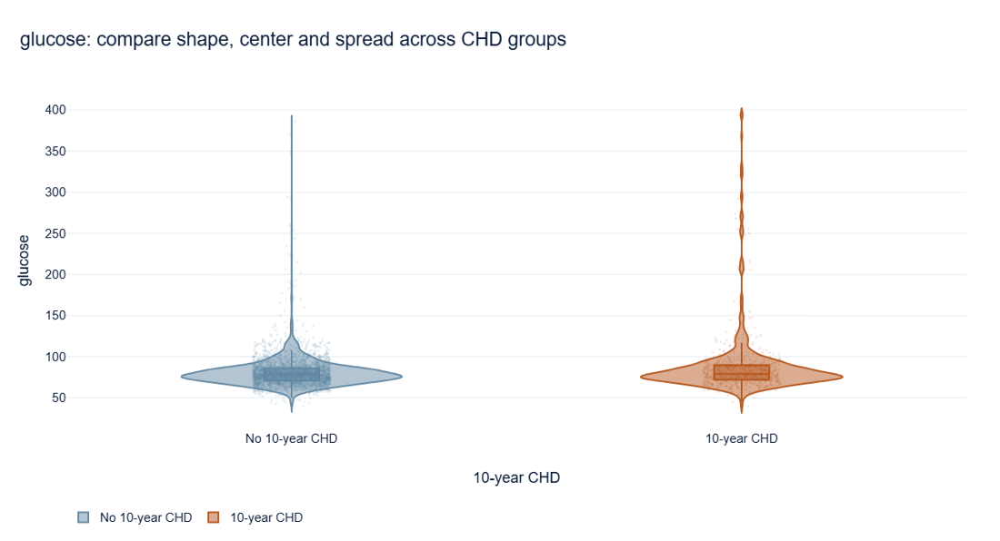

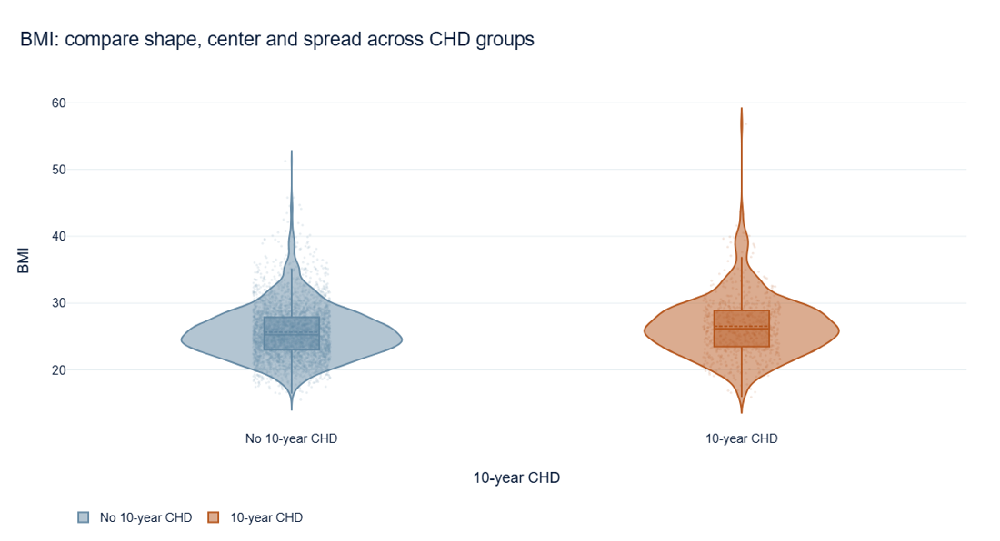

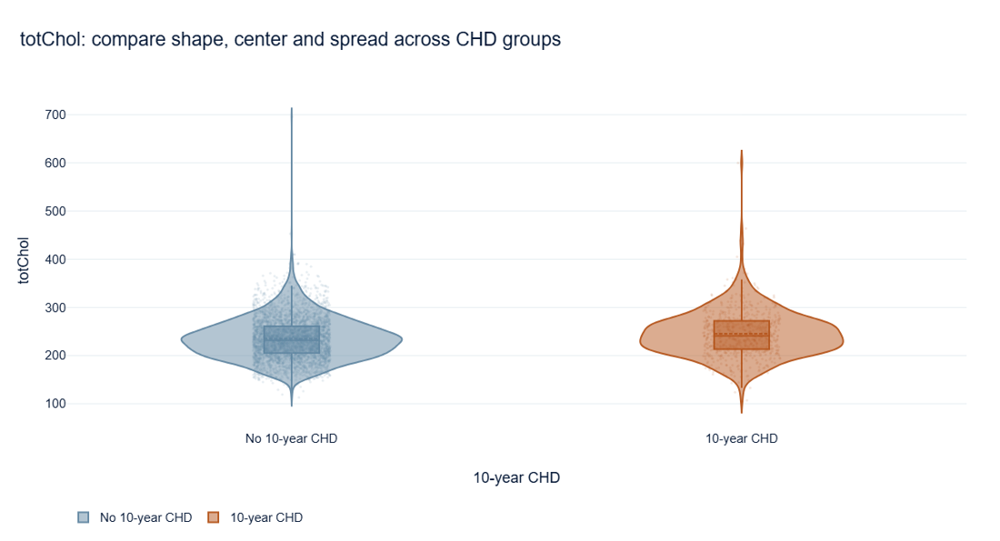

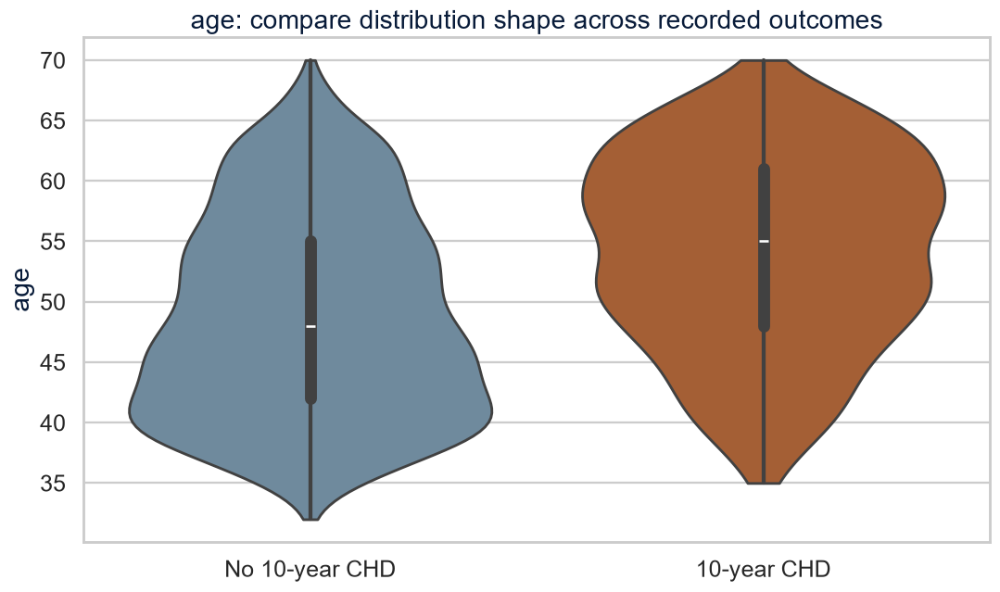

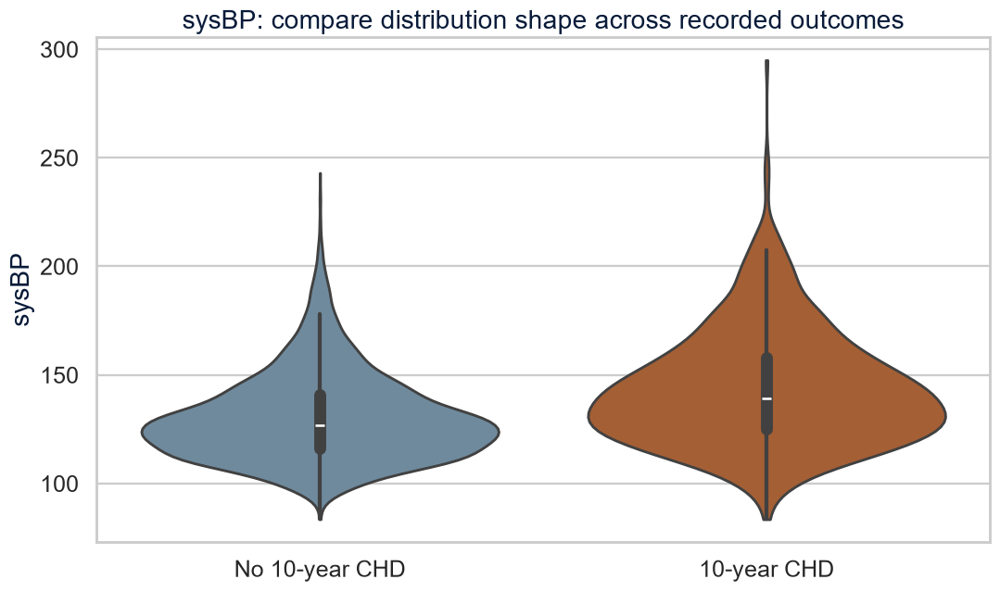

In [19]:

for col in ['age','sysBP','glucose','BMI','totChol']:plot_distribution_by_outcome(df_eda,col)
for col,name in [('age','02_age_outcome_distribution'),('sysBP','03_sbp_outcome_distribution')]:
 fig,ax=plt.subplots(figsize=(10,6));d=humanize(df_eda)
 sns.violinplot(data=d,x='10-year CHD',y=col,hue='10-year CHD',palette=OUTCOME_COLORS,inner='box',cut=0,ax=ax,legend=False)
 ax.set(title=f'{col}: compare distribution shape across recorded outcomes',xlabel='',ylabel=col)
 finish_static(fig,name);


### What to look for

Compare medians, spread and distribution overlap, including the width of the tails.

### What this does NOT tell us

Visual separation alone does not establish statistical significance or an independent effect.

## Age and cardiovascular risk landscape

Use grouped outcomes rather than connecting individual participants as though these were longitudinal trajectories.

**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Explore age distributions and grouped observed prevalence.

**WHY ARE WE DOING IT?** Denominators and uncertainty matter when comparing age bands.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** Age distributions and observed prevalence with uncertainty intervals; these are unadjusted group summaries.

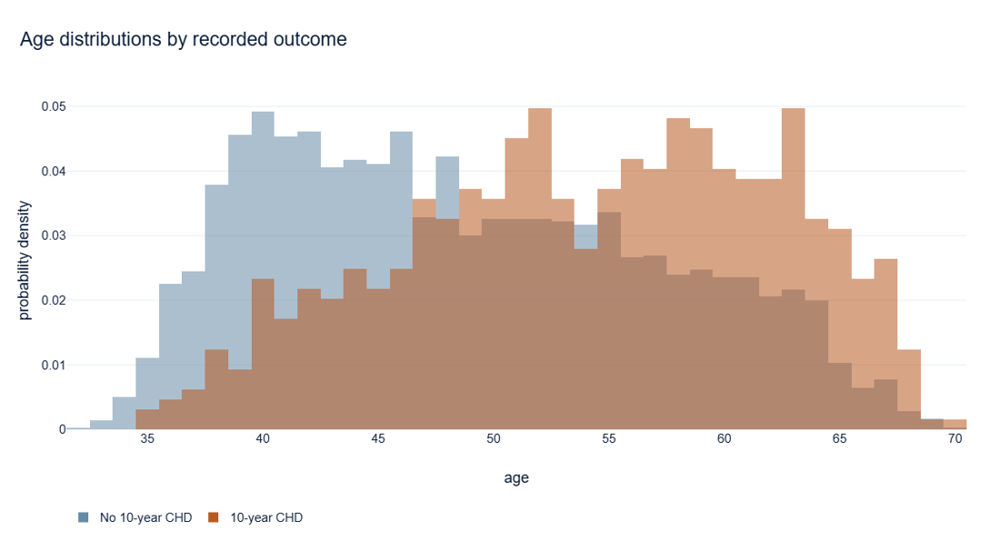

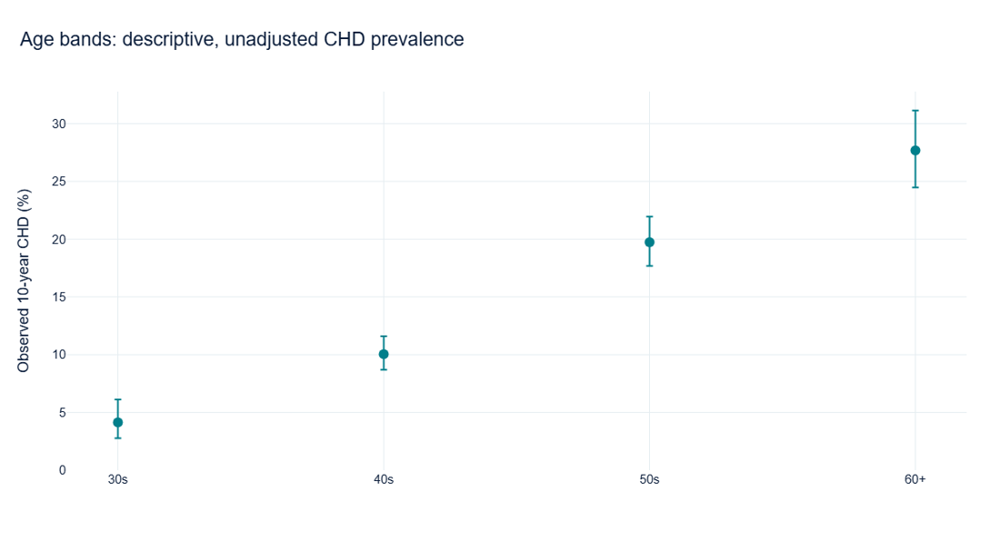

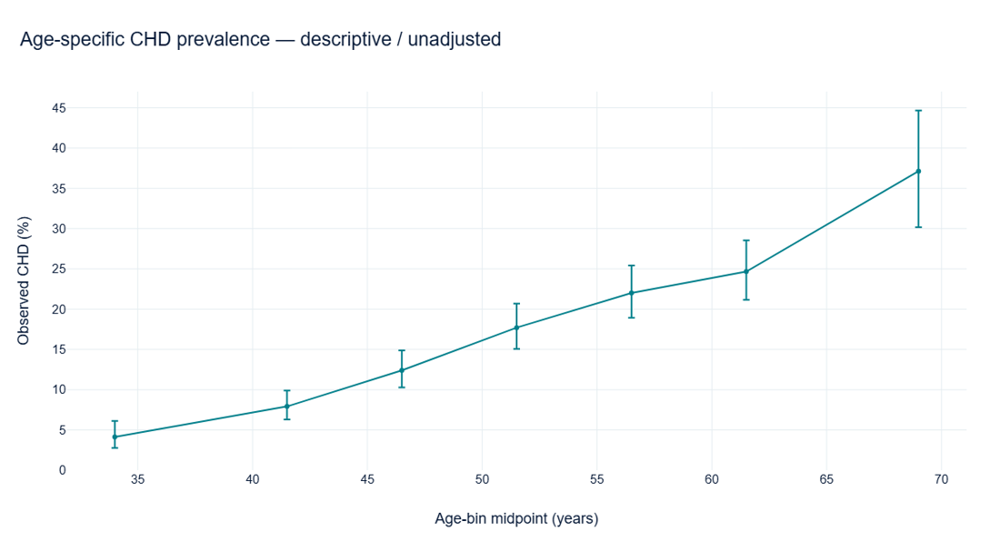

In [20]:

d=humanize(df_eda)
show(px.histogram(d,x='age',color='10-year CHD',color_discrete_map=OUTCOME_COLORS,barmode='overlay',
 histnorm='probability density',opacity=.55),'age_density','Age distributions by recorded outcome')
age_bands=plot_observed_risk(df_eda,'age_band','Age bands: descriptive, unadjusted CHD prevalence')
age_curve_data=df_eda.assign(age_bin=pd.cut(df_eda.age,bins=[29,39,44,49,54,59,64,74]))
age_curve=prevalence_table(age_curve_data,'age_bin');age_curve['midpoint']=age_curve.age_bin.map(lambda x:x.mid).astype(float)
f=go.Figure(go.Scatter(x=age_curve.midpoint,y=100*age_curve.prevalence,mode='lines+markers',line={'color':TEAL},
 error_y={'type':'data','array':100*(age_curve.upper-age_curve.prevalence),'arrayminus':100*(age_curve.prevalence-age_curve.lower)},
 customdata=age_curve[['group','n','cases']].values,
 hovertemplate='Age interval: %{customdata[0]}<br>N=%{customdata[1]}<br>CHD cases=%{customdata[2]}<br>Observed=%{y:.1f}%<extra></extra>'))
f.update_xaxes(title='Age-bin midpoint (years)');f.update_yaxes(title='Observed CHD (%)',rangemode='tozero')
show(f,'age_curve','Age-specific CHD prevalence — descriptive / unadjusted')
age_curve.to_csv(VIS/'age_curve.csv',index=False);


### What to look for

Compare prevalence, group size and Wilson interval width. The youngest and oldest age bins are wider to avoid unstable estimates at sparsely populated edges. Lines connect bin summaries to guide the eye.

### What this does NOT tell us

The curve is a descriptive comparison across age groups, not a within-person trajectory, causal effect or adjusted model.

## Three variables, then a fourth

All eligible points are retained. Hover reveals recorded values without names or participant identifiers.

⭐ **BEGINNER CORE:** read the two-variable scatter plots first. The fourth-variable bubble view is labeled optional below.

**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Place records by pairs of measurements.

**WHY ARE WE DOING IT?** Scatter plots reveal overlap and relationships hidden by separate summaries.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** Age/BP, age/glucose and BMI/BP scatter plots; an additional bubble view uses visual-only glucose sizing.

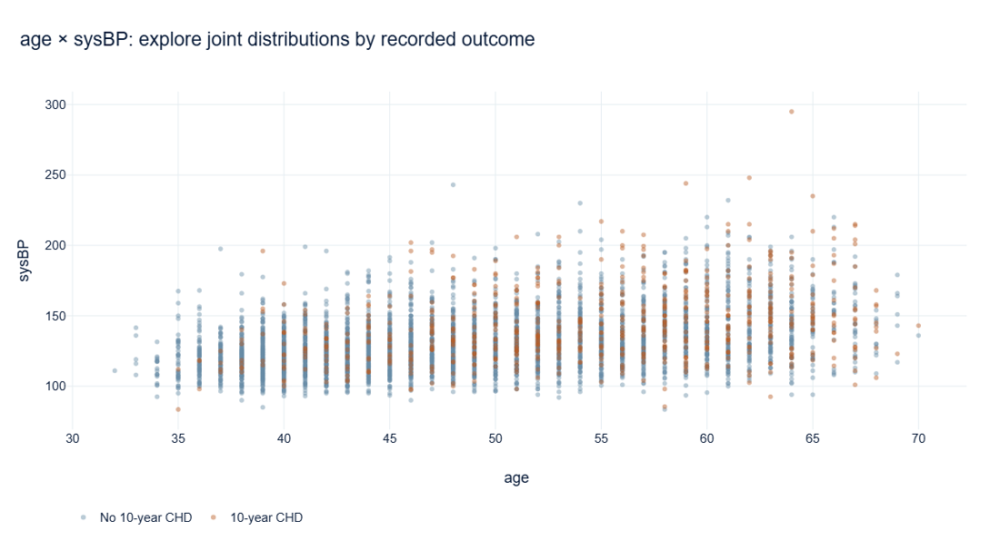

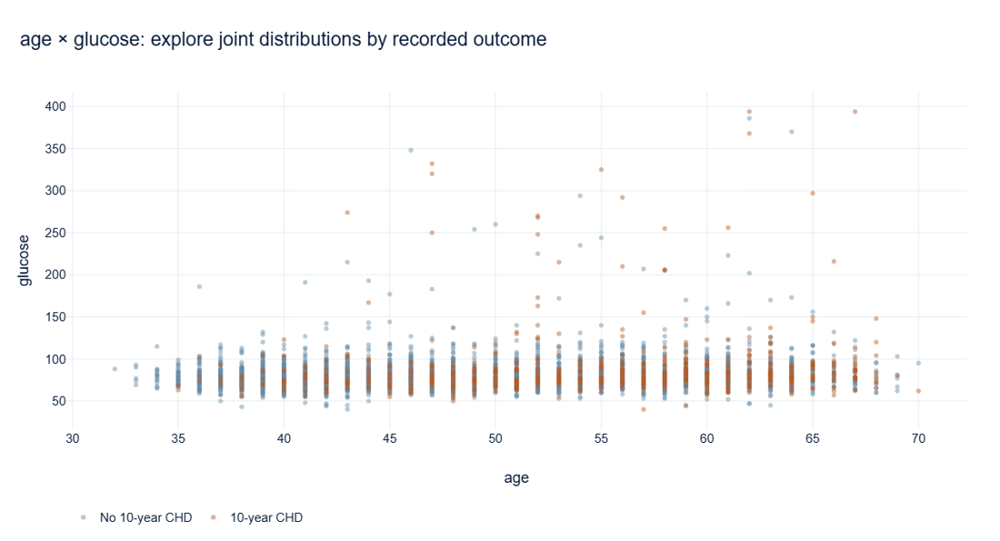

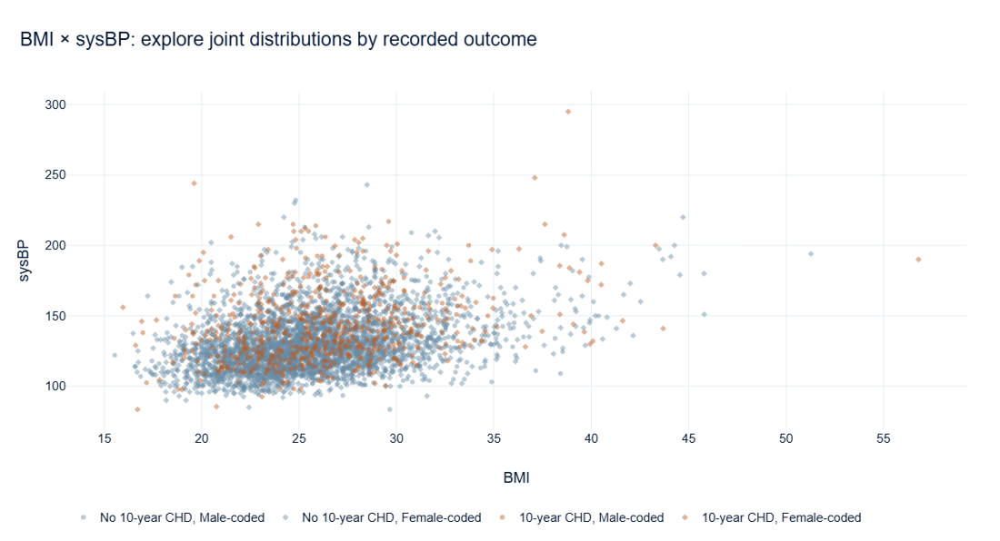

Bubble area input uses sqrt(glucose), capped at the observed 95th percentile (108.45); original glucose is unchanged.


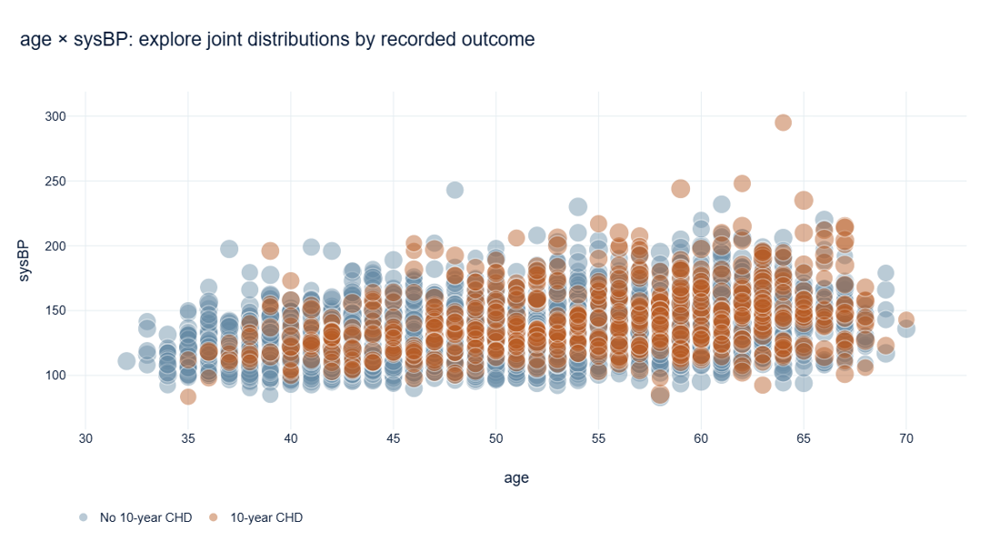

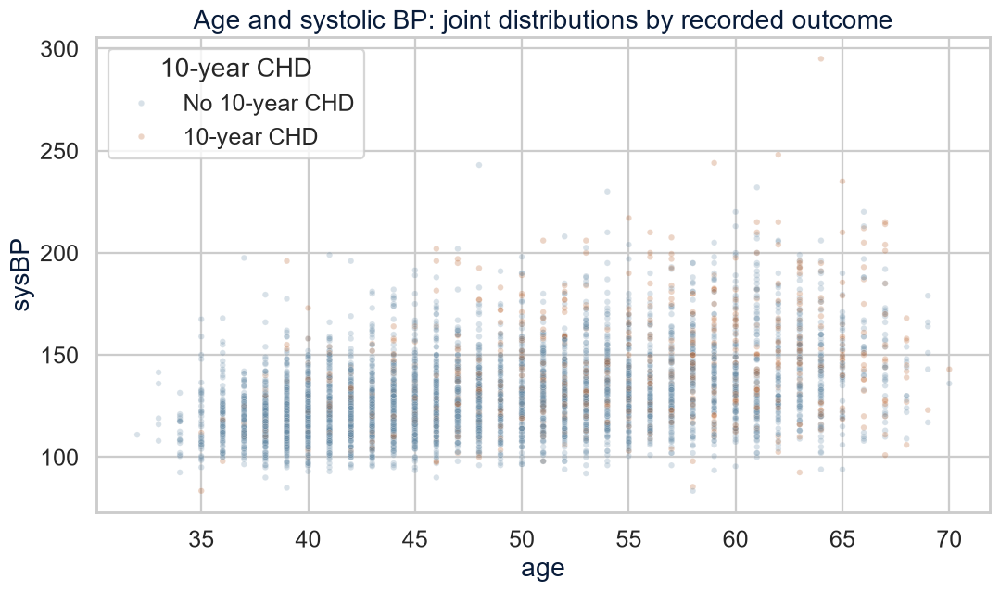

In [21]:

plot_scatter_outcome(df_eda,'age','sysBP','age_sbp_outcome')
plot_scatter_outcome(df_eda,'age','glucose','age_glucose_outcome')
plot_scatter_outcome(df_eda,'BMI','sysBP','bmi_sbp_outcome',symbol='Sex')
display(HTML('<p><strong>🔬 OPTIONAL ADVANCED EDA — fourth-variable bubble view</strong>: you may ignore this extra chart and continue with the two-variable scatter plots.</p>'))
bubble=df_eda.dropna(subset=['age','sysBP','glucose']).copy()
cap=bubble.glucose.quantile(.95);bubble['Glucose display size']=np.sqrt(bubble.glucose.clip(upper=cap).clip(lower=0))
print(f'Bubble area input uses sqrt(glucose), capped at the observed 95th percentile ({cap:.2f}); original glucose is unchanged.')
plot_scatter_outcome(bubble,'age','sysBP','bubble_glucose',size='Glucose display size',size_max=24)
fig,ax=plt.subplots(figsize=(10,6));d=humanize(df_eda)
sns.scatterplot(data=d,x='age',y='sysBP',hue='10-year CHD',palette=OUTCOME_COLORS,alpha=.25,s=18,ax=ax)
ax.set(title='Age and systolic BP: joint distributions by recorded outcome');finish_static(fig,'04_age_sbp_outcome_scatter');


### TRY IT YOURSELF — compare two measurements

Change **only** the quoted values on the `X_VARIABLE` and `Y_VARIABLE` lines. Allowed choices: `age`, `sysBP`, `diaBP`, `glucose`, `BMI`, `totChol`, `heartRate`, `cigsPerDay`, `pulse_pressure`, `mean_arterial_pressure`. Click ▶ below. Points with missing selected inputs are omitted only from this display; the data and model are unchanged. Hover over points and use the legend to compare outcome groups.

**What this does NOT tell us:** a visible relationship is not a causal effect or an externally validated prediction.

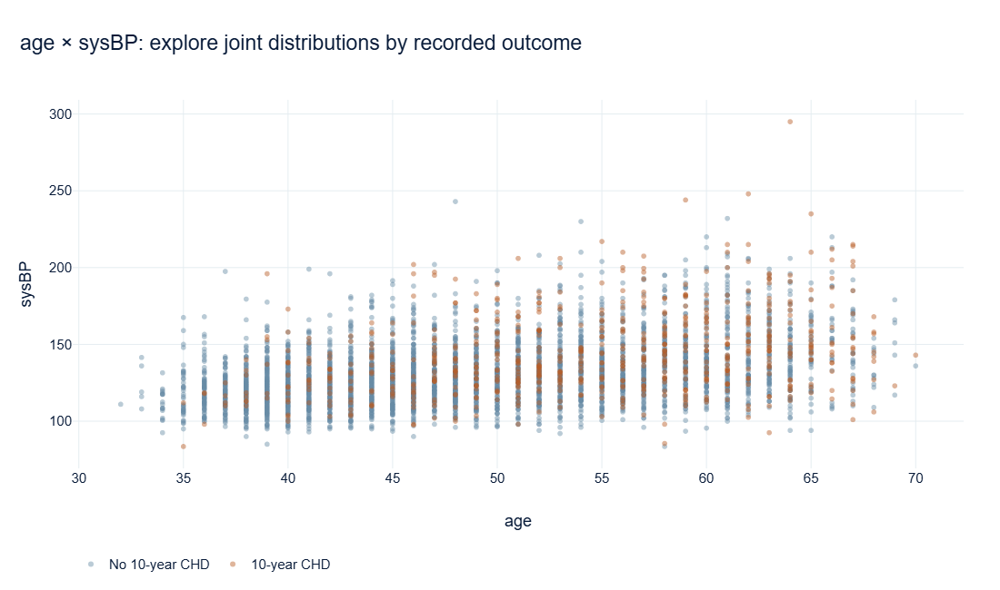

In [22]:
X_VARIABLE = "age"  # TRY IT: change only this quoted value.
Y_VARIABLE = "sysBP"  # TRY IT: change only this quoted value.
if X_VARIABLE in variables and Y_VARIABLE in variables:
    plot_scatter_outcome(df_eda, X_VARIABLE, Y_VARIABLE, "try_it_scatter")
else:
    print("Choose both variables from:", ", ".join(variables))


### What to look for

Zoom into overlapping regions and compare outcome groups. Bubble scaling changes visual emphasis only.

### What this does NOT tell us

Point clusters do not quantify independent effects. Missing glucose excludes points from the glucose and bubble views, not from the full-cohort summaries.

## Three-dimensional cardiovascular risk landscape

Rotate this optional view to see overlapping participant profiles.

🔬 **OPTIONAL ADVANCED EDA:** this additional view can be skipped without losing the main lesson or affecting the model.

**🔬 OPTIONAL ADVANCED EDA**

**WHAT ARE WE DOING?** Rotate a three-dimensional view of age, BP and glucose.

**WHY ARE WE DOING IT?** An optional extra dimension can reveal patterns but can also hide points.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** A rotatable 3D scatter plot; you can skip this cell in the learning route.

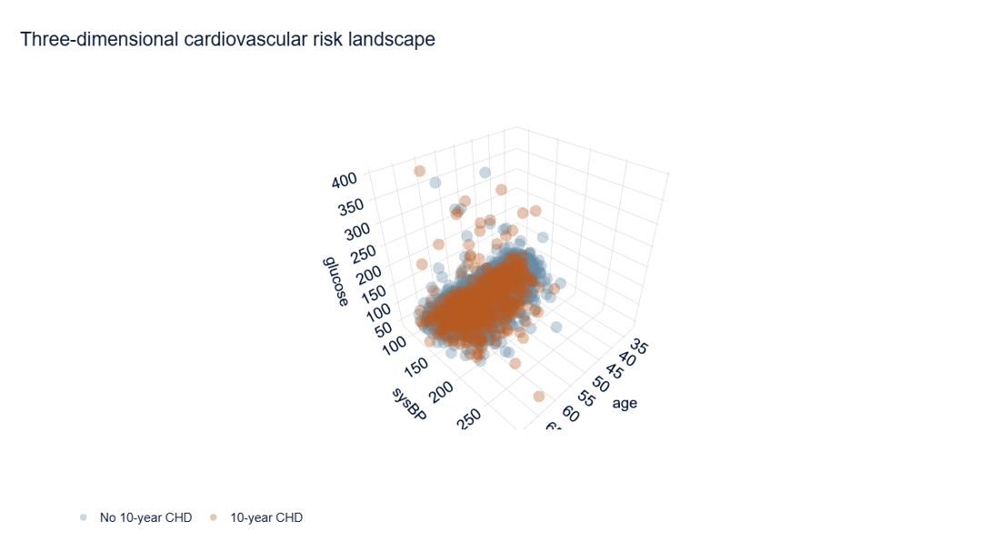

In [23]:

d=humanize(df_eda.dropna(subset=['age','sysBP','glucose']))
show(px.scatter_3d(d,x='age',y='sysBP',z='glucose',color='10-year CHD',color_discrete_map=OUTCOME_COLORS,
 opacity=.35,hover_data=['BMI','Current smoker']),'risk_3d','Three-dimensional cardiovascular risk landscape');


### What to look for

Rotation can reveal overlap obscured by one viewpoint.

### What this does NOT tell us

3D plots can be visually engaging but are often harder to interpret quantitatively than 2D plots. Use this as an exploratory visualization, not as evidence of independent effects.

## Feature engineering: make the construct visible

Pulse pressure = SBP − DBP. Mean arterial pressure approximation = DBP + (SBP − DBP)/3. The approximation is a derived measure, not a directly observed measurement.

**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Explore engineered BP measures and smoking categories.

**WHY ARE WE DOING IT?** These views connect new variables to their original meaning.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** Distributions, category summaries and a readable twenty-record table; raw values remain available.

,pulse_pressure
observed_n,"4,240.000"
missing_n,0.000
median,47.000
minimum,15.000
maximum,160.000
IQR_flags,168.000


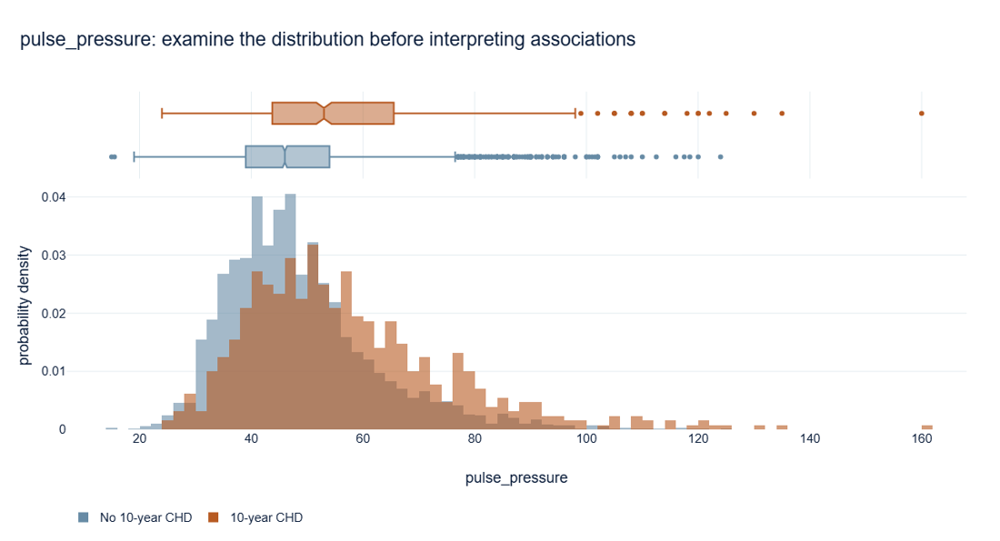

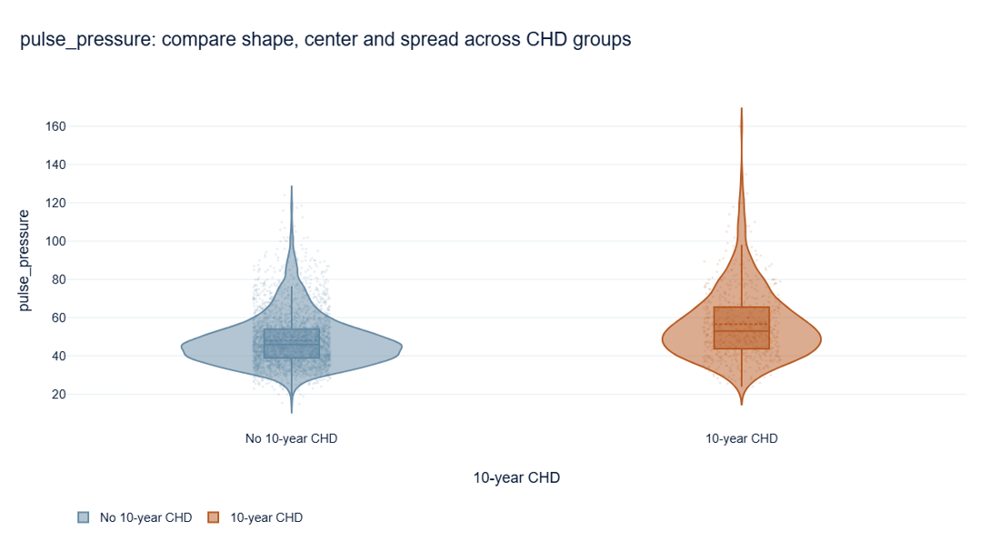

,mean_arterial_pressure
observed_n,"4,240.000"
missing_n,0.000
median,97.333
minimum,62.500
maximum,188.333
IQR_flags,110.000


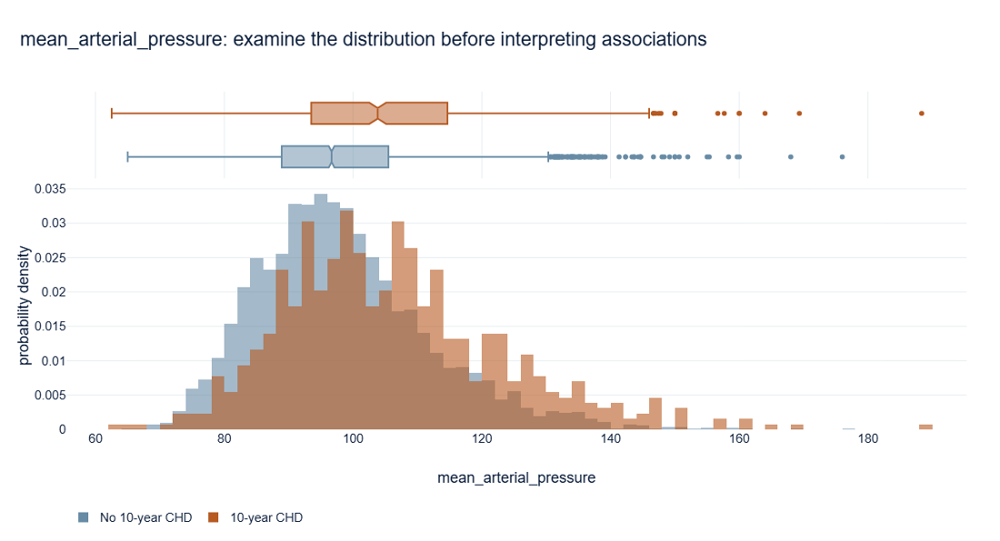

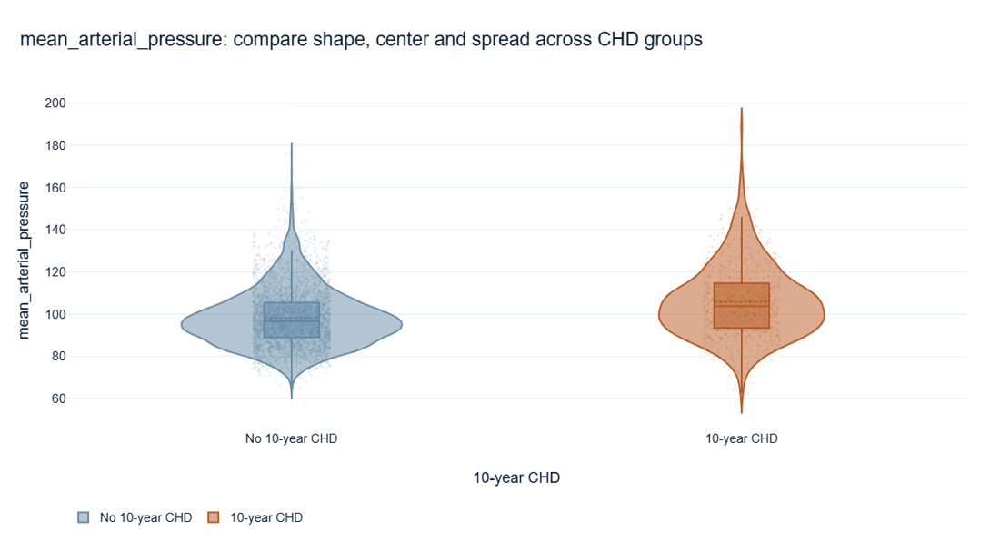

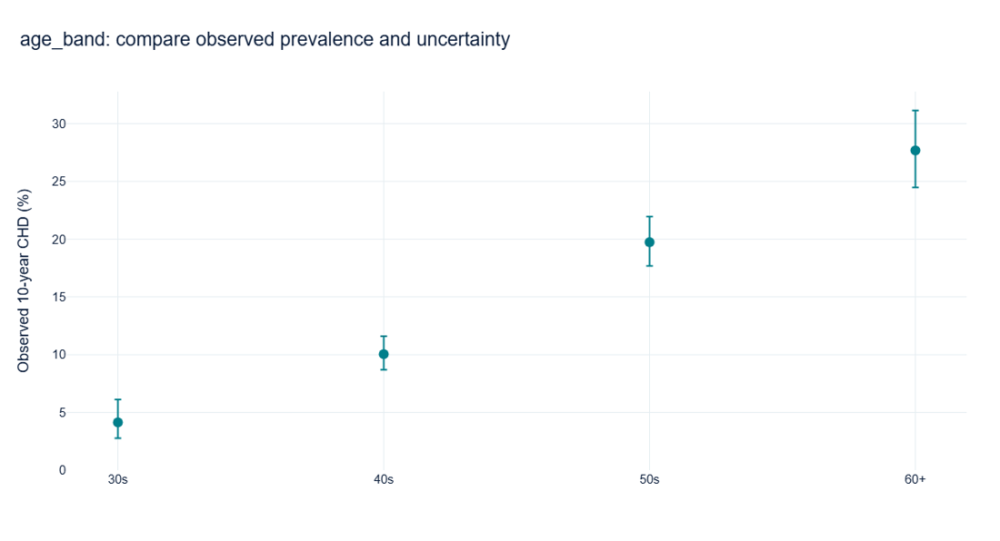

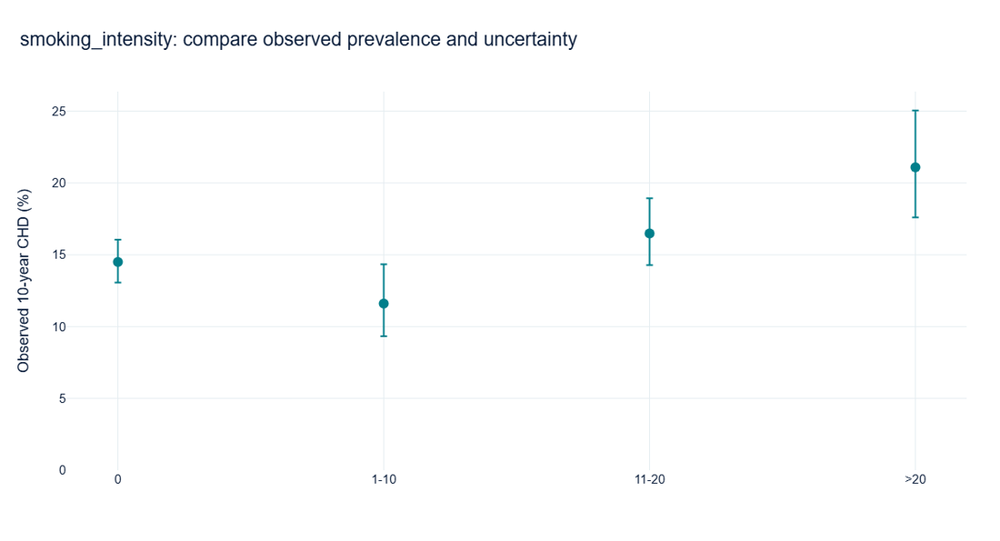

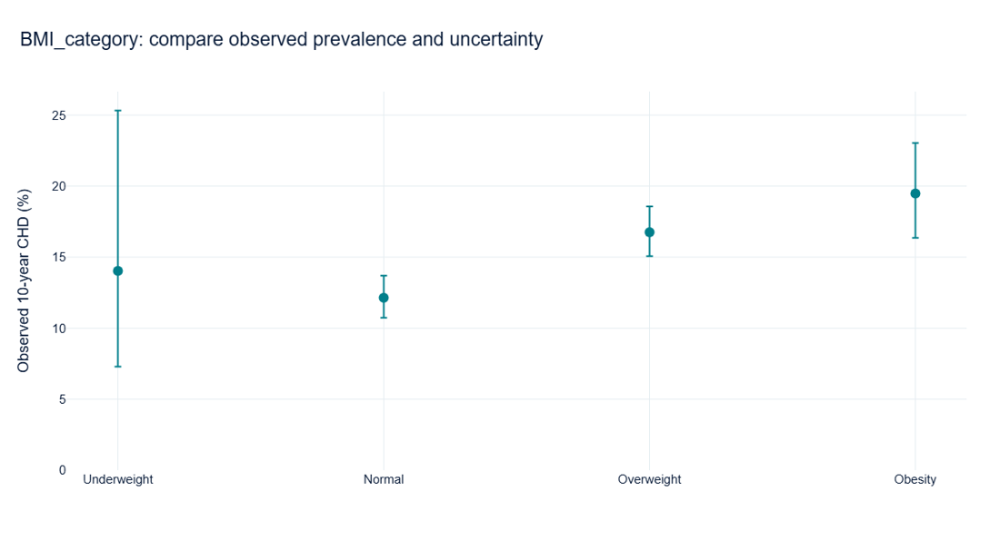

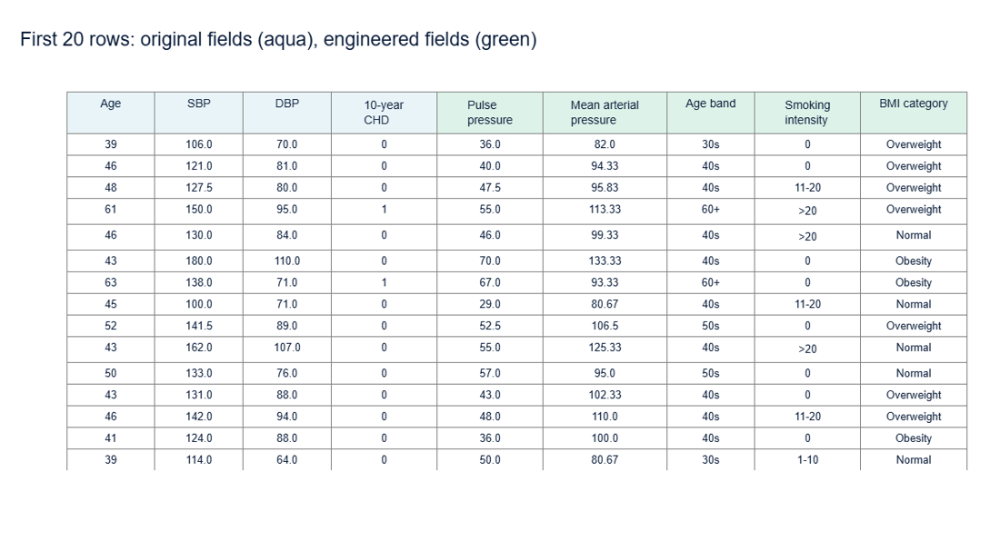

In [24]:

for col in ['pulse_pressure','mean_arterial_pressure']:explore_variable(col);plot_distribution_by_outcome(df_eda,col)
for col in ['age_band','smoking_intensity','BMI_category']:plot_observed_risk(df_eda,col)
preview_cols=['age','sysBP','diaBP','TenYearCHD','pulse_pressure','mean_arterial_pressure','age_band','smoking_intensity','BMI_category']
preview=df_eda[preview_cols].head(20).round(2).astype(str)
headers=['Age','SBP','DBP','10-year<br>CHD','Pulse<br>pressure','Mean arterial<br>pressure','Age band','Smoking<br>intensity','BMI category']
f=go.Figure(go.Table(columnwidth=[1,1,1,1.2,1.2,1.4,1,1.2,1.2],
 header={'values':headers,'fill_color':[AQUA]*4+['#DDF2E8']*5,'height':42,'font':{'size':14}},
 cells={'values':[preview[c] for c in preview_cols],'height':26,'font':{'size':13}}))
show(f,'data_preview','First 20 rows: original fields (aqua), engineered fields (green)');


### What to look for

Compare derived distributions and category denominators. Modify head(20) to inspect another window; zoom/hover on charts provide detailed value inspection.

### What this does NOT tell us

Exploratory category cut points do not prove clinical thresholds. Missing smoking intensity remains missing, and ordinal education codes retain their documented numerical labels.

## Age × SBP: a descriptive prevalence surface

Each cell aggregates outcomes within an age/BP combination. Cells with N < 30 are masked; denominators and cases are exported for audit.

**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Compare observed prevalence within age and BP ranges.

**WHY ARE WE DOING IT?** A colored cell needs its sample size before its proportion is interpreted.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** An age-by-SBP heatmap; cells with fewer than 30 records are masked, and hover reports N and cases for populated cells.

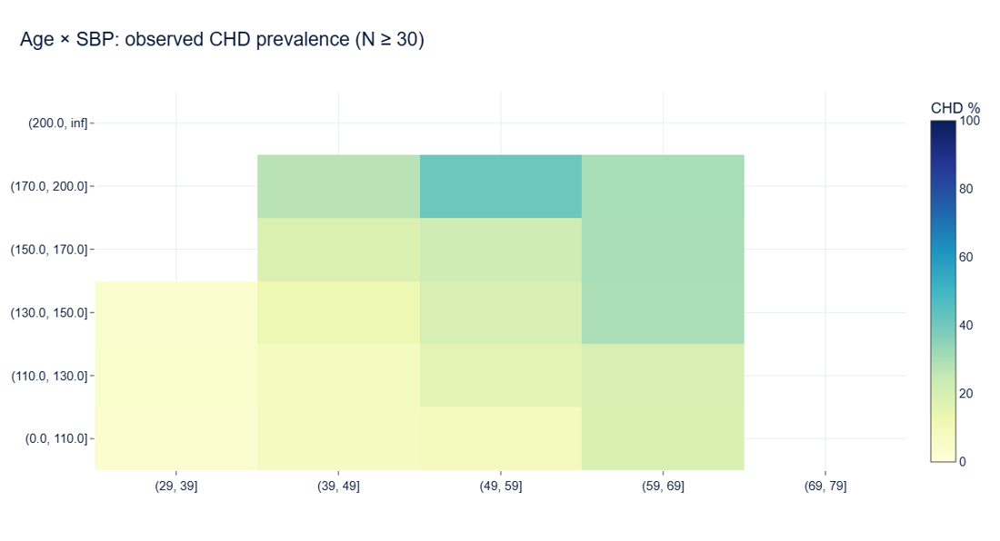

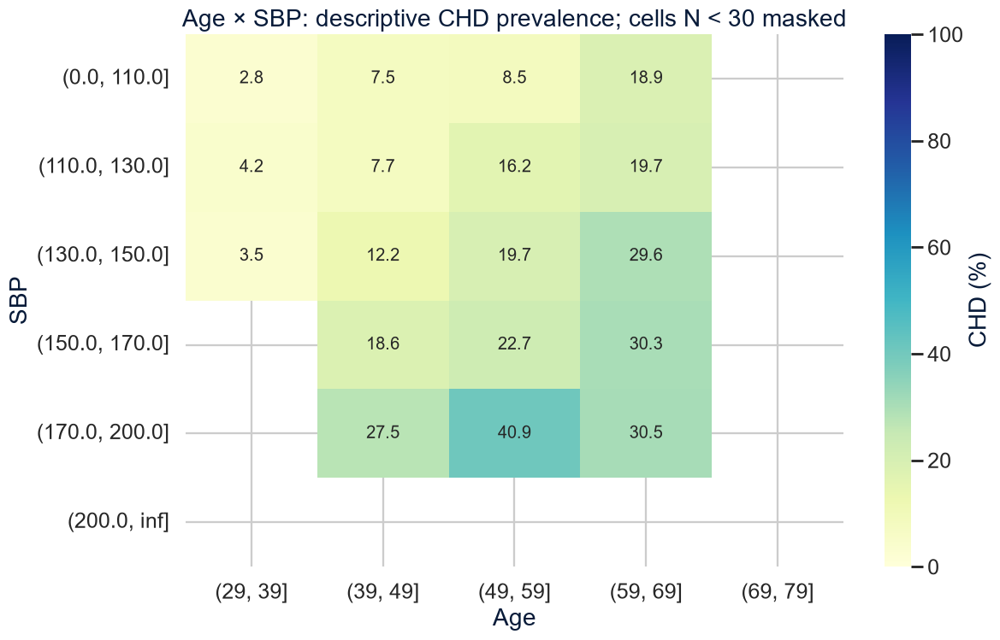

In [25]:

surface=df_eda.assign(Age=pd.cut(df_eda.age,[29,39,49,59,69,79]),SBP=pd.cut(df_eda.sysBP,[0,110,130,150,170,200,np.inf]))
surface_table=surface.groupby(['SBP','Age'],observed=False).TenYearCHD.agg(n='size',cases='sum').reset_index()
surface_table['prevalence']=surface_table.cases/surface_table.n.replace(0,np.nan)
ns=surface_table.pivot(index='SBP',columns='Age',values='n');cs=surface_table.pivot(index='SBP',columns='Age',values='cases')
rates=100*surface_table.pivot(index='SBP',columns='Age',values='prevalence');masked=rates.where(ns>=30)
f=go.Figure(go.Heatmap(z=masked.values,x=masked.columns.astype(str),y=masked.index.astype(str),
 colorscale='YlGnBu',zmin=0,zmax=100,customdata=np.stack([ns.values,cs.values],axis=-1),
 colorbar={'title':'CHD %'},hovertemplate='Age: %{x}<br>SBP: %{y}<br>N=%{customdata[0]}<br>Cases=%{customdata[1]}<br>Observed=%{z:.1f}%<extra></extra>'))
show(f,'age_sbp_surface','Age × SBP: observed CHD prevalence (N ≥ 30)')
fig,ax=plt.subplots(figsize=(11,7));sns.heatmap(masked,annot=True,fmt='.1f',vmin=0,vmax=100,cmap='YlGnBu',ax=ax,cbar_kws={'label':'CHD (%)'})
ax.set(title='Age × SBP: descriptive CHD prevalence; cells N < 30 masked');finish_static(fig,'05_age_sbp_risk_surface')
surface_table['masked_n_lt_30']=surface_table.n<30;surface_table.to_csv(VIS/'age_sbp_surface.csv',index=False);


### What to look for

Compare populated bins while noting that every cell averages over other characteristics.

### What this does NOT tell us

This is an unadjusted binned map, not an estimated continuous risk surface or evidence of an age–BP interaction. Blank cells indicate small or empty groups, not zero risk.

## Selected facets: inspect composition before adjustment

Use a small set of clinically meaningful combinations.

**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Compare selected groups side by side.

**WHY ARE WE DOING IT?** Sex, smoking and diabetes groups can have different composition.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** Faceted views; these are descriptive comparisons before adjustment.

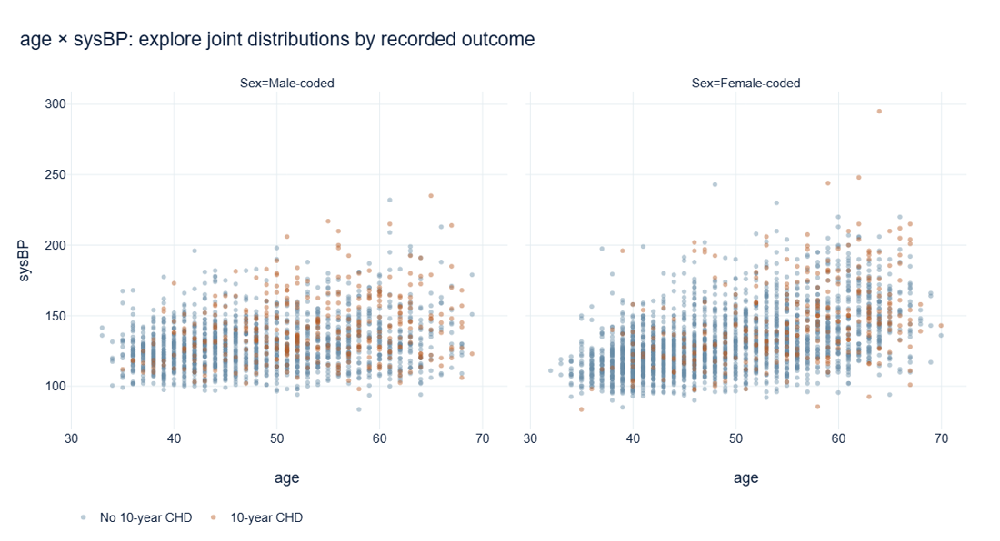

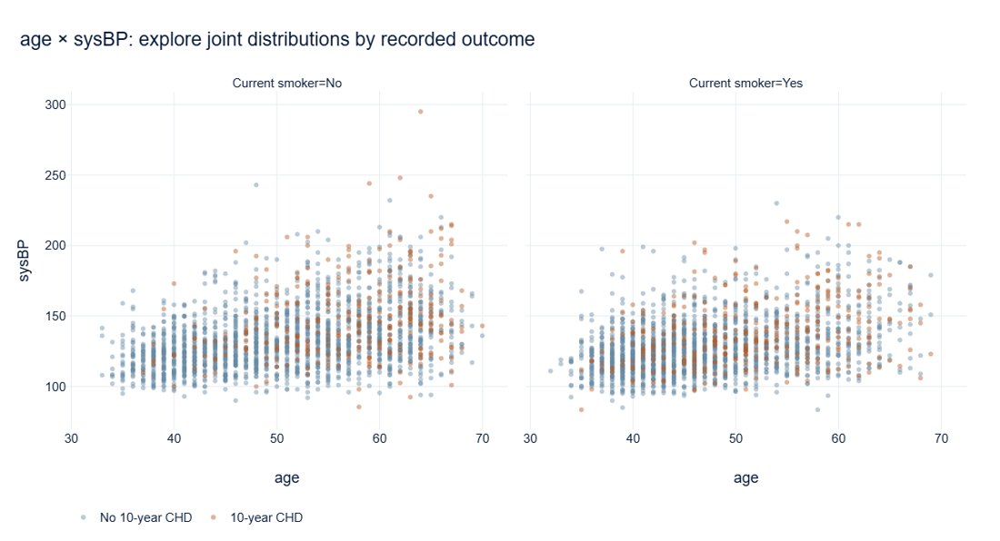

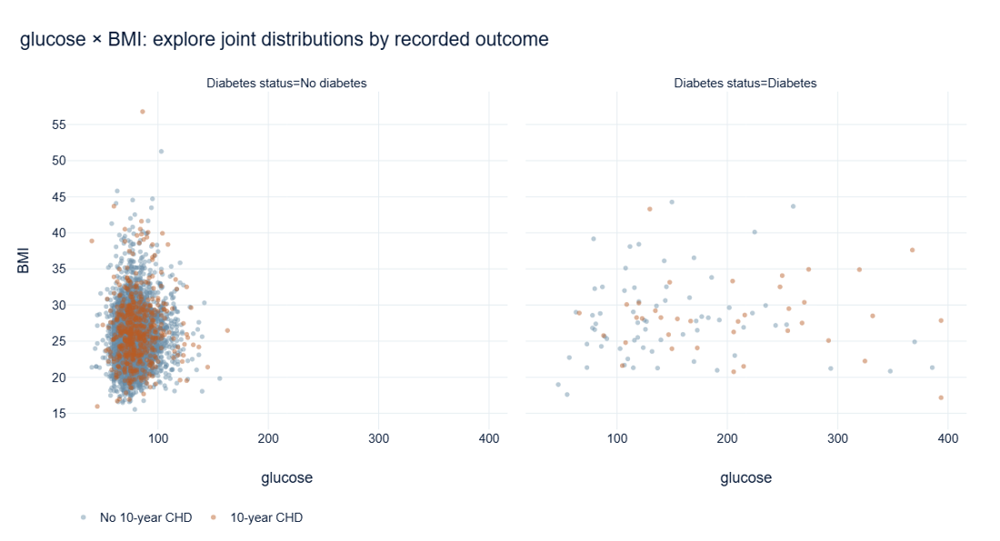

In [26]:

plot_scatter_outcome(df_eda,'age','sysBP','facet_sex',facet_col='Sex')
plot_scatter_outcome(df_eda,'age','sysBP','facet_smoking',facet_col='Current smoker')
d=df_eda.copy();d['Diabetes status']=d.diabetes.map({0:'No diabetes',1:'Diabetes'})
plot_scatter_outcome(d,'glucose','BMI','facet_diabetes',facet_col='Diabetes status');


### What to look for

Compare distributions within the displayed strata using shared scales.

### What this does NOT tell us

Faceting controls only the displayed grouping; it does not adjust for other characteristics or establish causality.

## STEP 7 — CONNECT

**Step 7 of 9 · ⭐ BEGINNER CORE**

EDA also tells us whether predictors are carrying overlapping information.

Examples worth checking in this dataset include:

- current smoking status vs cigarettes per day
- systolic vs diastolic BP
- systolic BP vs prevalent hypertension
- glucose vs diabetes

High correlation does not automatically mean one variable must be removed, but it should trigger scientific and statistical review before model specification.


**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Calculate pairwise numerical correlations.

**WHY ARE WE DOING IT?** Related predictors may carry overlapping information.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** A correlation table; correlation guides review, not automatic removal or causal claims.

In [27]:
corr_vars = [
    "currentSmoker", "cigsPerDay", "sysBP", "diaBP",
    "prevalentHyp", "glucose", "diabetes", "age",
    "totChol", "BMI", "heartRate"
]

corr = df_eda[corr_vars].corr()
corr.round(2)


,currentSmoker,cigsPerDay,sysBP,diaBP,prevalentHyp,glucose,diabetes,age,totChol,BMI,heartRate
currentSmoker,1.000,0.770,-0.130,-0.110,-0.100,-0.060,-0.040,-0.210,-0.050,-0.170,0.060
cigsPerDay,0.770,1.000,-0.090,-0.060,-0.070,-0.060,-0.040,-0.190,-0.030,-0.090,0.080
sysBP,-0.130,-0.090,1.000,0.780,0.700,0.140,0.110,0.390,0.210,0.330,0.180
diaBP,-0.110,-0.060,0.780,1.000,0.620,0.060,0.050,0.210,0.160,0.380,0.180
prevalentHyp,-0.100,-0.070,0.700,0.620,1.000,0.090,0.080,0.310,0.160,0.300,0.150
glucose,-0.060,-0.060,0.140,0.060,0.090,1.000,0.620,0.120,0.050,0.090,0.090
diabetes,-0.040,-0.040,0.110,0.050,0.080,0.620,1.000,0.100,0.040,0.090,0.050
age,-0.210,-0.190,0.390,0.210,0.310,0.120,0.100,1.000,0.260,0.140,-0.010
totChol,-0.050,-0.030,0.210,0.160,0.160,0.050,0.040,0.260,1.000,0.120,0.090
BMI,-0.170,-0.090,0.330,0.380,0.300,0.090,0.090,0.140,0.120,1.000,0.070


## Predictor redundancy: examine overlapping information

Pearson coefficients are calculated using available pairs. A pairwise-N table accompanies the heatmaps.

**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Visualize correlations and their available sample sizes.

**WHY ARE WE DOING IT?** Missingness means different pairs can use different numbers of records.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** An annotated heatmap and an interactive heatmap; hover for correlation and pairwise N.

<runtime>/seaborn\matrix.py:243: PendingDeprecationWarning: The set_bad function will be deprecated in a future version. Use cmap.with_extremes(bad=...) or Colormap(bad=...) instead.
  self.cmap.set_bad(bad)


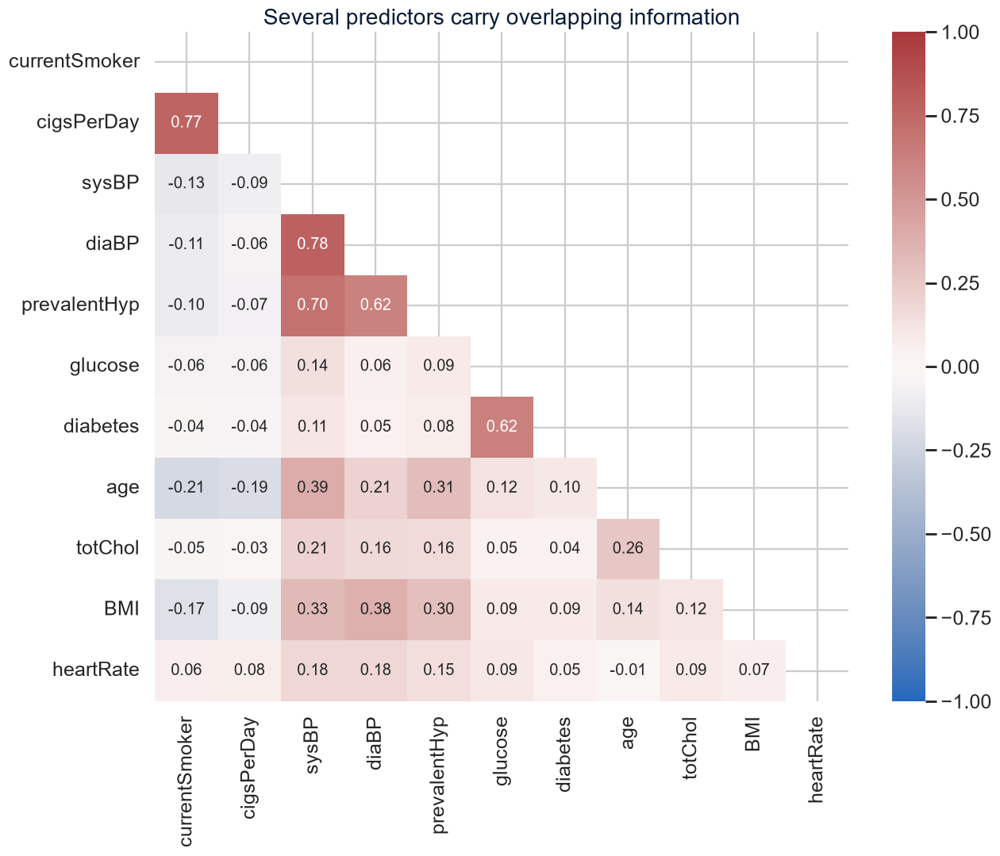

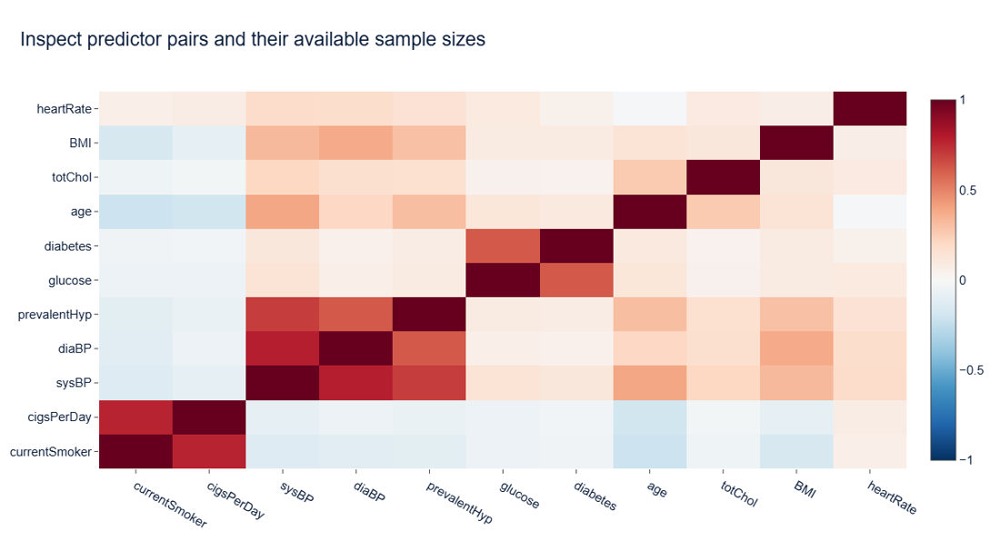

currentSmoker ↔ cigsPerDay: r=0.770; pairwise N=4211
sysBP ↔ diaBP: r=0.784; pairwise N=4240
sysBP ↔ prevalentHyp: r=0.697; pairwise N=4240
glucose ↔ diabetes: r=0.618; pairwise N=3852


In [28]:

mask=np.triu(np.ones_like(corr,dtype=bool))
fig,ax=plt.subplots(figsize=(12,10));sns.heatmap(corr,mask=mask,annot=True,fmt='.2f',cmap='vlag',vmin=-1,vmax=1,center=0,ax=ax)
ax.set_title('Several predictors carry overlapping information');finish_static(fig,'06_correlation_heatmap')
pair_n=df_eda[corr_vars].notna().astype(int).T.dot(df_eda[corr_vars].notna().astype(int))
show(go.Figure(go.Heatmap(z=corr.values,x=corr.columns,y=corr.index,colorscale='RdBu',reversescale=True,zmin=-1,zmax=1,
 customdata=pair_n.values,hovertemplate='%{x} × %{y}<br>r=%{z:.3f}<br>Pairwise N=%{customdata}<extra></extra>')),
 'correlation_interactive','Inspect predictor pairs and their available sample sizes')
for a,b in [('currentSmoker','cigsPerDay'),('sysBP','diaBP'),('sysBP','prevalentHyp'),('glucose','diabetes')]:print(f'{a} ↔ {b}: r={corr.loc[a,b]:.3f}; pairwise N={pair_n.loc[a,b]}')
pair_n.to_csv(VIS/'correlation_pairwise_n.csv');


### 🔬 OPTIONAL ADVANCED EDA — clustered correlation profiles

**WHAT ARE WE DOING?** Group variables with similar correlation profiles.

**WHY ARE WE DOING IT?** This optional view helps inspect overlapping information.

**WHAT SHOULD YOU CLICK?** Click ▶ below, or skip this cell and continue.

**WHAT SHOULD YOU EXPECT TO SEE?** A clustered correlation heatmap. Clustering does not choose model predictors or establish causation.

<runtime>/seaborn\matrix.py:243: PendingDeprecationWarning: The set_bad function will be deprecated in a future version. Use cmap.with_extremes(bad=...) or Colormap(bad=...) instead.
  self.cmap.set_bad(bad)


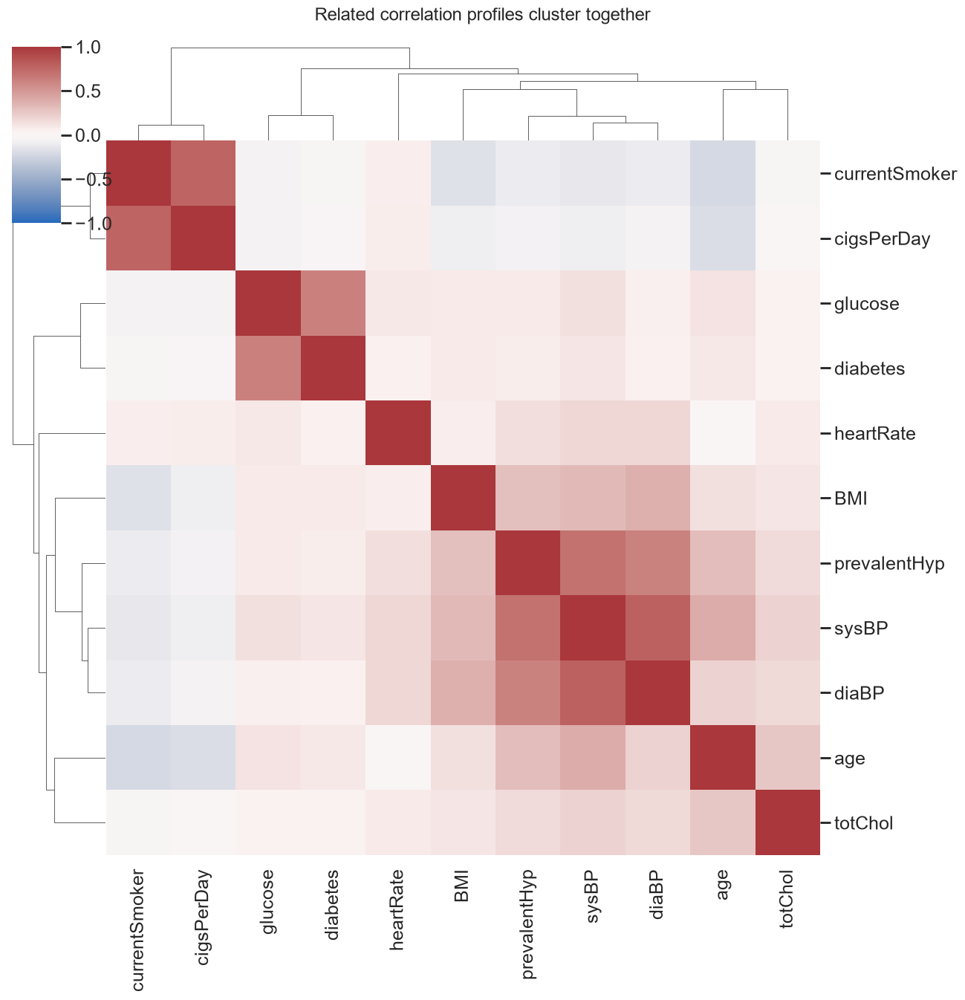

In [29]:
cluster=sns.clustermap(corr,cmap='vlag',vmin=-1,vmax=1,center=0,figsize=(12,12),dendrogram_ratio=.12)
cluster.fig.suptitle('Related correlation profiles cluster together',y=1.02);plt.show();plt.close(cluster.fig)


### What to look for

Hover over the named pairs and inspect groups in the clustered map. Hierarchical clustering uses Euclidean distance between correlation profiles.

### What this does NOT tell us

Correlation can reflect redundancy or shared constructs. It does not determine which predictor to remove; pairwise missingness may also make the correlation matrix differ from a complete-case one.

## Pairwise relationships: overview and interactive brushing

Use a curated predictor set; full eligible observations are retained with transparent points.

🔬 **OPTIONAL ADVANCED EDA:** this additional view can be skipped without losing the main lesson or affecting the model.

**🔬 OPTIONAL ADVANCED EDA**

**WHAT ARE WE DOING?** Survey several predictor pairs at once.

**WHY ARE WE DOING IT?** An optional overview can help experienced readers find relationships to investigate.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** A pairplot and interactive scatter matrix; skip this whole cell without changing the model.

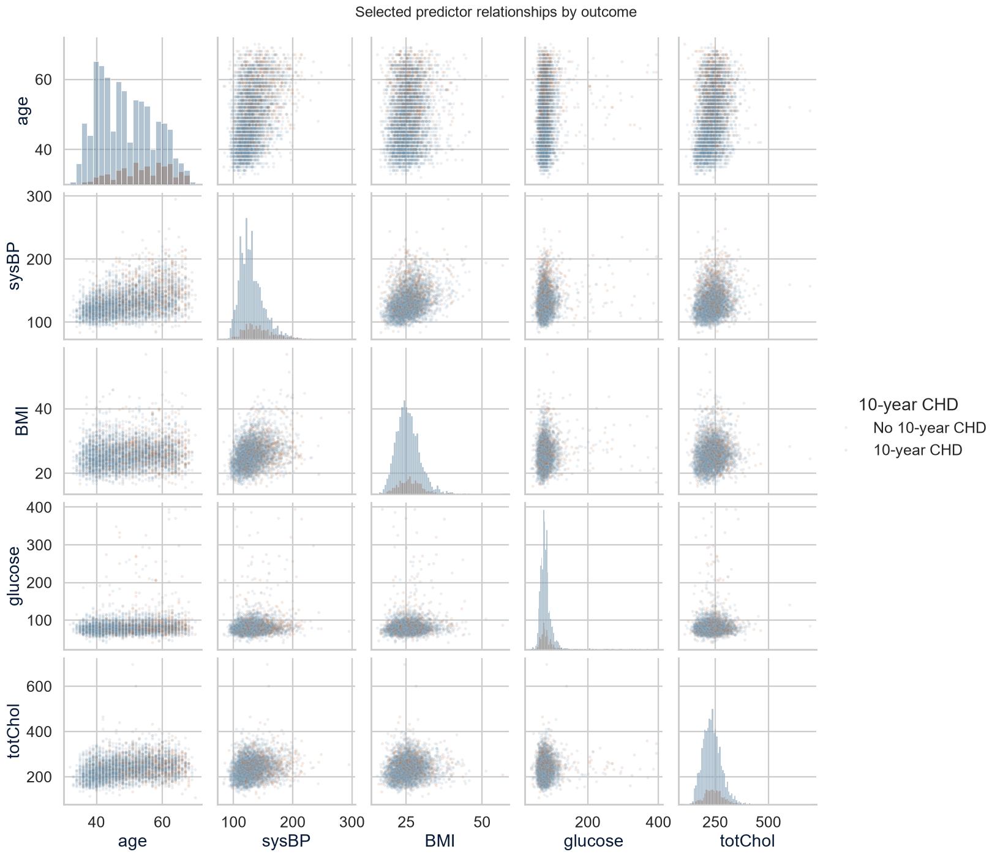

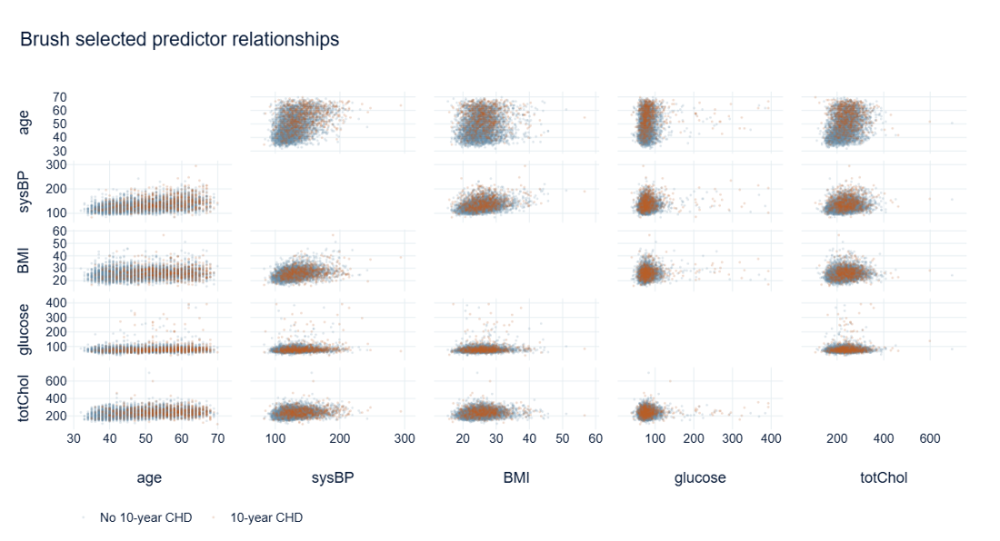

In [30]:

pair_columns=['age','sysBP','BMI','glucose','totChol']
d=humanize(df_eda)
g=sns.pairplot(d,vars=pair_columns,hue='10-year CHD',palette=OUTCOME_COLORS,diag_kind='hist',
 plot_kws={'alpha':.12,'s':10},diag_kws={'alpha':.5})
g.fig.suptitle('Selected predictor relationships by outcome',y=1.02);plt.show();plt.close(g.fig)
smatrix=px.scatter_matrix(d,dimensions=pair_columns,color='10-year CHD',color_discrete_map=OUTCOME_COLORS,
 hover_data=['Current smoker','Sex']);smatrix.update_traces(diagonal_visible=False,marker={'size':3,'opacity':.2})
show(smatrix,'scatter_matrix','Brush selected predictor relationships').update_layout(height=850);


### What to look for

Use lasso/box selection to identify linked regions and hover for values. The static matrix emphasizes overall shape; the interactive matrix supports selection.

### What this does NOT tell us

Missing values are omitted only where required by a displayed variable pair. Brushing identifies observations, not inferentially validated subgroups.

## Categorical comparisons: prevalence with denominators

Use within-group outcome prevalence and Wilson 95% intervals, not counts alone.

**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Compare observed prevalence across categories.

**WHY ARE WE DOING IT?** Group percentages need counts and uncertainty intervals.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** Category risk plots with sample sizes, cases and Wilson intervals; these are unadjusted comparisons.

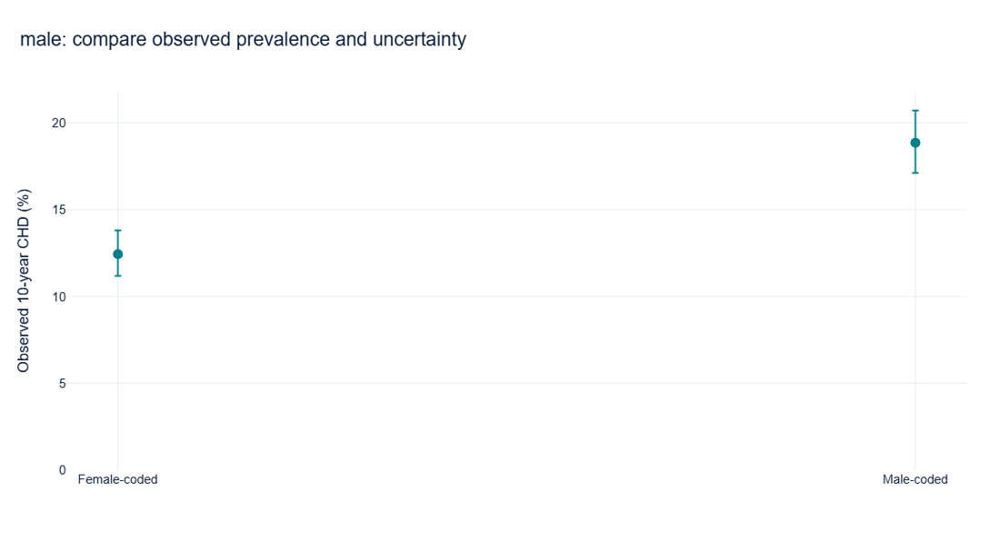

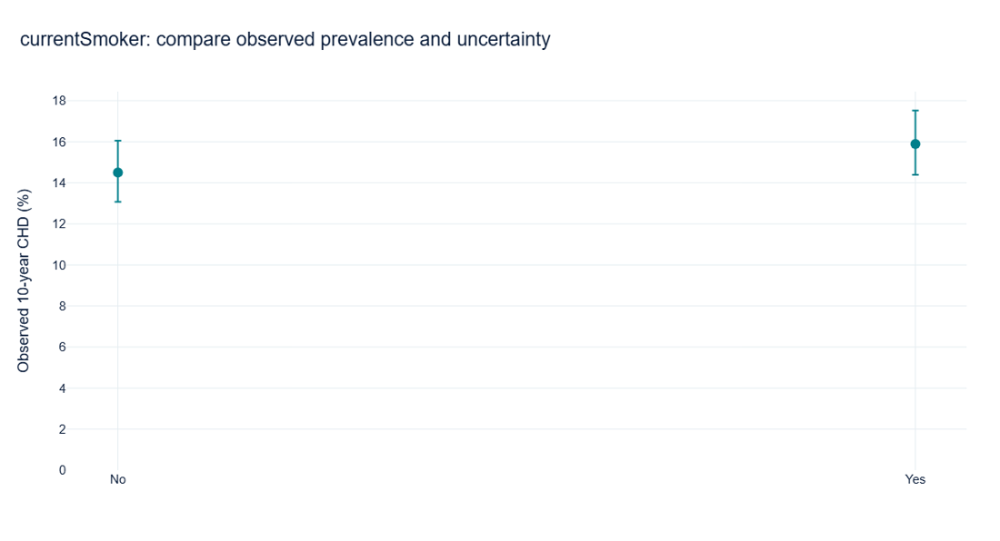

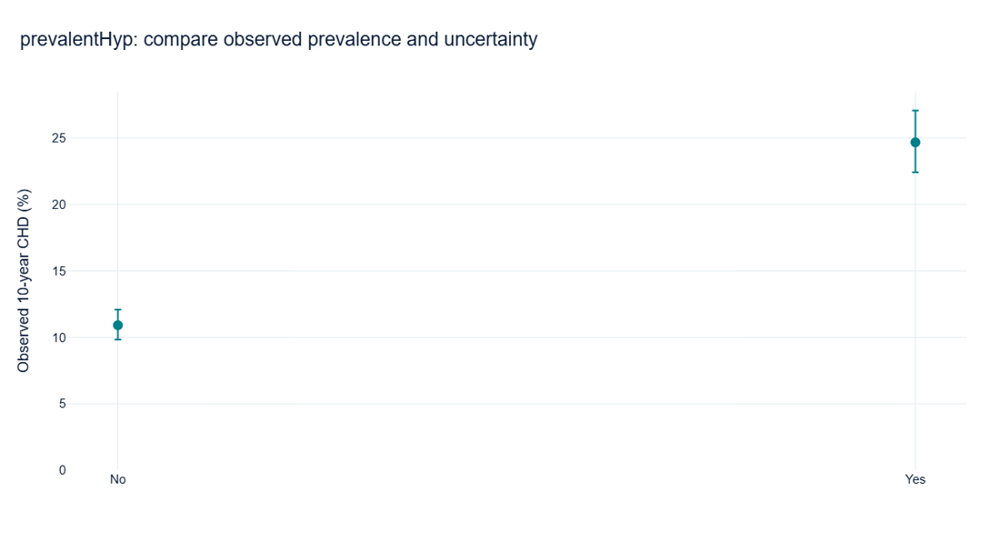

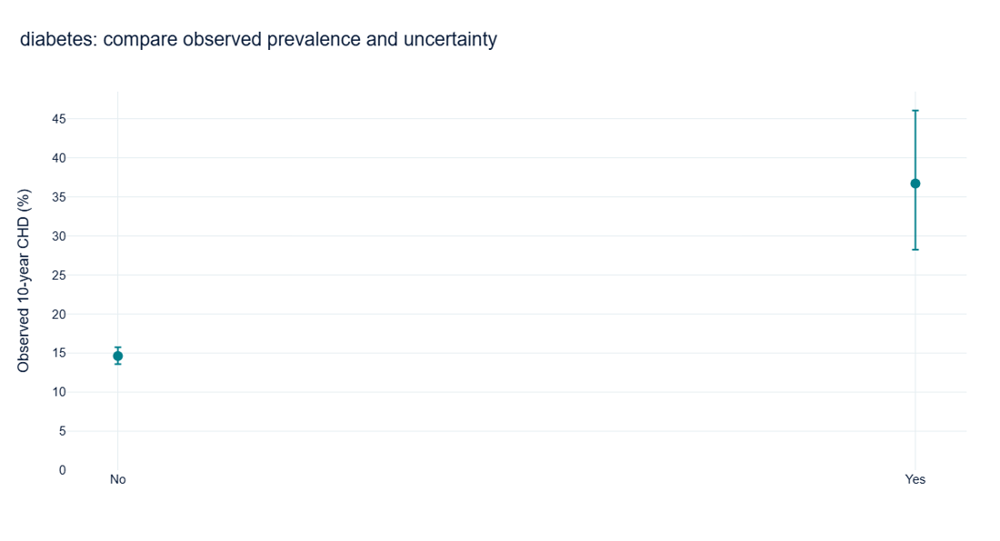

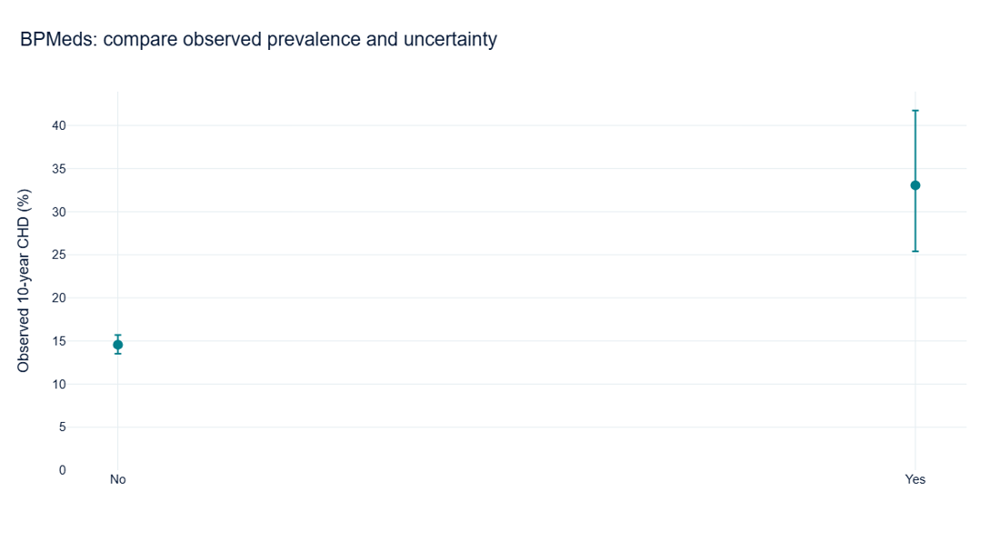

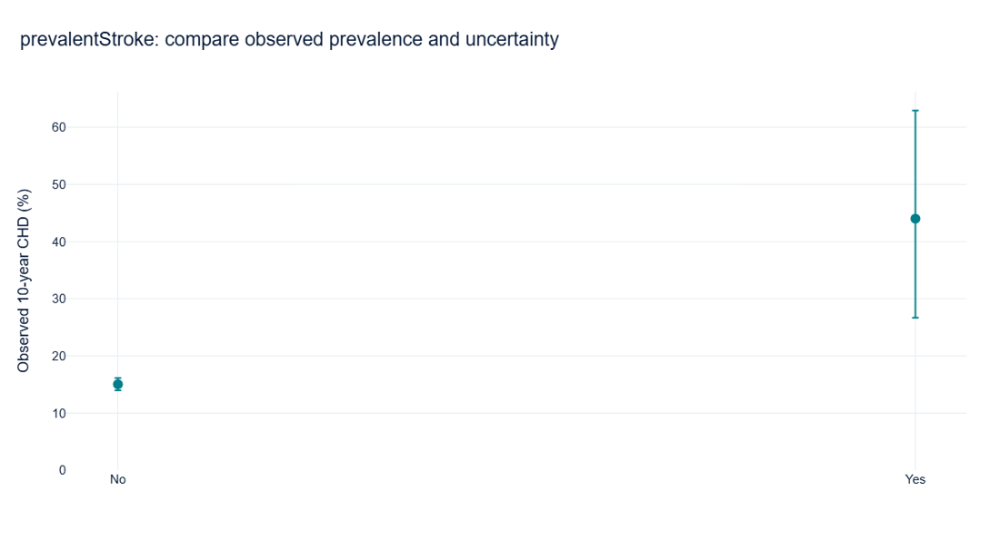

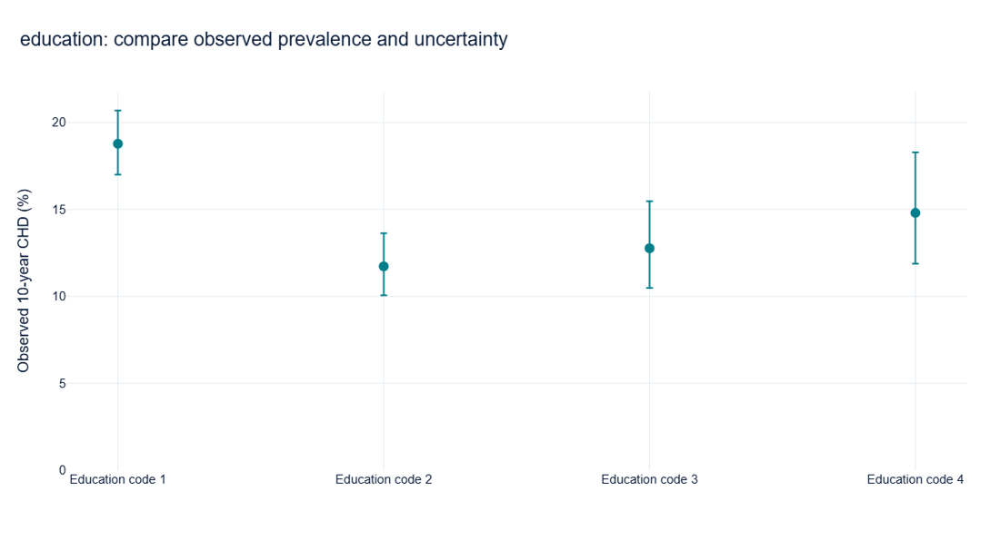

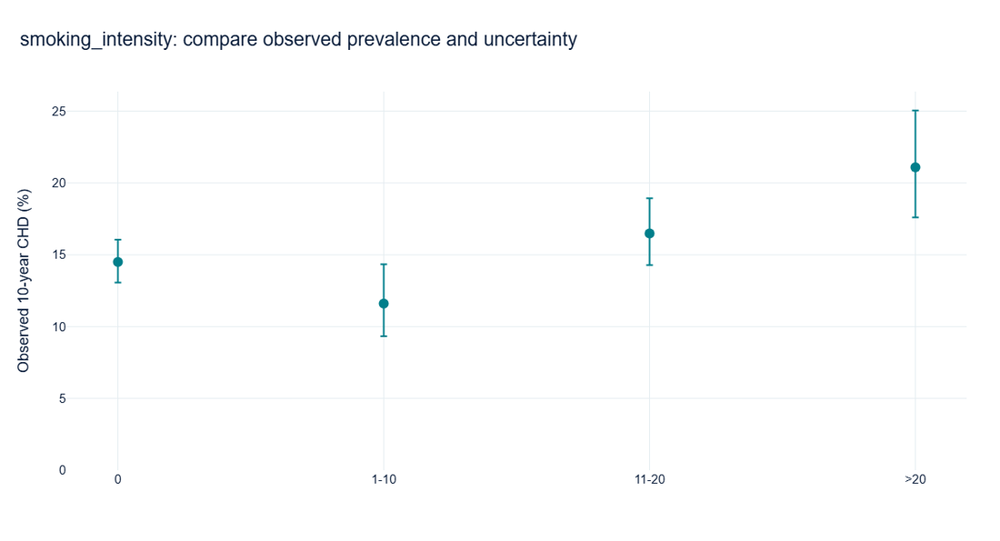

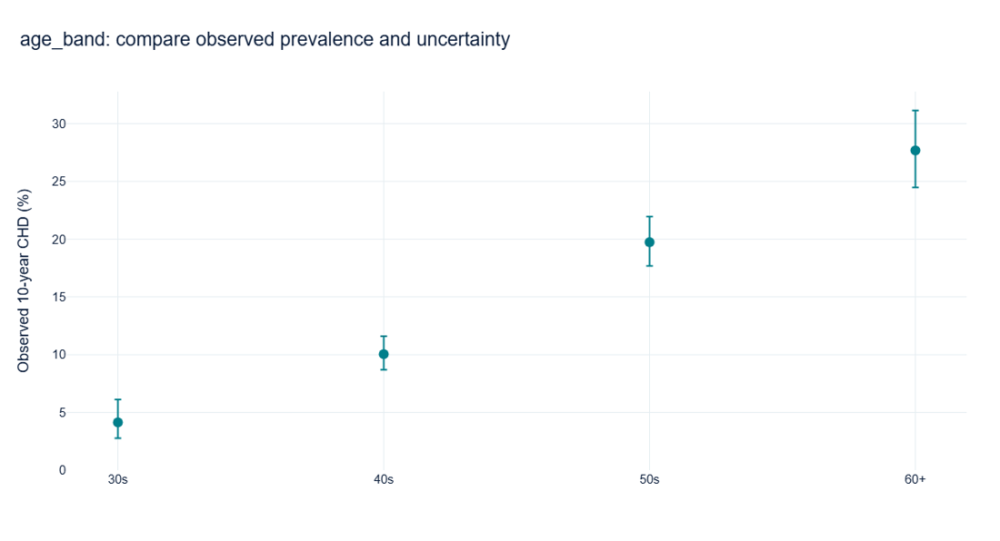

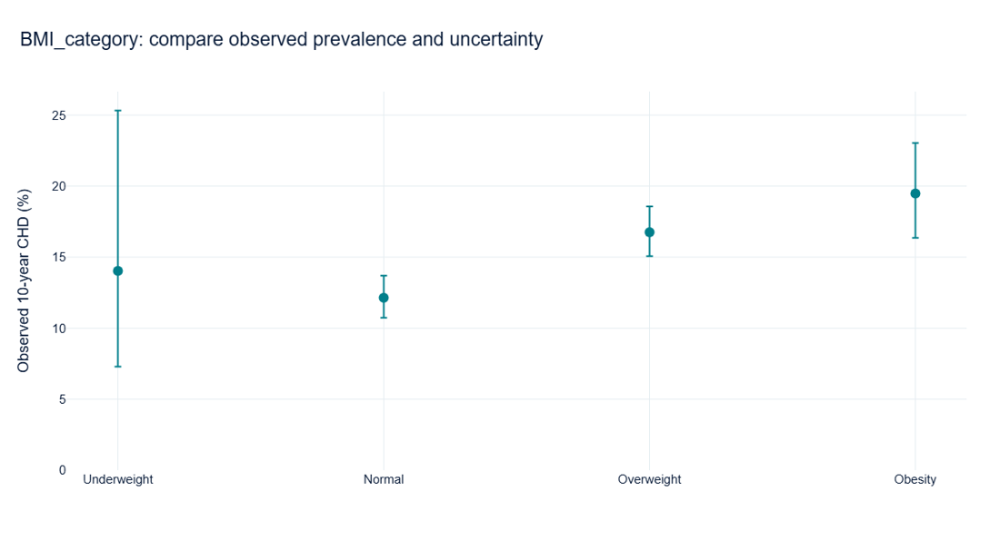

In [31]:

risk_exports=[]
for col in ['male','currentSmoker','prevalentHyp','diabetes','BPMeds','prevalentStroke','education','smoking_intensity','age_band','BMI_category']:
 t=plot_observed_risk(df_eda,col);t['variable']=col;risk_exports.append(t)
pd.concat(risk_exports,ignore_index=True).to_csv(VIS/'categorical_prevalence.csv',index=False);


### What to look for

Compare point estimates together with denominators and interval widths, especially rare stroke and medication groups.

### What this does NOT tell us

These are descriptive, unadjusted comparisons. Intervals are marginal binomial summaries, not multiple-testing-adjusted claims or causal effects.

## Parallel coordinates: multivariate profiles

Min–max normalization is applied only to this display. The regression below retains its original documented increments.

🔬 **OPTIONAL ADVANCED EDA:** this additional view can be skipped without losing the main lesson or affecting the model.

**🔬 OPTIONAL ADVANCED EDA**

**WHAT ARE WE DOING?** View multivariable profiles on parallel axes.

**WHY ARE WE DOING IT?** The optional view shows several fields together after visual-only scaling.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** Parallel-coordinate lines; scaling is for display only and is not used in model fitting.

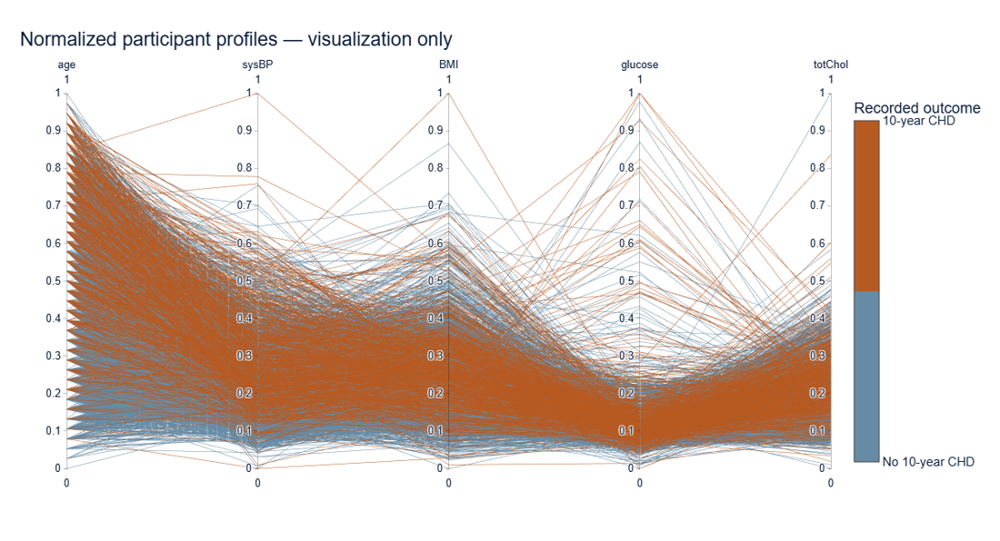

In [32]:

cols=['age','sysBP','BMI','glucose','totChol'];p=df_eda.dropna(subset=cols).copy();scaled=(p[cols]-p[cols].min())/(p[cols].max()-p[cols].min())
scaled['TenYearCHD']=p.TenYearCHD
parallel=px.parallel_coordinates(scaled,dimensions=cols,color='TenYearCHD',range_color=[0,1],
 color_continuous_scale=[[0,OUTCOME_COLORS[OUTCOME_ORDER[0]]],[.499,OUTCOME_COLORS[OUTCOME_ORDER[0]]],[.5,OUTCOME_COLORS[OUTCOME_ORDER[1]]],[1,OUTCOME_COLORS[OUTCOME_ORDER[1]]]])
parallel.update_coloraxes(colorbar={'tickvals':[0,1],'ticktext':OUTCOME_ORDER,'title':'Recorded outcome'})
show(parallel,
 'parallel_coordinates','Normalized participant profiles — visualization only');


### What to look for

Drag a range along an axis to explore linked profiles. All eligible complete profiles are used.

### What this does NOT tell us

The scaled axes lose their original units. Extreme values influence min–max scaling, and line patterns do not quantify independent contributions.

## Class imbalance

The observed CHD outcome is imbalanced, but the correct response depends on the analytical objective.

### For inferential logistic regression
Preserve the natural outcome distribution. Do **not** oversample cases merely to make the classes equal.

### For machine-learning prediction
Use stratified splitting first. If class imbalance harms clinically important detection, compare approaches such as:

- class weighting
- threshold tuning
- carefully designed resampling
- SMOTE or related methods inside training folds only

Never resample the complete dataset before train-test splitting because that can create information leakage.

Also remember that with an imbalanced outcome, accuracy alone is usually not an adequate performance metric.


**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Summarize class imbalance.

**WHY ARE WE DOING IT?** Unequal outcome counts require attention to the analytical goal.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** Counts and percentages for the two recorded outcome classes.

In [33]:
class_summary = pd.DataFrame({
    "class": ["No 10-year CHD", "10-year CHD"],
    "n": [int((df_eda["TenYearCHD"] == 0).sum()),
          int((df_eda["TenYearCHD"] == 1).sum())],
})

class_summary["percent"] = 100 * class_summary["n"] / class_summary["n"].sum()
class_summary


,class,n,percent
0,No 10-year CHD,3596,84.811
1,10-year CHD,644,15.189


## The objective determines imbalance handling

Keep the observed outcome distribution in the inferential model. Prediction requires a separate validated pipeline.

**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Compare inference and prediction workflows.

**WHY ARE WE DOING IT?** Preserving observed outcomes for inference and evaluating training-only interventions for prediction serve different goals.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** Two teaching panels; no balancing or resampling is performed.

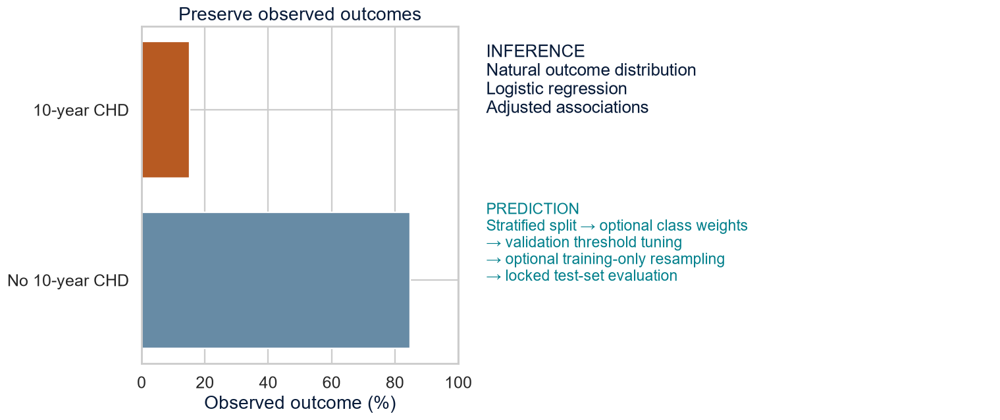

In [34]:

fig,axs=plt.subplots(1,2,figsize=(14,6),gridspec_kw={'width_ratios':[1,1.6]})
axs[0].barh(OUTCOME_ORDER,100*df_eda.TenYearCHD.value_counts(normalize=True).reindex([0,1]),color=list(OUTCOME_COLORS.values()))
axs[0].set(xlim=(0,100),xlabel='Observed outcome (%)',title='Preserve observed outcomes')
axs[1].axis('off');axs[1].text(0,.95,'INFERENCE\nNatural outcome distribution\nLogistic regression\nAdjusted associations',va='top',color=NAVY,fontsize=17)
axs[1].text(0,.48,'PREDICTION\nStratified split → optional class weights\n→ validation threshold tuning\n→ optional training-only resampling\n→ locked test-set evaluation',va='top',color=TEAL,fontsize=15)
finish_static(fig,'07_class_imbalance');


### What to look for

The two paths answer different questions. Every percentage above comes from the observed outcomes.

### What this does NOT tell us

No artificially balanced cohort is created. This figure describes the prediction workflow; it does not execute or validate a predictive model.

## From EDA signals to model specification

Summarize recorded patterns and explicitly identify how the unchanged model represents each construct.

**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Connect descriptive patterns to the inherited model specification.

**WHY ARE WE DOING IT?** Each modeling decision needs a stated reason and limit.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** A calculated summary table and a static decision figure; EDA alone does not validate the model.

,Variable,Recorded descriptive signal,Overlapping information,Model treatment
0,age,Mean: no CHD 48.8; CHD 54.1,sysBP: r=0.394,"Continuous, per 5 years"
1,sysBP,Mean: no CHD 130.3; CHD 143.6,diaBP: r=0.784,"Selected BP representation, per 10 mmHg"
2,cigsPerDay,Mean: no CHD 8.7; CHD 10.6,currentSmoker: r=0.770,"Continuous intensity, per 10/day"
3,glucose,Mean: no CHD 80.7; CHD 89.0,diabetes: r=0.618,Continuous glucose plus diabetes indicator


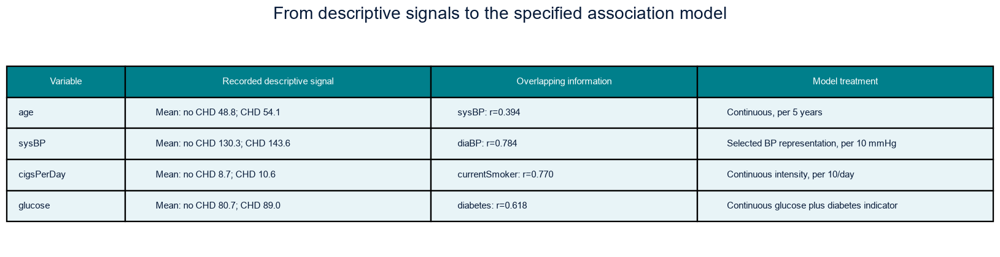

✓ EDA complete


In [35]:

summary_rows=[]
for variable,partner,treatment in [('age','sysBP','Continuous, per 5 years'),('sysBP','diaBP','Selected BP representation, per 10 mmHg'),
 ('cigsPerDay','currentSmoker','Continuous intensity, per 10/day'),('glucose','diabetes','Continuous glucose plus diabetes indicator')]:
 means=df_eda.groupby('TenYearCHD')[variable].mean()
 summary_rows.append({'Variable':variable,'Recorded descriptive signal':f'Mean: no CHD {means.loc[0]:.1f}; CHD {means.loc[1]:.1f}',
 'Overlapping information':f'{partner}: r={df_eda[[variable,partner]].corr().iloc[0,1]:.3f}','Model treatment':treatment})
spec=pd.DataFrame(summary_rows);display(spec)
fig,ax=plt.subplots(figsize=(15,4));ax.axis('off');table=ax.table(cellText=spec.values,colLabels=spec.columns,cellLoc='left',loc='center',colWidths=[.12,.31,.27,.30])
table.auto_set_font_size(False);table.set_fontsize(10);table.scale(1,2.7)
for (r,c),cell in table.get_celld().items():cell.set_facecolor(AQUA if r else TEAL);cell.set_text_props(color=NAVY if r else 'white')
ax.set_title('From descriptive signals to the specified association model',pad=20);finish_static(fig,'10_eda_to_model')
spec.to_csv(VIS/'model_specification.csv',index=False);

print('✓ EDA complete')


### What to look for

Compare group summaries with the exact predictor choices below. This table documents the inherited teaching specification.

### What this does NOT tell us

Descriptive separation and pairwise correlation do not establish significance, optimal variable selection or a causal adjustment set. EDA alone cannot validate the specification.

## STEP 8 — MODEL

**Step 8 of 9 · ⭐ BEGINNER CORE**

Because `TenYearCHD` is binary, we use multivariable **logistic regression**.

The example specification intentionally avoids placing every correlated representation of the same construct into the model.

For example:

- `cigsPerDay` is used instead of simultaneously forcing both `currentSmoker` and `cigsPerDay` into the model.
- `sysBP` is used as the principal continuous BP measure rather than automatically including systolic BP, diastolic BP, and prevalent hypertension together.

This is a modeling decision informed by EDA, not an automatic universal rule.

For interpretability, some continuous variables are rescaled so odds ratios correspond to meaningful increments.


**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Identify complete records for the specified model.

**WHY ARE WE DOING IT?** A record with a missing required input cannot enter this complete-case fit.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** Original N=4,240 and complete-case N=3,658; exclusions reflect missing model inputs and may introduce selection bias.

In [36]:
model_vars = [
    "TenYearCHD", "male", "age", "education", "cigsPerDay",
    "BPMeds", "prevalentStroke", "diabetes",
    "totChol", "sysBP", "BMI", "heartRate", "glucose"
]

model_df = df_eda[model_vars].dropna().copy()

print(f"Original N: {len(df_eda):,}")
print(f"Complete-case model N: {len(model_df):,}")
print(f"Excluded because at least one model variable was missing: {len(df_eda) - len(model_df):,}")
print()
print("For publication-grade inference, assess the missingness mechanism and consider")
print("multiple imputation rather than automatically relying on complete-case analysis.")


Original N: 4,240
Complete-case model N: 3,658
Excluded because at least one model variable was missing: 582

For publication-grade inference, assess the missingness mechanism and consider
multiple imputation rather than automatically relying on complete-case analysis.


The complete-case model excludes participants with any missing model input. Preserving the outcome distribution means avoiding artificial balancing; it does not guarantee that complete-case selection preserves the full cohort prevalence. Compare the model sample with the original cohort.

**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Fit the unchanged logistic regression with interpretable increments.

**WHY ARE WE DOING IT?** Adjusted associations account for the other predictors included in this model.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** A regression summary and success message; the table describes association, not causation.

In [37]:
# Rescale continuous predictors for interpretable odds ratios
model_df["age_5y"] = model_df["age"] / 5
model_df["cigs_10"] = model_df["cigsPerDay"] / 10
model_df["sysBP_10"] = model_df["sysBP"] / 10
model_df["totChol_10"] = model_df["totChol"] / 10
model_df["BMI_5"] = model_df["BMI"] / 5
model_df["glucose_10"] = model_df["glucose"] / 10
model_df["heartRate_10"] = model_df["heartRate"] / 10

formula = '''
TenYearCHD ~ male + age_5y + cigs_10 + sysBP_10 +
             totChol_10 + BMI_5 + glucose_10 +
             BPMeds + prevalentStroke + diabetes +
             heartRate_10 + C(education)
'''

fit = smf.logit(formula, data=model_df).fit(disp=False)
display(fit.summary())

print('✓ Logistic regression fitted successfully')


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             TenYearCHD   No. Observations:                 3658
Model:                          Logit   Df Residuals:                     3643
Method:                           MLE   Df Model:                           14
Date:                Wed, 07 Oct 2026   Pseudo R-squ.:                  0.1172
Time:                        02:54:56   Log-Likelihood:                -1377.7
converged:                       True   LL-Null:                       -1560.6
Covariance Type:            nonrobust   LLR p-value:                 1.996e-69
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -8.7569      0.627    -13.968      0.000      -9.986      -7.528
C(education)[T.2.0]    -0.1908      0.123     -1.548      0.122      -0.432       0.051
C(education)[T.3.0]    -0.2008      0.150     -1.340      0.180      -0.494       0.093
C(education)[T.4.0]    -0.0591      0.164     -0.360      0.719      -0.381       0.263
male                    0.5327      0.109      4.892      0.000       0.319       0.746
age_5y                  0.3167      0.033      9.602      0.000       0.252       0.381
cigs_10                 0.2006      0.042      4.744      0.000       0.118       0.284
sysBP_10                0.1677      0.024      7.134      0.000       0.122       0.214
totChol_10              0.0239      0.011      2.116      0.034       0.002       0.046
BMI_5                   0.0242      0.062      0.390      0.697      -0.098       0.146
glucose_10              0.0717      0.022      3.201      0.001       0.028       0.116
BPMeds                  0.2008      0.235      0.853      0.394      -0.260       0.662
prevalentStroke         0.7224      0.490      1.474      0.140      -0.238       1.683
diabetes                0.0353      0.317      0.111      0.911      -0.586       0.656
heartRate_10           -0.0268      0.042     -0.637      0.524      -0.109       0.056
=======================================================================================
"""

✓ Logistic regression fitted successfully


**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Convert model coefficients into adjusted odds ratios.

**WHY ARE WE DOING IT?** Odds ratios and intervals are easier to interpret with named increments.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** A table with odds ratios, confidence limits and p-values.

In [38]:
# Convert coefficients to adjusted odds ratios
params = fit.params
ci = fit.conf_int()

results = pd.DataFrame({
    "Adjusted_OR": np.exp(params),
    "CI_2.5%": np.exp(ci[0]),
    "CI_97.5%": np.exp(ci[1]),
    "p_value": fit.pvalues
})

results = results.drop(index="Intercept")
results.round(3)


,Adjusted_OR,CI_2.5%,CI_97.5%,p_value
C(education)[T.2.0],0.826,0.649,1.052,0.122
C(education)[T.3.0],0.818,0.610,1.097,0.180
C(education)[T.4.0],0.943,0.683,1.300,0.719
male,1.704,1.376,2.109,0.000
age_5y,1.373,1.287,1.464,0.000
cigs_10,1.222,1.125,1.328,0.000
sysBP_10,1.183,1.129,1.238,0.000
totChol_10,1.024,1.002,1.047,0.034
BMI_5,1.024,0.907,1.157,0.697
glucose_10,1.074,1.028,1.123,0.001


### Interpretation guide

Examples:

- An adjusted odds ratio above 1 means higher odds of 10-year CHD as the predictor increases, holding the other included variables constant.
- An adjusted odds ratio below 1 means lower odds, holding the other included variables constant.
- Confidence intervals communicate uncertainty.
- Statistical association is not equivalent to causal effect.

Scaling matters. For example, `age_5y` corresponds to a **5-year age increase**, while `sysBP_10` corresponds to a **10 mmHg systolic BP increase**.


**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Read selected adjusted associations in words.

**WHY ARE WE DOING IT?** Each estimate needs its increment and comparison group.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** Six printed estimates with their 95% confidence intervals.

In [39]:
# Print selected interpretable results
selected = {
    "male": "Male vs female-coded reference",
    "age_5y": "Per 5-year increase in age",
    "cigs_10": "Per 10 cigarettes/day",
    "sysBP_10": "Per 10 mmHg systolic BP",
    "totChol_10": "Per 10-unit total cholesterol",
    "glucose_10": "Per 10-unit glucose"
}

for term, label in selected.items():
    row = results.loc[term]
    print(
        f"{label}: OR {row['Adjusted_OR']:.2f} "
        f"(95% CI {row['CI_2.5%']:.2f} to {row['CI_97.5%']:.2f})"
    )


Male vs female-coded reference: OR 1.70 (95% CI 1.38 to 2.11)
Per 5-year increase in age: OR 1.37 (95% CI 1.29 to 1.46)
Per 10 cigarettes/day: OR 1.22 (95% CI 1.12 to 1.33)
Per 10 mmHg systolic BP: OR 1.18 (95% CI 1.13 to 1.24)
Per 10-unit total cholesterol: OR 1.02 (95% CI 1.00 to 1.05)
Per 10-unit glucose: OR 1.07 (95% CI 1.03 to 1.12)


## Adjusted associations: read the effect size and uncertainty

The original complete-case logistic regression and predictor increments are preserved.

**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Plot adjusted odds ratios and uncertainty.

**WHY ARE WE DOING IT?** A forest plot makes both direction and precision visible.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** Interactive and static forest plots; the reference line is OR=1, and the axis uses a log scale.

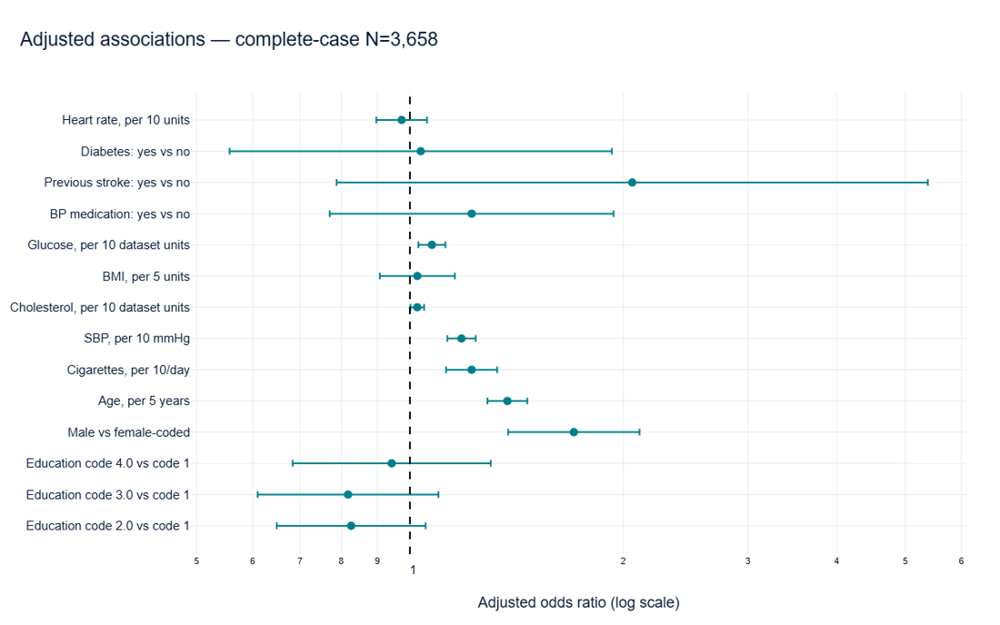

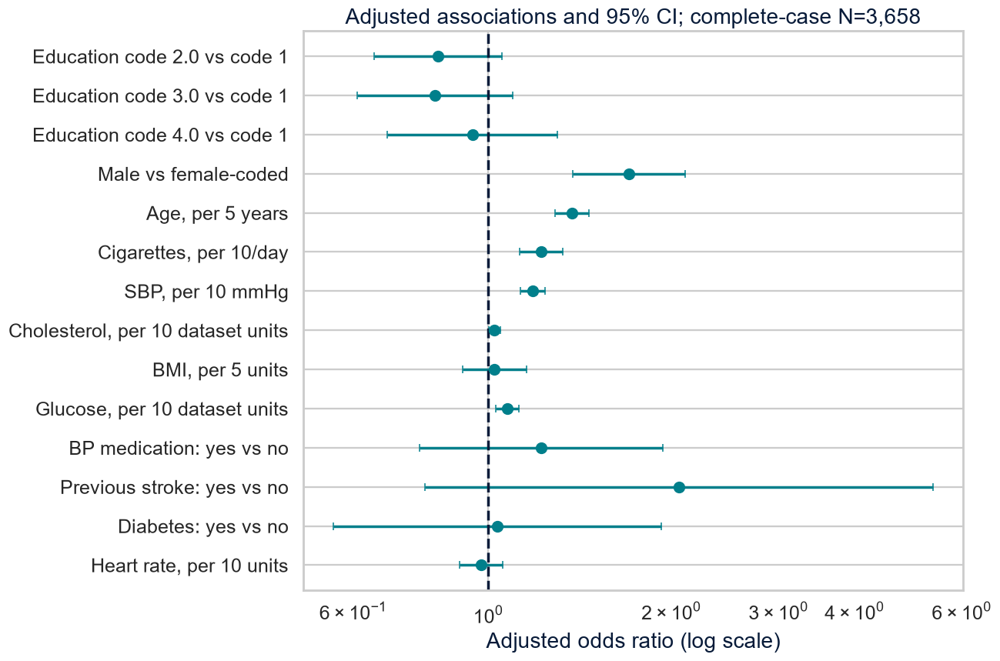

In [40]:

labels={'male':'Male vs female-coded','age_5y':'Age, per 5 years','cigs_10':'Cigarettes, per 10/day','sysBP_10':'SBP, per 10 mmHg',
 'totChol_10':'Cholesterol, per 10 dataset units','BMI_5':'BMI, per 5 units','glucose_10':'Glucose, per 10 dataset units',
 'BPMeds':'BP medication: yes vs no','prevalentStroke':'Previous stroke: yes vs no','diabetes':'Diabetes: yes vs no','heartRate_10':'Heart rate, per 10 units'}
forest=results.copy();forest['label']=[labels.get(i, str(i).replace('C(education)[T.','Education code ').replace(']',' vs code 1')) for i in forest.index]
f=go.Figure(go.Scatter(x=forest.Adjusted_OR,y=forest.label,mode='markers',marker={'size':10,'color':TEAL},
 error_x={'type':'data','array':forest['CI_97.5%']-forest.Adjusted_OR,'arrayminus':forest.Adjusted_OR-forest['CI_2.5%']},
 customdata=forest[['CI_2.5%','CI_97.5%','p_value']].values,hovertemplate='%{y}<br>OR=%{x:.3f}<br>95% CI=%{customdata[0]:.3f}–%{customdata[1]:.3f}<br>p=%{customdata[2]:.4f}<extra></extra>'))
f.update_xaxes(type='log',title='Adjusted odds ratio (log scale)');f.add_vline(x=1,line_dash='dash');f.update_layout(height=750)
show(f,'adjusted_forest',f'Adjusted associations — complete-case N={len(model_df):,}')
fig,ax=plt.subplots(figsize=(12,8));ys=np.arange(len(forest));ax.errorbar(forest.Adjusted_OR,ys,
 xerr=[forest.Adjusted_OR-forest['CI_2.5%'],forest['CI_97.5%']-forest.Adjusted_OR],fmt='o',color=TEAL,capsize=3)
ax.set_yticks(ys,forest.label);ax.set_xscale('log');ax.axvline(1,color=NAVY,ls='--');ax.invert_yaxis()
ax.set(xlabel='Adjusted odds ratio (log scale)',title=f'Adjusted associations and 95% CI; complete-case N={len(model_df):,}')
finish_static(fig,'08_adjusted_OR_forest_plot');


### What to look for

Read each increment, reference group and confidence interval. Odds ratios and risks are different quantities.

### What this does NOT tell us

These conditional associations are not causal effects. Complete-case selection excludes missing model inputs and may introduce selection bias; no automatic deletion or outcome balancing is added.

## Model performance, without confusing prediction with inference

Although this lesson's model is primarily used for adjusted association, we can still inspect how its fitted probabilities behave.

Because the outcome is imbalanced, report several metrics rather than accuracy alone.

These metrics reuse the fitting sample and describe apparent performance. They are not held-out estimates of predictive performance.


**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Summarize apparent model performance.

**WHY ARE WE DOING IT?** Ranking and squared probability error measure different properties.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** ROC-AUC about .739, average precision about .363 and Brier score about .115; these are fitting-sample results.

In [41]:
pred_prob = fit.predict(model_df)

roc_auc = roc_auc_score(model_df["TenYearCHD"], pred_prob)
pr_auc = average_precision_score(model_df["TenYearCHD"], pred_prob)
brier = brier_score_loss(model_df["TenYearCHD"], pred_prob)

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"Average precision: {pr_auc:.3f}")
print(f"Brier score: {brier:.3f}")


ROC-AUC: 0.739
Average precision: 0.363
Brier score: 0.115


**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Group fitted probabilities into deciles.

**WHY ARE WE DOING IT?** Calibration compares predicted probabilities with observed outcome proportions.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** A table of ten groups, their N, mean predicted probability and observed proportion.

In [42]:
# Simple calibration-by-decile table
calibration = pd.DataFrame({
    "observed": model_df["TenYearCHD"].values,
    "predicted": pred_prob.values
})

calibration["risk_decile"] = pd.qcut(
    calibration["predicted"],
    10,
    duplicates="drop"
)

cal_table = (
    calibration.groupby("risk_decile", observed=True)
    .agg(
        n=("observed", "size"),
        mean_predicted=("predicted", "mean"),
        observed_rate=("observed", "mean")
    )
    .reset_index(drop=True)
)

cal_table


,n,mean_predicted,observed_rate
0,366,0.030,0.025
1,366,0.047,0.060
2,366,0.065,0.063
3,365,0.084,0.066
4,366,0.106,0.117
5,366,0.132,0.115
6,365,0.163,0.167
7,366,0.203,0.227
8,366,0.269,0.295
9,366,0.424,0.388


## Model diagnostics: apparent calibration and discrimination

Every metric uses the fitting sample. Keep apparent performance separate from held-out predictive validation.

**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Visualize apparent calibration and discrimination.

**WHY ARE WE DOING IT?** No single performance metric tells the whole story.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** Calibration, ROC and precision–recall figures; trapezoidal PR-AUC is labeled separately from average precision, and all results are apparent.

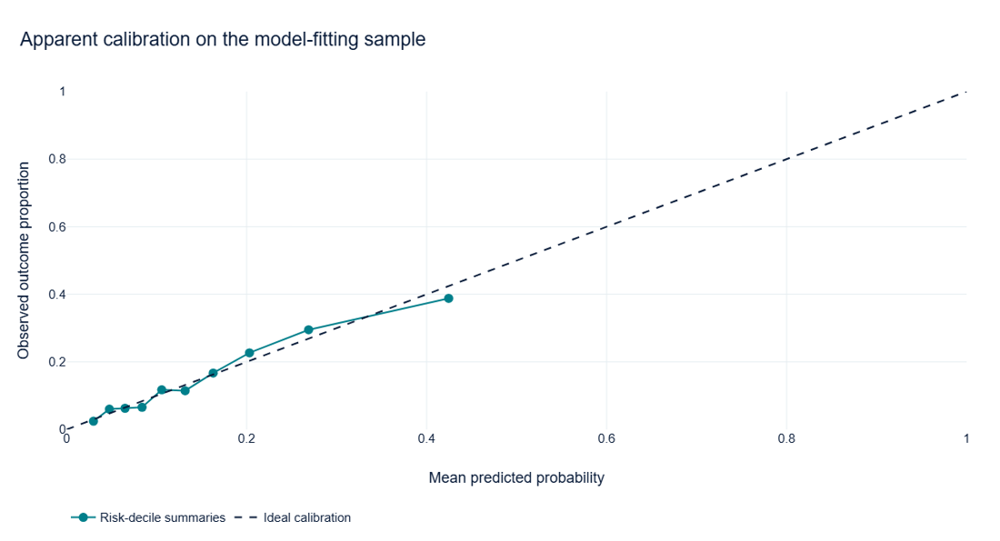

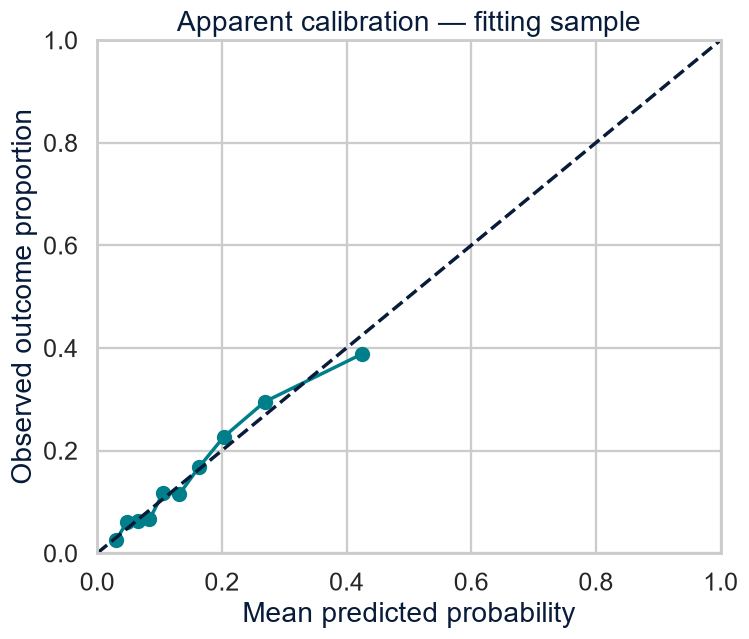

,Value
Apparent ROC-AUC,0.739
Apparent PR-AUC (trapezoidal),0.362
Apparent average precision,0.363
Apparent Brier score,0.115
Model-sample outcome prevalence,0.152


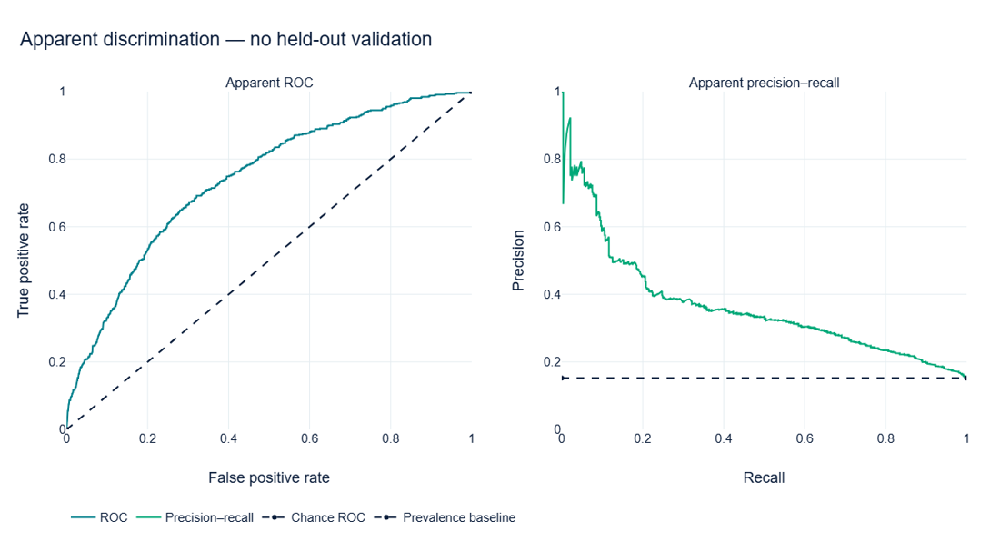

In [43]:

f=go.Figure(go.Scatter(x=cal_table.mean_predicted,y=cal_table.observed_rate,mode='lines+markers',name='Risk-decile summaries',marker={'color':TEAL,'size':11},
 customdata=cal_table[['n']].values,hovertemplate='Mean predicted=%{x:.3f}<br>Observed=%{y:.3f}<br>Decile N=%{customdata[0]}<extra></extra>'))
f.add_trace(go.Scatter(x=[0,1],y=[0,1],mode='lines',line={'dash':'dash','color':NAVY},name='Ideal calibration'))
f.update_xaxes(range=[0,1],title='Mean predicted probability');f.update_yaxes(range=[0,1],title='Observed outcome proportion')
show(f,'apparent_calibration','Apparent calibration on the model-fitting sample')
fig,ax=plt.subplots(figsize=(7,6));ax.plot(cal_table.mean_predicted,cal_table.observed_rate,'o-',color=TEAL)
ax.plot([0,1],[0,1],'--',color=NAVY);ax.set(xlim=(0,1),ylim=(0,1),xlabel='Mean predicted probability',ylabel='Observed outcome proportion',title='Apparent calibration — fitting sample');finish_static(fig,'09_calibration')
fpr,tpr,_=roc_curve(model_df.TenYearCHD,pred_prob);precision,recall,_=precision_recall_curve(model_df.TenYearCHD,pred_prob)
pr_trapezoid=auc(recall,precision)
display(pd.Series({'Apparent ROC-AUC':roc_auc,'Apparent PR-AUC (trapezoidal)':pr_trapezoid,
 'Apparent average precision':pr_auc,'Apparent Brier score':brier,'Model-sample outcome prevalence':model_df.TenYearCHD.mean()}).to_frame('Value'))
panel=make_subplots(rows=1,cols=2,subplot_titles=['Apparent ROC','Apparent precision–recall'])
panel.add_trace(go.Scatter(x=fpr,y=tpr,line={'color':TEAL},name='ROC'),row=1,col=1)
panel.add_trace(go.Scatter(x=recall,y=precision,line={'color':GREEN},name='Precision–recall'),row=1,col=2)
panel.add_trace(go.Scatter(x=[0,1],y=[0,1],line={'dash':'dash','color':NAVY},name='Chance ROC'),row=1,col=1)
panel.add_trace(go.Scatter(x=[0,1],y=[model_df.TenYearCHD.mean()]*2,line={'dash':'dash','color':NAVY},name='Prevalence baseline'),row=1,col=2)
panel.update_xaxes(range=[0,1]);panel.update_yaxes(range=[0,1])
panel.update_xaxes(title='False positive rate',row=1,col=1);panel.update_yaxes(title='True positive rate',row=1,col=1)
panel.update_xaxes(title='Recall',row=1,col=2);panel.update_yaxes(title='Precision',row=1,col=2)
show(panel,'performance_panel','Apparent discrimination — no held-out validation')
metrics={'roc_auc':roc_auc,'pr_auc_trapezoidal':pr_trapezoid,'average_precision':pr_auc,'brier':brier,'model_n':len(model_df)}
(VIS/'apparent_metrics.json').write_text(json.dumps(metrics,indent=2));


### What to look for

Compare risk-decile points with the ideal line and inspect group sizes. PR-AUC and average precision use different integration conventions and are labeled separately.

### What this does NOT tell us

This plot describes apparent calibration and is not an external validation estimate. These metrics are optimistic because the same participants fitted and evaluated the model.

## Optional predictive extension

If the objective changes from **inference** to **machine-learning prediction**, class imbalance should be addressed inside a proper validation workflow.

Recommended sequence:

**Stratified split → preprocessing within training data → class weighting or resampling if needed → threshold selection → locked test evaluation**

Compare:

- ROC-AUC
- PR-AUC
- sensitivity
- specificity
- positive and negative predictive values
- calibration
- Brier score
- clinical utility at relevant thresholds

Do not choose a balancing technique simply because the classes are unequal.


## STEP 9 — EXPLAIN

**Step 9 of 9 · ⭐ BEGINNER CORE**

A good EDA should change how you think about the model.

In this dataset, EDA can reveal:

- the outcome is imbalanced;
- missingness is concentrated in particular variables, especially glucose;
- extreme clinical values require investigation, not automatic deletion;
- several predictors contain overlapping information;
- crude relationships can change after multivariable adjustment;
- meaningful scaling makes regression results easier to interpret;
- the modeling strategy should follow the scientific objective.

### Final takeaway

> **EDA is where data stops being a spreadsheet and starts becoming evidence.**

Sometimes the observation you are tempted to delete is the beginning of the research question that matters most.


## Reproducibility checklist

Before sharing or publishing an analysis:

- document the dataset version and provenance;
- preserve the raw file unchanged;
- record all preprocessing decisions;
- justify missing-data treatment;
- distinguish flagged outliers from confirmed errors;
- document engineered variables;
- report both crude and adjusted findings where relevant;
- avoid data leakage;
- report uncertainty;
- distinguish association, prediction, and causation;
- preserve code and software versions.

**EvidenceLab | Dr. Amobi Andrew Onovo**


## Experiment: change the prediction threshold
Keep the fitted model and fitting sample fixed. Change only the decision threshold. Observe how sensitivity, specificity and positive predictive value move. This is a teaching sensitivity analysis, not a validated threshold recommendation. Prediction work must select thresholds inside training/validation data and evaluate once on a locked test set.


**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Change only the decision threshold in a teaching experiment.

**WHY ARE WE DOING IT?** Thresholds trade off sensitivity, specificity and precision.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** A table and lines showing those trade-offs on the fitting sample; this is not a validated threshold recommendation.

 threshold  sensitivity  specificity   PPV
     0.100        0.842        0.472 0.223
     0.150        0.697        0.666 0.272
     0.200        0.537        0.797 0.323
     0.300        0.287        0.918 0.386
     0.500        0.086        0.992 0.667


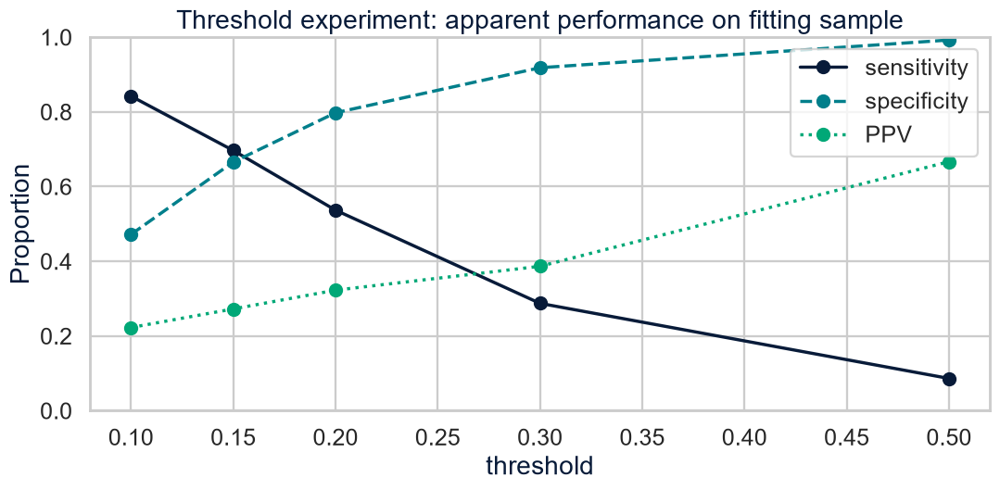

In [44]:
threshold_rows = []
for threshold in [0.10, 0.15, 0.20, 0.30, 0.50]:
    tn, fp, fn, tp = confusion_matrix(model_df['TenYearCHD'], pred_prob >= threshold).ravel()
    threshold_rows.append({'threshold':threshold, 'sensitivity':tp/(tp+fn), 'specificity':tn/(tn+fp), 'PPV':tp/(tp+fp) if tp+fp else np.nan})
threshold_table = pd.DataFrame(threshold_rows)
print(threshold_table.to_string(index=False))
threshold_table.plot(x='threshold', y=['sensitivity','specificity','PPV'], marker='o', color=[NAVY, TEAL, GREEN], style=['-','--',':'], ylim=(0,1), figsize=(10,5))
plt.ylabel('Proportion'); plt.title('Threshold experiment: apparent performance on fitting sample')
plt.tight_layout(); plt.savefig(OUT/'threshold_experiment.png'); plt.show()


Lower thresholds flag more people and usually increase sensitivity while reducing specificity. The trade-off depends on the decision and the population. EDA helps expose it; external validation must test it.

## Export the evidence
The tables below preserve the audit and model results used in the lesson. Pair each adjusted odds ratio with its confidence interval, variable increment and complete-case population.


**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Save the evidence tables and numerical claim ledger.

**WHY ARE WE DOING IT?** Exports let another reader inspect the exact evidence.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** A printed numerical ledger and a success message; files are saved in the outputs folder.

In [45]:
audit.to_csv(OUT/'audit.csv')
outcome_summary.to_csv(OUT/'outcome_summary.csv')
outlier_summary.to_csv(OUT/'outlier_summary.csv', index=False)
corr.to_csv(OUT/'correlations.csv')
results.to_csv(OUT/'adjusted_odds_ratios.csv')
cal_table.to_csv(OUT/'apparent_calibration.csv', index=False)
threshold_table.to_csv(OUT/'threshold_experiment.csv', index=False)
claims = {'rows':len(df), 'variables':df.shape[1], 'CHD_n':int(df.TenYearCHD.sum()), 'CHD_pct':float(100*df.TenYearCHD.mean()), 'glucose_missing_n':int(df.glucose.isna().sum()), 'glucose_missing_pct':float(100*df.glucose.isna().mean()), 'model_n':len(model_df), 'model_CHD_pct':float(100*model_df.TenYearCHD.mean()), 'dataset_sha256':DATA_SHA}
(OUT/'numerical_claims.json').write_text(json.dumps(claims, indent=2))
print(json.dumps(claims, indent=2))

print('✓ Results exported successfully')


{
  "rows": 4240,
  "variables": 16,
  "CHD_n": 644,
  "CHD_pct": 15.188679245283017,
  "glucose_missing_n": 388,
  "glucose_missing_pct": 9.150943396226415,
  "model_n": 3658,
  "model_CHD_pct": 15.226899945325314,
  "dataset_sha256": "412c9ea5f0dfb7ad243dfcd1f2b4df500101904a8f443a22f3080394391853e9"
}
✓ Results exported successfully


## What EDA revealed before the model

Review evidence from the data before deciding how to interpret the fitted model.

**⭐ BEGINNER CORE**

**WHAT ARE WE DOING?** Review what the EDA revealed before fitting.

**WHY ARE WE DOING IT?** The final explanation connects patterns to questions and assumptions.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** A summary table and the closing EDA message.

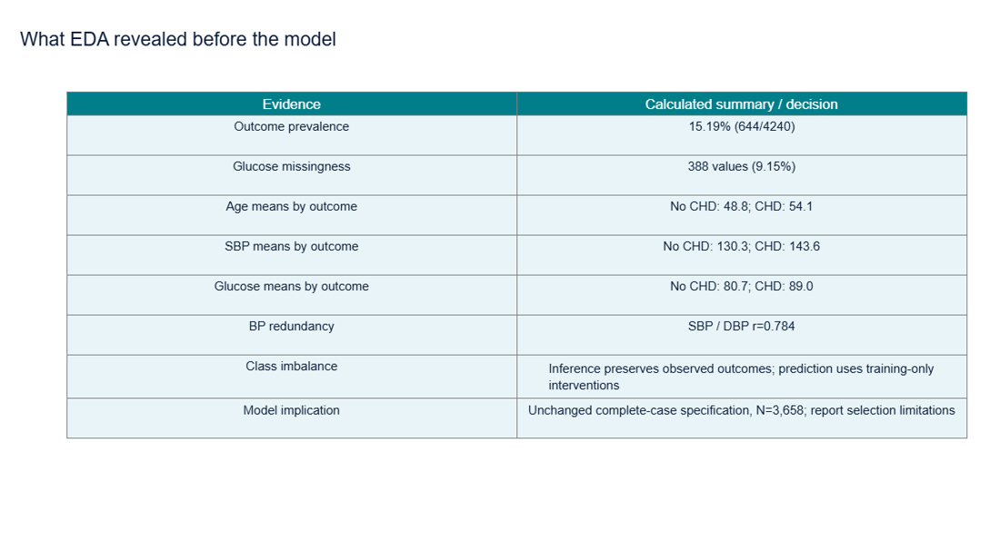

Now we are ready to model — with explicit assumptions and validation needs.
CLEANING ≠ EDA. EDA is where data stops being a spreadsheet and starts becoming evidence.


In [46]:

summary=[['Outcome prevalence',f'{100*df.TenYearCHD.mean():.2f}% ({int(df.TenYearCHD.sum())}/{len(df)})'],
 ['Glucose missingness',f'{df.glucose.isna().sum()} values ({100*df.glucose.isna().mean():.2f}%)'],
 ['Age means by outcome',f'No CHD: {df.loc[df.TenYearCHD==0,"age"].mean():.1f}; CHD: {df.loc[df.TenYearCHD==1,"age"].mean():.1f}'],
 ['SBP means by outcome',f'No CHD: {df.loc[df.TenYearCHD==0,"sysBP"].mean():.1f}; CHD: {df.loc[df.TenYearCHD==1,"sysBP"].mean():.1f}'],
 ['Glucose means by outcome',f'No CHD: {df.loc[df.TenYearCHD==0,"glucose"].mean():.1f}; CHD: {df.loc[df.TenYearCHD==1,"glucose"].mean():.1f}'],
 ['BP redundancy',f'SBP / DBP r={corr.loc["sysBP","diaBP"]:.3f}'],
 ['Class imbalance','Inference preserves observed outcomes; prediction uses training-only interventions'],
 ['Model implication',f'Unchanged complete-case specification, N={len(model_df):,}; report selection limitations']]
f=go.Figure(go.Table(header={'values':['Evidence','Calculated summary / decision'],'fill_color':TEAL,'font':{'color':'white','size':17}},
 cells={'values':list(zip(*summary)),'fill_color':AQUA,'font':{'size':15},'height':48}))
show(f,'final_eda_summary','What EDA revealed before the model')
print('Now we are ready to model — with explicit assumptions and validation needs.')
print('CLEANING ≠ EDA. EDA is where data stops being a spreadsheet and starts becoming evidence.');


### What to look for

Connect each displayed pattern to a question, a denominator and a model implication.

### What this does NOT tell us

A polished visualization does not replace study design, missing-data assessment, causal reasoning or predictive validation.

## Selected exports and optional Plotly PNG/SVG export
Ten signature statistical figures have already been saved as high-resolution PNG and SVG using Seaborn/Matplotlib. Interactive HTML and numerical tables are in `evidencelab06_visuals/` (or `/content/evidencelab06_visuals/` in Colab). HTML uses the Plotly CDN. For offline sharing, call `write_html(..., include_plotlyjs=True)`.

The optional cell below exports selected Plotly views when Kaleido has access to Chrome. Enable it only when those additional images are needed; missing Chrome does not block the analysis.


**🔬 OPTIONAL ADVANCED EDA**

**WHAT ARE WE DOING?** Optionally save extra static copies of Plotly figures.

**WHY ARE WE DOING IT?** You may want images for slides, but this is not needed to complete the lesson.

**WHAT SHOULD YOU CLICK?** Click ▶ beside the code cell immediately below; if you chose Run all, wait for it to finish.

**WHAT SHOULD YOU EXPECT TO SEE?** With the default False setting, only the output-directory message appears; standard static figures already exist.

In [47]:
EXPORT_PLOTLY_IMAGES = False
signature_keys=['missingness','age_density','violin_sysBP','age_sbp_outcome','age_sbp_surface',
                'correlation_interactive','class_distribution','adjusted_forest','apparent_calibration','final_eda_summary']
plotly_export_ready = False
if EXPORT_PLOTLY_IMAGES:
 try:
  import importlib.util, subprocess, sys
  if importlib.util.find_spec('kaleido') is None:
   subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', 'kaleido'])
  import kaleido
  plotly_export_ready = True
 except Exception:
  print('Optional Plotly image export is unavailable. Continue with the interactive figures and the standard static exports; the analysis is complete.')
if plotly_export_ready:
 for key in signature_keys:
  try:
   FIGURES[key].write_image(VIS/f'{key}_plotly.png',width=1600,height=950,scale=2)
   FIGURES[key].write_image(VIS/f'{key}_plotly.svg',width=1600,height=950)
  except Exception as exc:
   print(f'Optional Plotly image export could not finish ({key}); Kaleido may need Chrome. Continue: interactive figures, the analysis and standard static exports are unaffected.')
   break
print('Visual output directory:',VIS)


Visual output directory: evidencelab06_visuals


## Investigate before you delete
1. Start with a scientific question and identify variable types.
2. Audit missingness and unusual values; investigate their context.
3. Engineer features that clarify meaning while preserving original values.
4. Use distributions and relationships to guide model specification.
5. Let inference or prediction determine validation and imbalance handling.

**Try it:** Explain what a complete-case analysis assumes. Compare two correlated predictors before putting them in one model. Change a threshold and describe who is missed or flagged.

The personal story supplied by Dr. Onovo begins with a 2010 ANC/PMTCT review; the linked publication reports a separate 2013 evaluation and was published in 2015. These dates refer to different stages of the research journey. The author's reported 40-citation milestone is not a bibliometric count verified here.

[Onovo and colleagues, BMC Public Health (2015), PMID 26310673](https://pubmed.ncbi.nlm.nih.gov/26310673/)

**What unexpected pattern made you question your analysis?**

EvidenceLab | Dr. Amobi Andrew Onovo | See it. Understand it. Run it.


## Practice with the evidence
1. Use the distribution dropdown to compare glucose and age. Explain why skew and missingness require different questions.
2. Hover over two populated age × SBP cells. Compare their denominators before comparing their prevalence.
3. Change an age-bin boundary and explain which descriptive conclusions are sensitive to that choice.
4. Compare the glucose–diabetes and SBP–DBP correlations with the specified model. Explain why correlation alone does not choose the adjustment set.
5. Call `explore_variable("pulse_pressure")`, then describe a flagged value that should be investigated rather than deleted.

**Decision aid:** Verify a pattern → inspect denominators and missingness → compare distribution and redundancy → state the analytical objective → justify specification → report uncertainty → validate the appropriate claim.
